## TPS – Análisis de patrones ictales de crisis FIAS/IAS temporales en EEG de cuero cabelludo

**Grupo 3:** Juana Rives, Valentina Haag, Jana Yoo

Este notebook analiza registros EEG de superficie correspondientes a crisis epilépticas FIAS/IAS, obtenidos de la base de datos Siena Scalp EEG Database:
https://physionet.org/content/siena-scalp-eeg/1.0.0/#files-panel

Se propone un pipeline de procesamiento compuesto por etapas de adquisición, preprocesamiento, filtrado y extracción de características en los dominios temporal, frecuencial y tiempo-frecuencia. El propósito es identificar patrones descritos en la literatura científica asociados a este tipo de crisis, particularmente la ritmicidad de las ondas Delta (1-4 Hz) y Theta / Alpha (5-9 Hz), y evaluar su presencia en los registros analizados.

**Nota:** La base de datos contiene registros de 14 pacientes, dentro de los cuales 12 son de crisis FIAS. No obstante, uno de los pacientes (PN07) presentó una cantidad excesiva de artefactos en su señal por lo que se lo descartó del estudio. 
Asimismo, varios pacientes cuentan con múltiples registros debido a que experimentaron más de una crisis durante el período de monitoreo. Con el fin de evitar la sobrerrepresentación de determinados sujetos y reducir posibles sesgos en los resultados, se seleccionó un único registro por paciente para el análisis. En la mayoría de los casos, se utilizó el registro correspondiente a la primera crisis detectada. No obstante, en algunos pacientes fue necesario seleccionar la segunda crisis debido al gran tamaño de los archivos asociados al primer evento, lo que dificultaba su almacenamiento en la computadora.

**Índice**
<small>
1. Instalación de librerías necesarias 
2. Configuración general: rutas, canales, filtros, ventanas, bandas y colores  
3. Armado de dataframes: CSV clínico, EDF y TXT  
4. Extracción automática de tiempos de crisis desde TXT  
5. Carga de EDF y preprocesamiento adaptativo  
6. Recorte preictal / ictal / postictal y selección T3/T4 por lateralidad  
7. Control de artefactos, PSD de Welch, potencia relativa  
8. Visualizaciones de PSD y potencia relativa  
9. Ejecución del pipeline en el batch  
10. Espectrogramas ictales individuales   
11. Resumen grupal del patrón ictal a partir de PSD relativa 
12. Análisis temporal de amplitud  
13. Lateralidad espectral con potencia relativa
14. Visualización de señales con MNE para detectar a ojo ritmicidad


## 1. Instalación de librerías

En las siguientes celdas se instalan las librerías necesarias para el trabajo.


In [1]:
%pip install mne scipy pandas matplotlib
%pip install PyQt5
%matplotlib inline 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import re
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy.signal
import mne

# Evita que Matplotlib/MNE abran ventanas externas al correr el batch.
matplotlib.rcParams["figure.max_open_warning"] = 0
plt.ioff()
mne.set_log_level("WARNING")

## 2. Configuración general

En esta sección se concentran todos los parámetros globales.


### 2.1 Rutas de entrada y carpetas de resultados


In [3]:
# ------------------------------------------------------------
# Rutas
# ------------------------------------------------------------

CARPETA_BASE_TPS = Path(r"C:\Users\yoopy\OneDrive\Escritorio\TPS")

# Carpetas ya generadas y nombradas por nosotras en nuestras computadoras. 
CARPETA_EEG = CARPETA_BASE_TPS / "EEG"
CARPETA_REGISTROS = CARPETA_BASE_TPS / "registros"
RUTA_CSV_PACIENTES = CARPETA_BASE_TPS / "subject_info.csv"

# Carpetas que vamos a generar para guardar los resultados del batch.
CARPETA_RESULTADOS_BATCH = CARPETA_BASE_TPS / "resultados_batch"
CARPETA_IMAGENES_BATCH = CARPETA_RESULTADOS_BATCH / "imagenes"

# Carpetas separadas para que los PNG queden ordenados por bloque de análisis.
CARPETA_IMAGENES_PSD = CARPETA_IMAGENES_BATCH / "01_PSD_normal_log_rel"
CARPETA_IMAGENES_AMPLITUD = CARPETA_IMAGENES_BATCH / "02_amplitud"
CARPETA_IMAGENES_LATERALIDAD = CARPETA_IMAGENES_BATCH / "03_lateralidad"

for carpeta in [
    CARPETA_RESULTADOS_BATCH,
    CARPETA_IMAGENES_BATCH,
    CARPETA_IMAGENES_PSD,
    CARPETA_IMAGENES_AMPLITUD,
    CARPETA_IMAGENES_LATERALIDAD,
]:
    carpeta.mkdir(parents=True, exist_ok=True)


### 2.2 Estandarización de canales EEG y selección temporal por lateralidad

<small> La base de datos incluye un archivo CSV que especifica la lateralidad de la crisis correspondiente a cada paciente. Con el objetivo de simplificar el análisis y mantener un criterio uniforme entre los registros, se seleccionó un único canal representativo en función del hemisferio afectado: el canal T3 para las crisis lateralizadas en el hemisferio izquierdo y el canal T4 para aquellas lateralizadas en el hemisferio derecho.

Cabe destacar que, a partir del análisis exploratorio realizado sobre los registros, se observó que todos los pacientes disponían de canales adicionales además de los 29 canales de EEG especificados en sus archivos TXT . Asimismo, se detectaron inconsistencias en la nomenclatura utilizada para identificar los canales, encontrándose diferentes variantes para un mismo electrodo (por ejemplo, *FP1*, *Fp1* y *fp1*). Por este motivo, fue necesario realizar un proceso de estandarización de nombres, con el fin de garantizar la consistencia de los datos y facilitar las etapas posteriores de procesamiento y análisis.

In [4]:
# ---------------------------------------------------------------------------------------
# Estandarizamos canales de acuerdo a los que aparecen en los txt de todos los pacientes.
# ---------------------------------------------------------------------------------------

# Defino los canales que aparecen en los txt de todos los pacientes. 
CANALES_EEG_SIENA_29 = [
    "Fp1", "F3", "C3", "P3", "O1", "F7", "T3", "T5",
    "Fc1", "Fc5", "Cp1", "Cp5", "F9", "Fz", "Cz", "Pz",
    "Fp2", "F4", "C4", "P4", "O2", "F8", "T4", "T6",
    "Fc2", "Fc6", "Cp2", "Cp6", "F10",
]

CANALES_TEMPORALES_POR_LATERALIDAD = {
    "L": "T3",
    "R": "T4",
}


### 2.4 Parámetros de filtrado, Welch y ventanas temporales

<small> Para el filtrado se aplicó: 
1) Filtro notch adaptativo en 50 Hz y/o 100 Hz según corresponda. Esto se hizo mediante el método `spectrum_fit` para atenuar la interferencia de línea de 50 Hz, utilizando una estrategia menos invasiva que un filtro notch fijo, ya que estima y remueve principalmente componentes sinusoidales compatibles con ruido de red.
2) Pasa-bandas entre 0.5 y 45 Hz para eliminar interferencias de baja frecuencia y ruido muscular (EMG) en las altas frecuencias. Esto no entorpece el estudio de las crisis epilépticas ya que las principales frecuencias de interés a analizar son de 1-4 Hz (delta) y 5-9 Hz (theta/alpha).

Ventanas temporales de análisis: 
1) Ventana ictal inicial de 0-10s
2) Ventana ictal entre 10-30s luego de iniciada la crisis.

Welch: 
1) Se definieron ventanas de 2 s y un solapamiento del 50% --> Se consideró que era una buena elección para ventanas de 10 / 20 s de duración.


In [5]:
# ------------------------------------------------------------
# Filtro principal
# ------------------------------------------------------------

# Filtro pasa bandas
FILTRO_L_FREQ = 0.5
FILTRO_H_FREQ = 45.0

# Método para aplicar notch cuando la detección adaptativa encuentra interferencia en 50 y 100 Hz.
METODO_NOTCH = "spectrum_fit"

# ------------------------------------------------------------
# Detección adaptativa de interferencia de línea
# Se evalúa sobre algunos canales, porque la interferencia de línea suele ser global.
# Se evalúa en canales frontales, temporales, centrales y parietales para cubrir distintas regiones del cuero cabelludo.
# ------------------------------------------------------------
FRECUENCIAS_LINEA_A_EVALUAR = (50.0, 100.0)
CANALES_PARA_DETECTAR_LINEA = ("T3", "T4", "Cz", "Fz", "Pz")
DURACION_DETECCION_LINEA_SEG = 60.0 # Se evalúa en segmentos de 60 s para tener suficiente resolución temporal sin ser tan cortos que no se detecte la interferencia.
UMBRAL_RATIO_LINEA = 6.0 # Si la potencia en la frecuencia de línea es 6 veces mayor que el promedio de las potencias en las frecuencias vecinas, se considera que hay interferencia de línea.
ANCHO_LINEA_HZ = 0.75 # Para determinar el ancho de la interferencia de línea, se evalúa un rango de frecuencias alrededor de la frecuencia de línea (50 o 100 Hz) y se determina el ancho como el rango de frecuencias donde la potencia es mayor que el umbral. 
ANCHO_VECINDAD_LINEA_HZ = 5.0 # Para calcular el promedio de las potencias en las frecuencias vecinas, se evalúa un rango de frecuencias alrededor de la frecuencia de línea (50 o 100 Hz) y se promedian las potencias en ese rango. 
EXCLUSION_CENTRAL_LINEA_HZ = 1.5 # Para excluir la frecuencia central de la interferencia de línea, se evalúa un rango de frecuencias alrededor de la frecuencia de línea (50 o 100 Hz) y se excluye el rango central. 

# ------------------------------------------------------------
# PSD / Welch
# ------------------------------------------------------------
SEGUNDOS_POR_VENTANA_WELCH = 2
SOLAPAMIENTO_WELCH = 0.5

RANGO_TOTAL_POT_REL = (0.5, 45.0)

# Ventanas temporales para comparar potencia relativa.
VENTANA_INICIO_ICTAL = (0.0, 10.0)
VENTANA_EVOLUCION_ICTAL = (10.0, 30.0)

# ------------------------------------------------------------
# Procesamiento por ventana extendida alrededor de cada crisis
# ------------------------------------------------------------
# Se usa para no filtrar EDF completos de muchas horas porque sino no corre el código :(
# El análisis conserva 60 s preictales + crisis + 60 s postictales.
# Para reducir efectos de borde del filtrado, se agrega un margen extra
# que se usa solo para filtrar y luego queda fuera de las métricas.
PREICTAL_ANALISIS_SEC = 60.0
POSTICTAL_ANALISIS_SEC = 60.0
MARGEN_FILTRO_BORDE_SEC = 10.0

MARGEN_PREPROCESAMIENTO_PRE = PREICTAL_ANALISIS_SEC + MARGEN_FILTRO_BORDE_SEC
MARGEN_PREPROCESAMIENTO_POST = POSTICTAL_ANALISIS_SEC + MARGEN_FILTRO_BORDE_SEC


### 2.5 Control de calidad, bandas cerebrales y paleta de colores

<small> Se aplicaron controles de calidad automáticos para identificar segmentos o canales problemáticos antes de comenzar con el procesamiento. Se buscaron canales prácticamente planos, definidos por amplitudes muy bajas (< 1 µV), segmentos con saltos bruscos de línea de base (> 75 µV), amplitudes pico a pico extremas (> 250 µV), exceso de contenido de alta frecuencia compatible con ruido muscular o artefactos (ratio > 0.35) y posible saturación/clipping de la señal cuando una proporción elevada de muestras aparecía recortada (> 15%). Esto solo se hizo con la finalidad de comprender por qué algunos resultados podrían llegar a dar "mal", ya que los artefactos no pueden ser recortados al intentar hacer un ánalisis muy centrado en temporalidad (de 0-10 s y de 10-30 s) y el filtro pasa-bandas es aplicado en todas las señales para eliminar la mayor parte de EMG y ruido de baja frecuencia posible.

Las bandas cerebrales de la PSD normal y en escala logarítmica se definieron con el rango de frecuencias visto en clase. En cambio, la PSD relativa se analizó particularmente con Delta 1-4 Hz y Theta / Alpha 5-9 Hz, como se indica en la literatura encontrada sobre crisis FIAS. 

In [6]:
# ------------------------------------------------------------
# Control de calidad / ventanas sospechosas por artefactos
# ------------------------------------------------------------
# No corrige ni concatena señal. Solo indica ventanas sospechosas para revisar
# e interpretar con cuidado métricas de PSD, amplitud y lateralidad.
VENTANA_ARTEFACTOS_SEC = 2.0
PASO_ARTEFACTOS_SEC = 2.0

# Hacemos este análisis en los canales que vamos a usar para sacar conslusiones.
CANALES_CONTROL_ARTEFACTOS = ("F7", "T3", "T5", "F8", "T4", "T6")

UMBRAL_CANAL_PLANO_UV = 1.0
UMBRAL_SALTO_BASELINE_UV = 75.0
UMBRAL_PTP_EXTREMO_UV = 250.0
UMBRAL_RATIO_ALTA_FRECUENCIA = 0.35
UMBRAL_CLIPPING_PROP = 0.15

# Rangos de visualización de los gráficos.
PSD_XLIM_COMPLETA = (0.5, FILTRO_H_FREQ)
PSD_XLIM_COMPARATIVA = (0.5, 45.0)

# Ritmos cerebrales definidos según la tabla vista en clase.
# Delta convencional se mantiene en 0.5-4 Hz para la PSD normal/log!!
# Gamma se deja acotada a FILTRO_H_FREQ porque el pasabanda final llega a 45 Hz.
RITMOS_CEREBRALES = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, FILTRO_H_FREQ),
}

# Banda delta dirigida al patrón ictal inicial reportado en bibliografía sobre crisis FIAS.
# NOTA: Se usa SOLO para potencia relativa focalizada/lateralidad.
BANDA_DELTA_RITMICA = (1.0, 4.0)
ETIQUETA_DELTA_RITMICA = "Delta 1-4 Hz"

COLORES_RITMOS = {
    "delta": "#75A0FC",  
    "theta": "#C6EF7B",
    "alpha": "#83E2F1",  
    "beta":  "#F9BAE7",  
    "gamma": "#C2A0F5",  
}

# ------------------------------------------------------------
# Banda dirigida al patrón ictal theta/alpha reportado en bibliografía.
# Se usa SOLO para gráficos de potencia relativa y para lateralidad.
# No modifica las bandas fisiológicas convencionales usadas en la PSD normal/log.
# ------------------------------------------------------------
NOMBRE_THETA_ALPHA_RITMICA = "theta_alpha_5_9"
BANDA_THETA_ALPHA_RITMICA = (5.0, 9.0)
ETIQUETA_THETA_ALPHA_RITMICA = "Theta/alpha 5-9 Hz"
COLOR_THETA_ALPHA_RITMICA = "#C6EF7B"  

# Bandas usadas para gráficos de PSD relativa focalizados.
RITMOS_POT_REL_GRAFICOS = {
    "delta": BANDA_DELTA_RITMICA,
    NOMBRE_THETA_ALPHA_RITMICA: BANDA_THETA_ALPHA_RITMICA,
}

COLORES_POT_REL_GRAFICOS = {
    "delta": COLORES_RITMOS["delta"],
    NOMBRE_THETA_ALPHA_RITMICA: COLOR_THETA_ALPHA_RITMICA,
}

# Para mantener compatibilidad con nombres anteriores del notebook...
BANDAS_EEG = RITMOS_CEREBRALES
COLORES_BANDAS = COLORES_RITMOS


### 2.6 Funciones auxiliares para nombres de archivo y guardado de figuras


In [7]:
# ============================================================
# FUNCIONES AUXILIARES PARA GUARDAR RESULTADOS DEL BATCH
# ============================================================

def limpiar_nombre_archivo(texto) -> str:
    """
    Limpia texto para usarlo como nombre de archivo.
    Evita espacios, barras y caracteres problemáticos en Windows.
    """
    texto = str(texto)
    texto = re.sub(r"[^\w\-\.]+", "_", texto, flags=re.UNICODE)
    texto = re.sub(r"_+", "_", texto).strip("_")
    return texto


def guardar_figura(fig, ruta_salida: str | Path, dpi: int = 160) -> Path:
    """
    Guarda una figura de Matplotlib en disco y crea la carpeta si no existe.
    """
    ruta_salida = Path(ruta_salida)
    ruta_salida.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(ruta_salida, dpi=dpi, bbox_inches="tight")
    return ruta_salida

def guardar_dataframe_como_imagen(
    df: pd.DataFrame,
    ruta_salida: str | Path,
    titulo: str = "",
    max_filas: int | None = None,
    fontsize: int = 8,
) -> Path:
    """
    Guarda un DataFrame como imagen PNG usando una tabla de Matplotlib.
    No modifica el DataFrame original.
    """
    ruta_salida = Path(ruta_salida)
    ruta_salida.parent.mkdir(parents=True, exist_ok=True)

    df_img = df.copy()
    if max_filas is not None and len(df_img) > max_filas:
        df_img = df_img.head(max_filas).copy()
        titulo = f"{titulo} - primeras {max_filas} filas"

    # Redondeo solo para la imagen.
    for col in df_img.select_dtypes(include=[np.number]).columns:
        df_img[col] = df_img[col].round(3)

    df_img = df_img.astype(str)

    n_filas, n_cols = df_img.shape
    ancho = max(10, min(22, 1.35 * n_cols))
    alto = max(2.8, min(24, 0.45 * n_filas + 1.6))

    fig, ax = plt.subplots(figsize=(ancho, alto))
    ax.axis("off")

    if titulo:
        ax.set_title(titulo, fontsize=12, weight="bold", pad=12)

    tabla = ax.table(
        cellText=df_img.values,
        colLabels=df_img.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(fontsize)
    tabla.scale(1, 1.35)

    for (fila, col), celda in tabla.get_celld().items():
        celda.set_edgecolor("0.75")
        if fila == 0:
            celda.set_text_props(weight="bold")
            celda.set_facecolor("#DDF6F2")

    fig.tight_layout()
    guardar_figura(fig, ruta_salida, dpi=220)
    plt.close(fig)
    return ruta_salida

def mostrar_dataframe_lindo(df: pd.DataFrame, titulo: str, max_filas: int = 20):
    """
    Muestra un DataFrame como tabla prolija debajo de la celda :)
    """
    print(f"\n{titulo}")
    print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

    if df.empty:
        print("DataFrame vacío.")
        return

    df_mostrar = df.head(max_filas).copy()

    try:
        display(
            df_mostrar.style
            .set_caption(titulo)
            .format(precision=3)
            .set_table_styles([
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "16px"),
                        ("font-weight", "bold"),
                        ("text-align", "left"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#DDF6F2"),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("text-align", "center"),
                    ],
                },
            ])
        )
    except Exception:
        print(df_mostrar.to_string(index=False))


def imprimir_casos_canales_posibles_artefactos(
    df_resumen: pd.DataFrame,
    ruta_csv_detalle: str | Path | None = None,
    ruta_csv_resumen: str | Path | None = None,
) -> pd.DataFrame:
    """
    Imprime una salida compacta del control de artefactos.

    Para no saturar la terminal, no lista todas las ventanas sospechosas.
    Devuelve una tabla corta por paciente con lo que conviene revisar en los CSV.
    """
    columnas_orden = [
        c for c in ["patient_id", "edf_filename", "seizure_index_in_file", "channel", "ventana_clinica"]
        if c in df_resumen.columns
    ]

    df_ordenado = df_resumen.copy()
    if columnas_orden and not df_ordenado.empty:
        df_ordenado = df_ordenado.sort_values(columnas_orden).reset_index(drop=True)

    if df_ordenado.empty:
        print("\nControl de artefactos: no se detectaron ventanas sospechosas en los canales temporales de control.")
        return pd.DataFrame(columns=[
            "patient_id", "n_filas_resumen", "n_ventanas_sospechosas",
            "crisis_a_revisar", "canales_a_revisar", "ventanas_clinicas",
            "tipos_artefactos",
        ])

    def _unicos_ordenados(serie):
        valores = [str(v) for v in serie.dropna().unique()]
        return ", ".join(sorted(valores))

    agg_dict = {
        "n_filas_resumen": ("patient_id", "size"),
    }

    if "n_ventanas_sospechosas" in df_ordenado.columns:
        agg_dict["n_ventanas_sospechosas"] = ("n_ventanas_sospechosas", "sum")
    if "seizure_index_in_file" in df_ordenado.columns:
        agg_dict["crisis_a_revisar"] = ("seizure_index_in_file", _unicos_ordenados)
    if "channel" in df_ordenado.columns:
        agg_dict["canales_a_revisar"] = ("channel", _unicos_ordenados)
    if "ventana_clinica" in df_ordenado.columns:
        agg_dict["ventanas_clinicas"] = ("ventana_clinica", _unicos_ordenados)
    if "artefactos_detectados" in df_ordenado.columns:
        agg_dict["tipos_artefactos"] = (
            "artefactos_detectados",
            lambda x: ", ".join(sorted(set("; ".join(x.dropna().astype(str)).split("; ")))),
        )

    df_pacientes = (
        df_ordenado
        .groupby("patient_id", dropna=False)
        .agg(**agg_dict)
        .reset_index()
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

    pacientes = df_pacientes["patient_id"].astype(str).tolist()

    print("\nControl de artefactos: se detectaron ventanas sospechosas.")
    print("No se listan todas por terminal para no saturar el output.")
    print(f"Pacientes a chequear en los CSV: {', '.join(pacientes)}")
    print(f"Cantidad de pacientes a chequear: {len(pacientes)}")
    print(f"Filas del resumen canal/ventana: {len(df_ordenado)}")

    if ruta_csv_detalle is not None:
        print("CSV detallado de ventanas sospechosas:", ruta_csv_detalle)
    if ruta_csv_resumen is not None:
        print("CSV resumen por canal/ventana clínica:", ruta_csv_resumen)

    print("Recomendación: revisá especialmente las filas con ventana_clinica = ictal_0_10s_delta o ictal_10_30s_theta_alpha.")

    return df_pacientes



## Pipeline general del procesamiento

Primero se arma la tabla de eventos desde `subject_info.csv` y los TXT. Después se carga una ventana extendida de cada EDF, se detecta interferencia de línea y se filtra una sola vez. Finalmente, todos los análisis posteriores reutilizan esos segmentos filtrados para evitar recalcular y para mantener coherencia entre PSD, espectrogramas, amplitud y lateralidad.


## 3. Armado de dataframes de pacientes, EDF y TXT

Estas funciones vinculan la información clínica del CSV con los archivos EDF descargados y los TXT de anotaciones de la base de datos.


In [8]:
# Cargamos el CSV con edad, sexo, tipo de crisis, localización y lateralidad.

def cargar_info_pacientes(ruta_csv: Path = RUTA_CSV_PACIENTES) -> pd.DataFrame:
    df_pacientes = pd.read_csv(ruta_csv)
    df_pacientes.columns = df_pacientes.columns.str.strip()
    df_pacientes["patient_id"] = df_pacientes["patient_id"].astype(str).str.strip()
    df_pacientes["seizure"] = df_pacientes["seizure"].astype(str).str.strip()
    df_pacientes["localization"] = df_pacientes["localization"].astype(str).str.strip()
    df_pacientes["lateralization"] = df_pacientes["lateralization"].astype(str).str.strip()
    return df_pacientes


# Buscamos todos los EDF dentro de TPS -> EEG

def buscar_archivos_edf(carpeta_eeg: Path = CARPETA_EEG) -> pd.DataFrame:
    filas = []
    for ruta_edf in sorted(carpeta_eeg.rglob("*.edf")):
        nombre_edf = ruta_edf.name
        match = re.search(r"(PN\d{2})", nombre_edf, flags=re.IGNORECASE)
        if match is None:
            continue
        patient_id = match.group(1).upper()
        filas.append(
            {
                "patient_id": patient_id,
                "edf_filename": nombre_edf,
                "edf_path": str(ruta_edf),
            }
        )
    return pd.DataFrame(filas)


# Buscamos los TXT de registros/crisis dentro de TPS -> registros.

def buscar_txt_registros(carpeta_registros: Path = CARPETA_REGISTROS) -> pd.DataFrame:
    filas = []
    for ruta_txt in sorted(carpeta_registros.rglob("*.txt")):
        match = re.search(r"(PN\d{2})", ruta_txt.name, flags=re.IGNORECASE)
        if match is None:
            continue
        patient_id = match.group(1).upper()
        filas.append(
            {
                "patient_id": patient_id,
                "txt_filename": ruta_txt.name,
                "txt_path": str(ruta_txt),
            }
        )
    return pd.DataFrame(filas)


In [9]:
def construir_indice_registros(
    ruta_csv: Path = RUTA_CSV_PACIENTES,
    carpeta_eeg: Path = CARPETA_EEG,
    carpeta_registros: Path = CARPETA_REGISTROS,
) -> pd.DataFrame:
    """
    Une información clínica del paciente + path del EDF + path del TXT.
    Queda una fila por cada archivo EDF encontrado.
    """
    df_pacientes = cargar_info_pacientes(ruta_csv)
    df_edf = buscar_archivos_edf(carpeta_eeg)
    df_txt = buscar_txt_registros(carpeta_registros)

    df_indice = df_edf.merge(df_pacientes, on="patient_id", how="left")
    df_indice = df_indice.merge(df_txt, on="patient_id", how="left")

    df_indice["canal_temporal_foco"] = df_indice["lateralization"].map(
        CANALES_TEMPORALES_POR_LATERALIDAD
    )

    columnas_ordenadas = [
        "patient_id", "edf_filename", "edf_path", "txt_filename", "txt_path",
        "seizure", "localization", "lateralization", "canal_temporal_foco",
        "age_years", "gender", "eeg_channel", "number_seizures", "rec_time_minutes",
    ]
    columnas_ordenadas = [c for c in columnas_ordenadas if c in df_indice.columns]
    return df_indice[columnas_ordenadas].sort_values(["patient_id", "edf_filename"])

## 4. Extracción automática de inicio y fin de crisis desde TXT

Funciones para normalizar los horarios de los TXT y agregar las columnas de inicio/fin de crisis al dataframe de trabajo.


In [10]:
# ============================================================
# AGREGAR INICIO Y FIN DE CRISIS AL df_indice_registros
# ============================================================

def normalizar_hora(hora):
    return str(hora).strip().replace(".", ":")


def hora_a_segundos(hora):
    hora = dt.datetime.strptime(normalizar_hora(hora), "%H:%M:%S").time()
    return hora.hour * 3600 + hora.minute * 60 + hora.second


def segundos_relativos(hora_evento, hora_inicio_registro):
    """
    Convierte una hora absoluta del TXT a segundos desde el inicio del EDF.
    """
    segundos_evento = hora_a_segundos(hora_evento)
    segundos_inicio = hora_a_segundos(hora_inicio_registro)

    diferencia = segundos_evento - segundos_inicio

    # Por si el registro cruza medianoche
    if diferencia < 0:
        diferencia += 24 * 3600

    return diferencia


def agregar_momento_crisis(df_indice_registros):
    """
    Agrega al df_indice_registros el inicio y fin de crisis correspondiente
    al EDF descargado en cada fila.

    Busca el bloque del TXT que coincide con edf_filename, por ejemplo PN00-1.edf.
    """

    df = df_indice_registros.copy()

    df["registration_start_time"] = pd.NA
    df["seizure_start_time"] = pd.NA
    df["seizure_end_time"] = pd.NA
    df["seizure_start_sec"] = pd.NA
    df["seizure_end_sec"] = pd.NA
    df["seizure_duration_sec"] = pd.NA

    for idx, fila in df.iterrows():

        edf_filename = fila["edf_filename"]
        txt_path = fila["txt_path"]

        if pd.isna(txt_path):
            print(f"No hay TXT para {edf_filename}")
            continue

        texto = Path(txt_path).read_text(encoding="utf-8", errors="ignore")

        # Buscar exactamente el bloque de esa señal, por ejemplo PN00-1.edf
        match_edf = re.search(re.escape(edf_filename), texto, flags=re.IGNORECASE)

        if match_edf is None:
            print(f"No encontré {edf_filename} dentro del TXT")
            continue

        inicio_bloque = match_edf.start()

        # El bloque termina cuando aparece el siguiente PNxx-n.edf
        siguiente_edf = re.search(
            r"PN\d{2}-\d+\.edf",
            texto[match_edf.end():],
            flags=re.IGNORECASE
        )

        if siguiente_edf is not None:
            fin_bloque = match_edf.end() + siguiente_edf.start()
        else:
            fin_bloque = len(texto)

        bloque = texto[inicio_bloque:fin_bloque]

        # Extraer hora de inicio del registro
        match_registro = re.search(
            r"Registration start time:\s*([\d\.:]+)",
            bloque,
            flags=re.IGNORECASE
        )

        # Extraer inicio y fin de crisis
        match_inicio_crisis = re.search(
            r"Seizure start time:\s*([\d\.:]+)",
            bloque,
            flags=re.IGNORECASE
        )

        match_fin_crisis = re.search(
            r"Seizure end time:\s*([\d\.:]+)",
            bloque,
            flags=re.IGNORECASE
        )

        if match_registro is None or match_inicio_crisis is None or match_fin_crisis is None:
            print(f"No encontré crisis marcada para {edf_filename}")
            continue

        hora_inicio_registro = normalizar_hora(match_registro.group(1))
        hora_inicio_crisis = normalizar_hora(match_inicio_crisis.group(1))
        hora_fin_crisis = normalizar_hora(match_fin_crisis.group(1))

        inicio_sec = segundos_relativos(hora_inicio_crisis, hora_inicio_registro)
        fin_sec = segundos_relativos(hora_fin_crisis, hora_inicio_registro)

        if fin_sec < inicio_sec:
            fin_sec += 24 * 3600

        df.at[idx, "registration_start_time"] = hora_inicio_registro
        df.at[idx, "seizure_start_time"] = hora_inicio_crisis
        df.at[idx, "seizure_end_time"] = hora_fin_crisis
        df.at[idx, "seizure_start_sec"] = float(inicio_sec)
        df.at[idx, "seizure_end_sec"] = float(fin_sec)
        df.at[idx, "seizure_duration_sec"] = float(fin_sec - inicio_sec)

    return df

In [11]:
# ============================================================
# TABLA DE EVENTOS PARA CORRER EL BATCH
# ============================================================

def construir_tabla_eventos_crisis(df_indice_registros: pd.DataFrame) -> pd.DataFrame:
    """
    Construye la tabla que usa el batch.
    Toma los registros que tienen inicio y fin de crisis
    y conserva el canal foco T3/T4 definido por la lateralidad.
    """
    df_eventos = df_indice_registros[
        df_indice_registros["seizure_start_sec"].notna()
        & df_indice_registros["seizure_end_sec"].notna()
        & df_indice_registros["canal_temporal_foco"].notna()
    ].copy()

    # Si no existía un índice de crisis, se agrega uno para poder nombrar archivos.
    if "seizure_index_in_file" not in df_eventos.columns:
        df_eventos["seizure_index_in_file"] = (
            df_eventos.groupby("edf_filename").cumcount() + 1
        )

    return df_eventos.reset_index(drop=True)


## 5. Carga del EDF y preprocesamiento adaptativo

Las funciones en esta sección cargan únicamente los canales EEG que se detallan en los TXT de la base de datos, estandarizan los nombres de los canales, detectan interferencia de línea y aplican el filtrado definido.

**Nota:** Se preprocesan las señales cortadas, no enteras, debido a que muchas de ellas tienen una duración extremadamente larga que no permite que el notebook corra adecuadamente. 


In [12]:
def _clave_canal(nombre_canal: str) -> str:
    """
    Normaliza nombres para poder matchear 'EEG FP2', 'EEG Fp2', 'Fp2 Ref', etc.
    """
    nombre = str(nombre_canal)
    nombre = re.sub(r"^\s*EEG\s+", "", nombre, flags=re.IGNORECASE)
    nombre = re.sub(r"\s*(REF|Ref|ref)$", "", nombre)
    nombre = re.sub(r"[^A-Za-z0-9]", "", nombre)
    return nombre.lower()


def cargar_edf_solo_eeg(ruta_edf: str | Path, preload: bool = True) -> mne.io.BaseRaw:
    """
    Carga un EDF, conserva únicamente los canales EEG de Siena disponibles
    y renombra los canales sin el prefijo 'EEG' para usar montage standard_1020.
    """
    ruta_edf = Path(ruta_edf)
    raw = mne.io.read_raw_edf(ruta_edf, preload=preload, verbose="ERROR")

    canonico_por_clave = {_clave_canal(ch): ch for ch in CANALES_EEG_SIENA_29}
    canales_originales_a_usar = []
    renombrar_canales = {}
    canales_ya_usados = set()

    for canal_original in raw.ch_names:
        clave = _clave_canal(canal_original)
        if clave in canonico_por_clave:
            canal_canonico = canonico_por_clave[clave]
            if canal_canonico not in canales_ya_usados:
                canales_originales_a_usar.append(canal_original)
                renombrar_canales[canal_original] = canal_canonico
                canales_ya_usados.add(canal_canonico)

    if not canales_originales_a_usar:
        raise ValueError(f"No se encontraron canales EEG esperados en {ruta_edf.name}")

    raw_eeg = raw.copy().pick_channels(canales_originales_a_usar, ordered=True)
    raw_eeg.rename_channels(renombrar_canales)

    # Orden común de los 29 canales. Si falta alguno, queda simplemente omitido.
    canales_ordenados = [ch for ch in CANALES_EEG_SIENA_29 if ch in raw_eeg.ch_names]
    raw_eeg.pick_channels(canales_ordenados, ordered=True)

    raw_eeg.set_channel_types({ch: "eeg" for ch in raw_eeg.ch_names})
    montaje = mne.channels.make_standard_montage("standard_1020")
    raw_eeg.set_montage(montaje, on_missing="ignore")

    canales_faltantes = [ch for ch in CANALES_EEG_SIENA_29 if ch not in raw_eeg.ch_names]
    if canales_faltantes:
        print(f"Aviso: {ruta_edf.name} no tiene estos canales EEG: {canales_faltantes}")

    return raw_eeg

def cargar_edf_solo_eeg_ventana_extendida(
    ruta_edf: str | Path,
    tmin_ext: float,
    tmax_ext: float,
) -> tuple[mne.io.BaseRaw, dict]:
    """
    Carga solo EEG y recorta una ventana extendida del EDF antes de cargar datos en memoria.

    Esto evita cargar/preprocesar EDF completos de muchas horas.
    La ventana queda definida en tiempo absoluto del EDF:
        [tmin_ext, tmax_ext]

    Devuelve:
    - raw_ext: Raw EEG recortado y cargado en memoria;
    - info_ventana: datos de la ventana para convertir tiempos absolutos a tiempos locales.
    """
    ruta_edf = Path(ruta_edf)

    # Importante: preload=False para NO cargar el EDF completo.
    raw_eeg = cargar_edf_solo_eeg(ruta_edf, preload=False)

    # Evitamos raw_eeg.times[-1] en EDF largos porque genera un vector muy grande.
    fs = float(raw_eeg.info["sfreq"])
    duracion_total = float((raw_eeg.n_times - 1) / fs)

    tmin_ext = max(0.0, float(tmin_ext))
    tmax_ext = min(duracion_total, float(tmax_ext))

    if tmax_ext <= tmin_ext:
        raise ValueError(
            f"Ventana extendida inválida: tmin={tmin_ext:.2f}, tmax={tmax_ext:.2f}"
        )

    # Primero recortamos, recién después cargamos datos.
    raw_ext = raw_eeg.copy().crop(
        tmin=tmin_ext,
        tmax=tmax_ext,
        include_tmax=True,
    )

    raw_ext.load_data()

    info_ventana = {
        "tmin_ext_global": tmin_ext,
        "tmax_ext_global": tmax_ext,
        "duracion_ext_seg": float((raw_ext.n_times - 1) / fs),
        "duracion_total_edf_seg": duracion_total,
    }

    return raw_ext, info_ventana



### 5.1 Función de Welch 


In [13]:
def calcular_nper_welch(fs: float, n_muestras: int | None = None) -> int:
    """
    Calcula el número de muestras por segmento para el cálculo de PSD con Welch.
    - ventana teórica de 2 s;
    - se usa la potencia de 2 más cercana;
    - para fs=512 Hz devuelve 1024 muestras.
    """
    nper_teorico = SEGUNDOS_POR_VENTANA_WELCH * fs
    nper = int(2 ** np.round(np.log2(nper_teorico)))

    if n_muestras is not None:
        nper = min(nper, int(n_muestras))

    return max(nper, 4)


### 5.2 Función de detección adaptativa de interferencia de línea


In [14]:
def _elegir_canales_para_linea(raw_eeg: mne.io.BaseRaw) -> list[str]:
    """
    Elige pocos canales para detectar interferencia de línea.
    Es válido no usar todos porque el ruido de línea suele entrar como interferencia global.
    Si alguno de los canales elegidos no existe, se omite.
    """
    canales = [ch for ch in CANALES_PARA_DETECTAR_LINEA if ch in raw_eeg.ch_names]

    if len(canales) == 0:
        canales = raw_eeg.ch_names[: min(5, len(raw_eeg.ch_names))]

    return list(canales)


def calcular_psd_rapida_para_linea(
    raw_eeg: mne.io.BaseRaw,
    canales: list[str] | None = None,
    duracion_seg: float = DURACION_DETECCION_LINEA_SEG,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Calcula una PSD rápida sobre pocos canales y un tramo corto del registro.
    No modifica la señal. Solo se usa para decidir si aplicar notch.
    """
    if canales is None:
        canales = _elegir_canales_para_linea(raw_eeg)
    else:
        canales = [ch for ch in canales if ch in raw_eeg.ch_names]

    if len(canales) == 0:
        raise ValueError("No hay canales disponibles para detectar interferencia de línea.")

    fs = raw_eeg.info["sfreq"]
    n_muestras = int(min(raw_eeg.n_times, round(duracion_seg * fs)))

    data_uv = raw_eeg.get_data(
        picks=canales,
        start=0,
        stop=n_muestras,
    ) * 1e6

    # Sacar media por canal para que el componente DC no afecte la PSD rápida.
    data_uv = data_uv - np.mean(data_uv, axis=1, keepdims=True)

    nper = calcular_nper_welch(fs, n_muestras=data_uv.shape[1])
    noverlap = nper // 2

    f, pxx = scipy.signal.welch(
        data_uv,
        fs=fs,
        nperseg=nper,
        noverlap=noverlap,
        axis=1,
    )

    # Mediana entre canales: robusta si un canal está particularmente mal.
    pxx_resumen = np.nanmedian(pxx, axis=0)

    return f, pxx_resumen, canales


def detectar_interferencia_linea(
    raw_eeg: mne.io.BaseRaw,
    freqs_linea: tuple[float, ...] = FRECUENCIAS_LINEA_A_EVALUAR,
    umbral_ratio: float = UMBRAL_RATIO_LINEA,
) -> tuple[list[float], pd.DataFrame]:
    """
    Decide si hay interferencia de línea en 50 y/o 100 Hz.

    Criterio:
    - calcula PSD rápida en pocos canales;
    - compara el pico alrededor de 50/100 Hz contra la mediana de una vecindad;
    - si pico / mediana local >= umbral_ratio, se considera interferencia.
    """
    fs = raw_eeg.info["sfreq"]
    nyquist = fs / 2

    f, pxx_resumen, canales_usados = calcular_psd_rapida_para_linea(raw_eeg)

    freqs_detectadas = []
    filas = []

    for freq_linea in freqs_linea:
        if freq_linea >= nyquist:
            filas.append({
                "freq_linea_hz": freq_linea,
                "evaluada": False,
                "motivo": "por encima de Nyquist",
                "ratio_pico_vs_base": np.nan,
                "notch_requerido": False,
                "canales_usados": ", ".join(canales_usados),
            })
            continue

        idx_linea = np.abs(f - freq_linea) <= ANCHO_LINEA_HZ

        idx_vecindad = (
            (f >= freq_linea - ANCHO_VECINDAD_LINEA_HZ)
            & (f <= freq_linea + ANCHO_VECINDAD_LINEA_HZ)
            & ~(
                (f >= freq_linea - EXCLUSION_CENTRAL_LINEA_HZ)
                & (f <= freq_linea + EXCLUSION_CENTRAL_LINEA_HZ)
            )
        )

        if not np.any(idx_linea) or not np.any(idx_vecindad):
            filas.append({
                "freq_linea_hz": freq_linea,
                "evaluada": False,
                "motivo": "sin puntos suficientes en PSD",
                "ratio_pico_vs_base": np.nan,
                "notch_requerido": False,
                "canales_usados": ", ".join(canales_usados),
            })
            continue

        pico_linea = float(np.nanmax(pxx_resumen[idx_linea]))
        base_local = float(np.nanmedian(pxx_resumen[idx_vecindad]))

        if not np.isfinite(base_local) or base_local <= 0:
            ratio = np.inf
        else:
            ratio = pico_linea / base_local

        notch_requerido = bool(ratio >= umbral_ratio)

        if notch_requerido:
            freqs_detectadas.append(float(freq_linea))

        filas.append({
            "freq_linea_hz": float(freq_linea),
            "evaluada": True,
            "motivo": "",
            "pico_linea": pico_linea,
            "base_local": base_local,
            "ratio_pico_vs_base": ratio,
            "umbral_ratio": umbral_ratio,
            "notch_requerido": notch_requerido,
            "canales_usados": ", ".join(canales_usados),
        })

    return freqs_detectadas, pd.DataFrame(filas)


### 5.3 Función de preprocesamiento final del segmento EEG

<small> Funciones para preprocesar los segmentos de señal y aplicar los filtros pertinentes. 


In [15]:
def preprocesar_eeg_adaptativo(
    raw_eeg: mne.io.BaseRaw,
    l_freq: float = FILTRO_L_FREQ,
    h_freq: float = FILTRO_H_FREQ,
) -> tuple[mne.io.BaseRaw, dict]:
    """
    Preprocesa una señal una sola vez:
    1) detecta si hay interferencia de línea;
    2) aplica notch SOLO si hace falta;
    3) aplica pasabanda.

    El notch, si corresponde, se aplica antes del pasabanda.
    """
    freqs_notch_detectadas, df_linea = detectar_interferencia_linea(raw_eeg)

    raw_limpio = raw_eeg.copy().load_data()

    if len(freqs_notch_detectadas) > 0:
        raw_limpio.notch_filter(
            freqs=freqs_notch_detectadas,
            method=METODO_NOTCH,
            verbose="ERROR",
        )

    raw_limpio.filter(
        l_freq=l_freq,
        h_freq=h_freq,
        method="fir",
        phase="zero",
        verbose="ERROR",
    )

    info_preproc = {
        "notch_aplicado": len(freqs_notch_detectadas) > 0,
        "freqs_notch_aplicadas": freqs_notch_detectadas,
        "linea_df": df_linea,
        "l_freq": l_freq,
        "h_freq": h_freq,
    }

    return raw_limpio, info_preproc


def filtrar_eeg(
    raw_eeg: mne.io.BaseRaw,
    l_freq: float = FILTRO_L_FREQ,
    h_freq: float = FILTRO_H_FREQ,
    modo_adaptativo: bool = True,
    freqs_notch: tuple[float, ...] = (50.0,),
    devolver_info: bool = False,
):
    """
    Por defecto usa preprocesamiento adaptativo.
    Si modo_adaptativo=False, aplica el notch indicado en freqs_notch y luego pasabanda.
    """
    if modo_adaptativo:
        raw_limpio, info_preproc = preprocesar_eeg_adaptativo(
            raw_eeg=raw_eeg,
            l_freq=l_freq,
            h_freq=h_freq,
        )
    else:
        raw_limpio = raw_eeg.copy().load_data()
        fs = raw_limpio.info["sfreq"]
        nyquist = fs / 2
        freqs_notch_validas = [f for f in freqs_notch if f < nyquist]

        if freqs_notch_validas:
            raw_limpio.notch_filter(
                freqs=freqs_notch_validas,
                method=METODO_NOTCH,
                verbose="ERROR",
            )

        raw_limpio.filter(
            l_freq=l_freq,
            h_freq=h_freq,
            method="fir",
            phase="zero",
            verbose="ERROR",
        )

        info_preproc = {
            "notch_aplicado": len(freqs_notch_validas) > 0,
            "freqs_notch_aplicadas": freqs_notch_validas,
            "linea_df": pd.DataFrame(),
            "l_freq": l_freq,
            "h_freq": h_freq,
        }

    if devolver_info:
        return raw_limpio, info_preproc

    return raw_limpio


## 6. Recorte preictal / ictal / postictal y selección del canal foco

Función para recortar los intervalos alrededor de cada crisis y selecciona automáticamente T3 o T4 según la lateralidad clínica.


In [16]:
# ============================================================

def recortar_intervalo(
    raw_eeg: mne.io.BaseRaw,
    inicio_seg: float,
    fin_seg: float,
) -> mne.io.BaseRaw | None:
    """Recorta un intervalo, ajustando límites para no salir del registro."""
    duracion_total = float(raw_eeg.times[-1])
    inicio_seg = max(0.0, float(inicio_seg))
    fin_seg = min(duracion_total, float(fin_seg))

    if fin_seg <= inicio_seg:
        return None

    return raw_eeg.copy().crop(tmin=inicio_seg, tmax=fin_seg, include_tmax=True)



In [17]:
# ============================================================
# FUNCIÓN AUXILIAR: seleccionar T3/T4 desde lateralidad
# ============================================================

def seleccionar_canal_temporal_por_lateralidad(
    raw_segmento: mne.io.BaseRaw,
    lateralidad: str,
) -> mne.io.BaseRaw:
    """
    Selecciona T3 si la lateralidad es izquierda (L) o T4 si es derecha (R).
    """
    lateralidad = str(lateralidad).strip().upper()
    canal_foco = CANALES_TEMPORALES_POR_LATERALIDAD.get(lateralidad)

    if canal_foco is None:
        raise ValueError(f"Lateralidad no reconocida: {lateralidad}")

    if canal_foco not in raw_segmento.ch_names:
        raise ValueError(f"El canal {canal_foco} no está en el registro.")

    return raw_segmento.copy().pick_channels([canal_foco], ordered=True)


## 7. PSD de Welch, potencia relativa y control de artefactos

Calcula PSD/potencia por bandas y arma el procesamiento batch. También marca ventanas sospechosas por artefactos sin corregir ni modificar la señal.


### 7.1 Funciones base de PSD de Welch y potencia por bandas


In [18]:
# ============================================================
# PSD DE WELCH, POTENCIA RELATIVA Y BATCH
# ============================================================

def extraer_senal_uv(raw_segmento: mne.io.BaseRaw, canal: str) -> tuple[str, float, np.ndarray]:
    """
    Extrae la señal del canal especificado y la convierte a microvoltios (uV).
        nombre_canal = crisis.ch_names[0]
        fs_mat = crisis.info['sfreq']
        filtrada = crisis.get_data(picks=[nombre_canal])[0] * 1e6
    """
    if canal not in raw_segmento.ch_names:
        raise ValueError(f"El canal {canal} no está en el segmento.")

    nombre_canal = canal
    fs_mat = raw_segmento.info["sfreq"]
    filtrada = raw_segmento.get_data(picks=[nombre_canal])[0] * 1e6

    return nombre_canal, fs_mat, filtrada


def calcular_psd_welch_desde_senal(
    senal_uv: np.ndarray,
    fs_mat: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Welch con parámetros adaptativos según la frecuencia de muestreo:
    - ventana de 2 s;
    - potencia de 2 más cercana;
    - 50% de solapamiento.
    """
    nper = calcular_nper_welch(fs_mat, n_muestras=len(senal_uv))
    noverlap = nper // 2

    f, Pxx_den = scipy.signal.welch(
        senal_uv,
        fs=fs_mat,
        nperseg=nper,
        noverlap=noverlap,
    )

    return f, Pxx_den


def calcular_psd_welch(
    raw_segmento: mne.io.BaseRaw,
    canal: str,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Wrapper 
    """
    _, fs_mat, filtrada = extraer_senal_uv(raw_segmento, canal)
    return calcular_psd_welch_desde_senal(filtrada, fs_mat)


def calcular_potencia_relativa(
    f: np.ndarray,
    Pxx: np.ndarray,
    ritmos: dict[str, tuple[float, float]] = RITMOS_CEREBRALES,
    rango_total: tuple[float, float] = RANGO_TOTAL_POT_REL,
) -> dict[str, float]:
    """
    Calcula la potencia relativa de cada banda respecto a un rango total:
    - potencia total en 0.5-45 Hz;
    - potencia de cada banda por integración trapezoidal;
    - porcentaje relativo = banda / total * 100.
    """
    idx_total = np.logical_and(f >= rango_total[0], f <= rango_total[1])
    potencia_total = np.trapz(Pxx[idx_total], f[idx_total])

    potencias_relativas = {}

    for ritmo, (fmin, fmax) in ritmos.items():
        idx_banda = np.logical_and(f >= fmin, f < fmax)
        potencia_banda = np.trapz(Pxx[idx_banda], f[idx_banda])

        if potencia_total > 0:
            potencias_relativas[ritmo] = (potencia_banda / potencia_total) * 100
        else:
            potencias_relativas[ritmo] = np.nan

    return potencias_relativas


def calcular_potencia_absoluta_rango(
    f: np.ndarray,
    Pxx: np.ndarray,
    banda: tuple[float, float],
) -> float:
    """
    Potencia absoluta en un rango arbitrario de frecuencia.
    Se usa para agregar theta/alpha 5-9 Hz sin modificar las bandas fisiológicas base.
    """
    fmin, fmax = banda
    idx_banda = np.logical_and(f >= fmin, f < fmax)
    if np.sum(idx_banda) < 2:
        return np.nan
    return float(np.trapz(Pxx[idx_banda], f[idx_banda]))


def calcular_potencia_relativa_rango(
    f: np.ndarray,
    Pxx: np.ndarray,
    banda: tuple[float, float],
    rango_total: tuple[float, float] = RANGO_TOTAL_POT_REL,
) -> float:
    """
    Potencia relativa en un rango arbitrario de frecuencia.
    Denominador: potencia total 0.5-45 Hz.
    """
    idx_total = np.logical_and(f >= rango_total[0], f <= rango_total[1])
    potencia_total = np.trapz(Pxx[idx_total], f[idx_total])
    potencia_banda = calcular_potencia_absoluta_rango(f, Pxx, banda)

    if potencia_total > 0 and np.isfinite(potencia_banda):
        return float((potencia_banda / potencia_total) * 100)
    return np.nan


def calcular_potencia_absoluta_por_banda(
    f: np.ndarray,
    Pxx: np.ndarray,
    ritmos: dict[str, tuple[float, float]] = RITMOS_CEREBRALES,
) -> dict[str, float]:
    """
    Potencia absoluta por banda.
    """
    potencias_absolutas = {}

    for ritmo, (fmin, fmax) in ritmos.items():
        idx_banda = np.logical_and(f >= fmin, f < fmax)
        potencias_absolutas[ritmo] = np.trapz(Pxx[idx_banda], f[idx_banda])

    return potencias_absolutas


### 7.2 Ventanas temporales y tablas de potencia relativa


In [19]:
def cortar_ventana_senal(
    senal_uv: np.ndarray,
    fs_mat: float,
    ventana_seg: tuple[float, float],
) -> np.ndarray:
    """
    Corta una ventana temporal dentro del recorte ictal.
    El segundo 0 corresponde al inicio del segmento ictal recortado.
    """
    inicio_seg, fin_seg = ventana_seg

    inicio = int(inicio_seg * fs_mat)
    fin = int(fin_seg * fs_mat)

    if fin > len(senal_uv):
        raise ValueError(
            f"La señal ictal dura {len(senal_uv) / fs_mat:.2f} s y no alcanza "
            f"para la ventana {inicio_seg}-{fin_seg} s."
        )

    senal_ventana = senal_uv[inicio:fin]

    nper = calcular_nper_welch(fs_mat, n_muestras=len(senal_ventana))
    if len(senal_ventana) < nper:
        raise ValueError(
            f"La ventana {inicio_seg}-{fin_seg} s tiene menos muestras que nperseg."
        )

    return senal_ventana


def calcular_potencia_relativa_ventanas(
    raw_segmento_ictal: mne.io.BaseRaw,
    canal: str,
    ventana_inicio: tuple[float, float] = VENTANA_INICIO_ICTAL,
    ventana_evolucion: tuple[float, float] = VENTANA_EVOLUCION_ICTAL,
) -> dict:
    """
    Resumen de potencia relativa en dos ventanas dentro del segmento ictal:
    - Ventana A: inicio ictal 0-10 s;
    - Ventana B: evolución 10-30 s;
    - Welch uniforme;
    - potencia relativa por bandas.
    """
    nombre_canal, fs_mat, filtrada = extraer_senal_uv(raw_segmento_ictal, canal)

    senal_inicio = cortar_ventana_senal(filtrada, fs_mat, ventana_inicio)
    senal_evolucion = cortar_ventana_senal(filtrada, fs_mat, ventana_evolucion)

    f_A, Pxx_A = calcular_psd_welch_desde_senal(senal_inicio, fs_mat)
    f_B, Pxx_B = calcular_psd_welch_desde_senal(senal_evolucion, fs_mat)

    pot_rel_A = calcular_potencia_relativa(f_A, Pxx_A)
    pot_rel_B = calcular_potencia_relativa(f_B, Pxx_B)

    pot_abs_A = calcular_potencia_absoluta_por_banda(f_A, Pxx_A)
    pot_abs_B = calcular_potencia_absoluta_por_banda(f_B, Pxx_B)

    # Delta rítmica 1-4 Hz para el análisis de potencia relativa focalizado.
    # El denominador sigue siendo RANGO_TOTAL_POT_REL = 0.5-45 Hz.
    # Esto NO modifica la PSD normal/log, que sigue graficándose en 0.5-45 Hz.
    pot_rel_A["delta"] = calcular_potencia_relativa_rango(
        f_A, Pxx_A, BANDA_DELTA_RITMICA
    )
    pot_rel_B["delta"] = calcular_potencia_relativa_rango(
        f_B, Pxx_B, BANDA_DELTA_RITMICA
    )
    pot_abs_A["delta"] = calcular_potencia_absoluta_rango(
        f_A, Pxx_A, BANDA_DELTA_RITMICA
    )
    pot_abs_B["delta"] = calcular_potencia_absoluta_rango(
        f_B, Pxx_B, BANDA_DELTA_RITMICA
    )

    # Banda theta/alpha rítmica 5-9 Hz.
    # Se agrega como banda adicional para gráficos/resumen dirigidos a la bibliografía,
    # sin reemplazar ni alterar theta y alpha convencionales del cálculo base.
    pot_rel_A[NOMBRE_THETA_ALPHA_RITMICA] = calcular_potencia_relativa_rango(
        f_A, Pxx_A, BANDA_THETA_ALPHA_RITMICA
    )
    pot_rel_B[NOMBRE_THETA_ALPHA_RITMICA] = calcular_potencia_relativa_rango(
        f_B, Pxx_B, BANDA_THETA_ALPHA_RITMICA
    )
    pot_abs_A[NOMBRE_THETA_ALPHA_RITMICA] = calcular_potencia_absoluta_rango(
        f_A, Pxx_A, BANDA_THETA_ALPHA_RITMICA
    )
    pot_abs_B[NOMBRE_THETA_ALPHA_RITMICA] = calcular_potencia_absoluta_rango(
        f_B, Pxx_B, BANDA_THETA_ALPHA_RITMICA
    )

    return {
        "nombre_canal": nombre_canal,
        "fs_mat": fs_mat,
        "f_A": f_A,
        "Pxx_A": Pxx_A,
        "f_B": f_B,
        "Pxx_B": Pxx_B,
        "pot_rel_A": pot_rel_A,
        "pot_rel_B": pot_rel_B,
        "pot_abs_A": pot_abs_A,
        "pot_abs_B": pot_abs_B,
        "ventana_inicio": ventana_inicio,
        "ventana_evolucion": ventana_evolucion,
    }


def armar_dataframe_potencias_ventanas(
    resultado_ventanas: dict,
) -> pd.DataFrame:
    """
    Convierte el resultado de potencia relativa en una tabla.
    """
    filas = []

    for banda, (fmin, fmax) in RITMOS_CEREBRALES.items():
        # Para la tabla de potencia relativa, delta corresponde al patrón focalizado 1-4 Hz.
        # Las demás bandas convencionales quedan igual que en RITMOS_CEREBRALES.
        fmin_tab, fmax_tab = BANDA_DELTA_RITMICA if banda == "delta" else (fmin, fmax)

        filas.append({
            "ventana": "inicio_ictal_0_10s",
            "band": banda,
            "fmin_hz": fmin_tab,
            "fmax_hz": fmax_tab,
            "absolute_power_uv2": resultado_ventanas["pot_abs_A"][banda],
            "relative_power_percent": resultado_ventanas["pot_rel_A"][banda],
        })

        filas.append({
            "ventana": "evolucion_10_30s",
            "band": banda,
            "fmin_hz": fmin_tab,
            "fmax_hz": fmax_tab,
            "absolute_power_uv2": resultado_ventanas["pot_abs_B"][banda],
            "relative_power_percent": resultado_ventanas["pot_rel_B"][banda],
        })

    # Banda adicional theta/alpha 5-9 Hz para análisis dirigido a ritmicidad ictal.
    # No cambia las filas de theta y alpha convencionales: solo agrega una fila extra.
    bandas_adicionales = {
        NOMBRE_THETA_ALPHA_RITMICA: BANDA_THETA_ALPHA_RITMICA,
    }

    for banda, (fmin, fmax) in bandas_adicionales.items():
        if banda not in resultado_ventanas["pot_rel_A"]:
            continue

        filas.append({
            "ventana": "inicio_ictal_0_10s",
            "band": banda,
            "fmin_hz": fmin,
            "fmax_hz": fmax,
            "absolute_power_uv2": resultado_ventanas["pot_abs_A"][banda],
            "relative_power_percent": resultado_ventanas["pot_rel_A"][banda],
        })

        filas.append({
            "ventana": "evolucion_10_30s",
            "band": banda,
            "fmin_hz": fmin,
            "fmax_hz": fmax,
            "absolute_power_uv2": resultado_ventanas["pot_abs_B"][banda],
            "relative_power_percent": resultado_ventanas["pot_rel_B"][banda],
        })

    return pd.DataFrame(filas)


### 7.3 Cache de segmentos filtrados y utilidades robustas


In [20]:
CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS = {}


def _clave_cache_evento(evento) -> tuple[str, str, str]:
    """
    Clave estable para identificar cada crisis dentro del cache.
    Usa paciente + archivo EDF + índice de crisis.
    """
    return (
        str(evento.get("patient_id")),
        str(evento.get("edf_filename", Path(str(evento.get("edf_path", ""))).name)),
        str(evento.get("seizure_index_in_file")),
    )


# ------------------------------------------------------------
# Control de calidad por ventanas cortas dentro de pre/ictal/post
# ------------------------------------------------------------

def _mad_robusto(valores) -> float:
    """Median absolute deviation robusto. Devuelve 0 si no hay datos válidos."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[np.isfinite(valores)]
    if len(valores) == 0:
        return 0.0
    med = np.median(valores)
    return float(np.median(np.abs(valores - med)))



def _ratio_alta_frecuencia_artefacto(senal_uv: np.ndarray, fs: float) -> float:
    """
    Ratio simple para posible EMG:
        potencia 30-45 Hz / potencia 0.5-45 Hz.
    No diagnostica EMG; solo marca ventanas para revisión.
    """
    senal_uv = np.asarray(senal_uv, dtype=float)
    senal_uv = senal_uv[np.isfinite(senal_uv)]

    if len(senal_uv) < max(8, int(round(fs))):
        return np.nan

    nper = min(len(senal_uv), int(round(2 * fs)))
    if nper < 8:
        return np.nan

    f, pxx = scipy.signal.welch(
        senal_uv,
        fs=fs,
        nperseg=nper,
        noverlap=nper // 2,
    )

    pot_total = calcular_potencia_absoluta_rango(f, pxx, (0.5, 45.0))
    pot_alta = calcular_potencia_absoluta_rango(f, pxx, (30.0, 45.0))

    if not np.isfinite(pot_total) or pot_total <= 0:
        return np.nan

    return float(pot_alta / pot_total)


def _etiquetar_ventana_clinica(t_rel_inicio: float, t_rel_fin: float, duracion_ictal: float) -> str:
    """
    Etiqueta la ventana usando tiempo relativo al inicio de crisis.
    Sirve para ver si el artefacto cae en las ventanas bibliográficas.
    """
    if t_rel_fin <= 0:
        return "preictal"

    if (t_rel_inicio < VENTANA_INICIO_ICTAL[1]) and (t_rel_fin > VENTANA_INICIO_ICTAL[0]):
        return "ictal_0_10s_delta"

    if (t_rel_inicio < VENTANA_EVOLUCION_ICTAL[1]) and (t_rel_fin > VENTANA_EVOLUCION_ICTAL[0]):
        return "ictal_10_30s_theta_alpha"

    if t_rel_inicio < duracion_ictal:
        return "ictal_otro"

    return "postictal"


### 7.4 Detección y resumen de ventanas sospechosas por artefactos


In [21]:
def detectar_ventanas_sospechosas_evento(
    raw_ext_filtrado: mne.io.BaseRaw,
    evento: pd.Series,
    inicio_local: float,
    fin_local: float,
    canales_control: tuple[str, ...] = CANALES_CONTROL_ARTEFACTOS,
) -> pd.DataFrame:
    """
    Artefactos marcados:
    - canal plano / mala conexión;
    - saturación o clipping;
    - salto brusco de línea de base compatible con movimiento de electrodo;
    - amplitud extrema que puede dominar RMS/pico a pico;
    - exceso relativo de potencia 30-45 Hz compatible con posible EMG.
    """
    fs = float(raw_ext_filtrado.info["sfreq"])
    duracion_ictal = float(fin_local - inicio_local)

    tmin_control = max(0.0, float(inicio_local - PREICTAL_ANALISIS_SEC))
    tmax_control = min(float(raw_ext_filtrado.times[-1]), float(fin_local + POSTICTAL_ANALISIS_SEC))

    n_ventana = int(round(VENTANA_ARTEFACTOS_SEC * fs))
    n_paso = int(round(PASO_ARTEFACTOS_SEC * fs))

    if n_ventana <= 0 or n_paso <= 0 or tmax_control <= tmin_control:
        return pd.DataFrame()

    canales_disponibles = []
    for ch in list(canales_control) + [str(evento.get("canal_temporal_foco", ""))]:
        if ch and ch in raw_ext_filtrado.ch_names and ch not in canales_disponibles:
            canales_disponibles.append(ch)

    if not canales_disponibles:
        return pd.DataFrame()

    filas_metricas = []

    for canal in canales_disponibles:
        inicio_muestra = max(0, int(round(tmin_control * fs)))
        fin_muestra = min(raw_ext_filtrado.n_times, int(round(tmax_control * fs)))

        if fin_muestra <= inicio_muestra:
            continue

        senal_uv = raw_ext_filtrado.get_data(
            picks=[canal],
            start=inicio_muestra,
            stop=fin_muestra,
        )[0] * 1e6

        if len(senal_uv) < n_ventana:
            continue

        medianas = []

        for ini in range(0, len(senal_uv) - n_ventana + 1, n_paso):
            fin = ini + n_ventana
            ventana = senal_uv[ini:fin]
            ventana = ventana[np.isfinite(ventana)]

            if len(ventana) == 0:
                continue

            t_local_inicio = tmin_control + ini / fs
            t_local_fin = tmin_control + fin / fs
            t_rel_inicio = t_local_inicio - inicio_local
            t_rel_fin = t_local_fin - inicio_local

            ptp = float(np.ptp(ventana))
            robust_ptp = float(np.percentile(ventana, 95) - np.percentile(ventana, 5))
            mediana = float(np.median(ventana))
            std = float(np.std(ventana))
            max_abs = float(np.max(np.abs(ventana)))
            ratio_alta = _ratio_alta_frecuencia_artefacto(ventana, fs)

            # Detección simple de clipping: demasiadas muestras con el mismo valor
            # redondeado a 0.1 µV. También puede marcar señal plana.
            valores_redondeados = np.round(ventana, 1)
            if len(valores_redondeados) > 0:
                _, conteos = np.unique(valores_redondeados, return_counts=True)
                prop_valor_repetido = float(np.max(conteos) / len(valores_redondeados))
            else:
                prop_valor_repetido = np.nan

            medianas.append(mediana)

            filas_metricas.append({
                "patient_id": evento.get("patient_id"),
                "edf_filename": evento.get("edf_filename", Path(str(evento.get("edf_path", ""))).name),
                "seizure_index_in_file": evento.get("seizure_index_in_file"),
                "lateralization": evento.get("lateralization"),
                "canal_temporal_foco": evento.get("canal_temporal_foco"),
                "channel": canal,
                "es_canal_foco": canal == evento.get("canal_temporal_foco"),
                "t_local_inicio_s": t_local_inicio,
                "t_local_fin_s": t_local_fin,
                "t_rel_inicio_s": t_rel_inicio,
                "t_rel_fin_s": t_rel_fin,
                "ventana_clinica": _etiquetar_ventana_clinica(t_rel_inicio, t_rel_fin, duracion_ictal),
                "pico_pico_uv": ptp,
                "pico_pico_robusto_uv": robust_ptp,
                "std_uv": std,
                "mediana_uv": mediana,
                "max_abs_uv": max_abs,
                "ratio_30_45_sobre_0_5_45": ratio_alta,
                "prop_valor_repetido_redondeado": prop_valor_repetido,
            })

    df_metricas = pd.DataFrame(filas_metricas)

    if df_metricas.empty:
        return pd.DataFrame()

    filas_sospechosas = []

    for canal, df_canal in df_metricas.groupby("channel", sort=False):
        df_canal = df_canal.sort_values("t_local_inicio_s").copy()

        robust_ptp_val = df_canal["pico_pico_robusto_uv"].to_numpy(dtype=float)
        ratio_alta_val = df_canal["ratio_30_45_sobre_0_5_45"].to_numpy(dtype=float)
        medianas_val = df_canal["mediana_uv"].to_numpy(dtype=float)

        umbral_ptp_adapt = max(
            UMBRAL_PTP_EXTREMO_UV,
            float(np.nanmedian(robust_ptp_val) + 6 * _mad_robusto(robust_ptp_val)),
        )

        dif_mediana = np.abs(np.diff(medianas_val, prepend=np.nan))
        dif_validas = dif_mediana[np.isfinite(dif_mediana)]
        umbral_salto_adapt = max(
            UMBRAL_SALTO_BASELINE_UV,
            float(np.nanmedian(dif_validas) + 6 * _mad_robusto(dif_validas)) if len(dif_validas) else UMBRAL_SALTO_BASELINE_UV,
        )

        ratio_validos = ratio_alta_val[np.isfinite(ratio_alta_val)]
        umbral_ratio_adapt = max(
            UMBRAL_RATIO_ALTA_FRECUENCIA,
            float(np.nanmedian(ratio_validos) + 4 * _mad_robusto(ratio_validos)) if len(ratio_validos) else UMBRAL_RATIO_ALTA_FRECUENCIA,
        )

        for i, (_, fila) in enumerate(df_canal.iterrows()):
            artefactos = []
            criterios = []
            problemas = []

            if fila["pico_pico_uv"] < UMBRAL_CANAL_PLANO_UV:
                artefactos.append("canal_plano_o_mala_conexion")
                criterios.append(f"pico-pico={fila['pico_pico_uv']:.2f} µV < {UMBRAL_CANAL_PLANO_UV:.1f} µV")
                problemas.append("puede subestimar amplitud y potencia; no es confiable para lateralidad si afecta canales temporales")

            if (
                np.isfinite(fila["prop_valor_repetido_redondeado"])
                and fila["prop_valor_repetido_redondeado"] >= UMBRAL_CLIPPING_PROP
                and fila["pico_pico_uv"] >= UMBRAL_CANAL_PLANO_UV
            ):
                artefactos.append("posible_saturacion_o_clipping")
                criterios.append(
                    f"{fila['prop_valor_repetido_redondeado']:.2%} de muestras comparten valor redondeado"
                )
                problemas.append("puede distorsionar la forma de onda y sesgar PSD/amplitud")

            if np.isfinite(dif_mediana[i]) and dif_mediana[i] > umbral_salto_adapt:
                artefactos.append("salto_de_baseline_posible_movimiento_electrodo")
                criterios.append(f"salto mediana={dif_mediana[i]:.1f} µV > umbral {umbral_salto_adapt:.1f} µV")
                problemas.append("puede confundirse con cambio ictal o spike/sharp; puede inflar delta, RMS y pico a pico")

            if (
                np.isfinite(fila["pico_pico_robusto_uv"])
                and fila["pico_pico_robusto_uv"] > umbral_ptp_adapt
            ):
                artefactos.append("amplitud_extrema_revisar")
                criterios.append(
                    f"pico-pico robusto={fila['pico_pico_robusto_uv']:.1f} µV > umbral {umbral_ptp_adapt:.1f} µV"
                )
                problemas.append("puede dominar métricas de amplitud y potencia; revisar antes de concluir")

            if (
                np.isfinite(fila["ratio_30_45_sobre_0_5_45"])
                and fila["ratio_30_45_sobre_0_5_45"] > umbral_ratio_adapt
            ):
                artefactos.append("posible_artefacto_muscular_EMG")
                criterios.append(
                    f"ratio 30-45/0.5-45={fila['ratio_30_45_sobre_0_5_45']:.2f} > umbral {umbral_ratio_adapt:.2f}"
                )
                problemas.append("puede aumentar beta/gamma y contaminar Welch; revisar si coincide con ventana de interés")

            if artefactos:
                fila_out = fila.to_dict()
                fila_out.update({
                    "tiene_artefacto_sospechoso": True,
                    "artefactos_detectados": "; ".join(artefactos),
                    "criterios_activados": "; ".join(criterios),
                    "problema_potencial": "; ".join(dict.fromkeys(problemas)),
                    "accion_recomendada": (
                        "Revisar visualmente. No se eliminó ni se concatenó señal. "
                        "Si afecta canales temporales en 0-10 s o 10-30 s, interpretar PSD/amplitud/lateralidad con cautela."
                    ),
                })
                filas_sospechosas.append(fila_out)

    return pd.DataFrame(filas_sospechosas)


def resumir_control_artefactos(df_artefactos: pd.DataFrame) -> pd.DataFrame:
    """Resume ventanas sospechosas por crisis, canal y ventana clínica."""
    if df_artefactos is None or df_artefactos.empty:
        return pd.DataFrame(columns=[
            "patient_id", "edf_filename", "seizure_index_in_file", "channel",
            "ventana_clinica", "n_ventanas_sospechosas", "artefactos_detectados",
            "problema_potencial", "interpretacion"
        ])

    group_cols = ["patient_id", "edf_filename", "seizure_index_in_file", "channel", "ventana_clinica"]

    resumen = (
        df_artefactos
        .groupby(group_cols, dropna=False)
        .agg(
            n_ventanas_sospechosas=("tiene_artefacto_sospechoso", "sum"),
            artefactos_detectados=("artefactos_detectados", lambda x: "; ".join(sorted(set("; ".join(x).split("; "))))),
            problema_potencial=("problema_potencial", lambda x: " | ".join(sorted(set(x)))),
        )
        .reset_index()
    )

    def _interpretar(row):
        vc = str(row["ventana_clinica"])
        if "0_10" in vc:
            return "Afecta ventana delta inicial; revisar antes de interpretar potencia delta/amplitud inicial."
        if "10_30" in vc:
            return "Afecta ventana theta/alpha 10-30 s; revisar antes de interpretar potencia relativa y lateralidad."
        if vc == "preictal":
            return "Afecta referencia preictal; puede sesgar comparación preictal-ictal."
        if vc == "postictal":
            return "Afecta postictal; puede sesgar comparación ictal-postictal."
        return "Afecta parte ictal fuera de ventanas principales; revisar si se usa para métricas globales."

    resumen["interpretacion"] = resumen.apply(_interpretar, axis=1)
    return resumen


### 7.5 Procesamiento batch de eventos


In [22]:
def procesar_eventos_crisis_batch(
    df_eventos_crisis: pd.DataFrame,
    usar_solo_canal_foco: bool = True,
    carpeta_salida_imagenes: str | Path | None = None,
    guardar_imagenes: bool = True,
    guardar_psd_comparativa_ventanas: bool = False,
    mostrar_graficos: bool = False,
    cerrar_figuras: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Procesa el batch usando ventanas extendidas alrededor de cada crisis.

    """
    global CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS
    CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS = {}

    resultados = []
    errores = []
    preprocesamientos = []
    artefactos_control = []

    if carpeta_salida_imagenes is not None:
        carpeta_salida_imagenes = Path(carpeta_salida_imagenes)
        carpeta_salida_imagenes.mkdir(parents=True, exist_ok=True)

    for _, evento in df_eventos_crisis.iterrows():
        ruta_edf = evento["edf_path"]

        try:
            inicio_crisis_global = float(evento["seizure_start_sec"])
            fin_crisis_global = float(evento["seizure_end_sec"])

            tmin_ext = inicio_crisis_global - MARGEN_PREPROCESAMIENTO_PRE
            tmax_ext = fin_crisis_global + MARGEN_PREPROCESAMIENTO_POST

            print(
                f"\nProcesando ventana extendida: {Path(ruta_edf).name} | "
                f"crisis {evento['seizure_index_in_file']}"
            )

            # --------------------------------------------------------
            # 1) Cargar solo la ventana extendida, no el EDF completo.
            # --------------------------------------------------------
            raw_ext, info_ventana = cargar_edf_solo_eeg_ventana_extendida(
                ruta_edf=ruta_edf,
                tmin_ext=tmin_ext,
                tmax_ext=tmax_ext,
            )

            # --------------------------------------------------------
            # 2) Preprocesar la ventana extendida.
            #    Acá se detecta línea 50/100 y se filtra 0.5-45 Hz.
            # --------------------------------------------------------
            raw_ext_filtrado, info_preproc = filtrar_eeg(
                raw_ext,
                modo_adaptativo=True,
                devolver_info=True,
            )

            # --------------------------------------------------------
            # 3) Convertir tiempos absolutos del EDF a tiempos locales
            #    dentro de la ventana extendida.
            # --------------------------------------------------------
            inicio_local = inicio_crisis_global - info_ventana["tmin_ext_global"]
            fin_local = fin_crisis_global - info_ventana["tmin_ext_global"]

            # --------------------------------------------------------
            # Cache para análisis posteriores.
            # Evita volver a cargar y filtrar esta misma ventana en 10B.
            # --------------------------------------------------------
            CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS[_clave_cache_evento(evento)] = {
                "raw_ext_filtrado": raw_ext_filtrado,
                "info_ventana": info_ventana,
                "info_preproc": info_preproc,
                "inicio_local": inicio_local,
                "fin_local": fin_local,
                "inicio_crisis_global": inicio_crisis_global,
                "fin_crisis_global": fin_crisis_global,
            }

            preprocesamientos.append({
                "edf_path": ruta_edf,
                "edf_filename": Path(ruta_edf).name,
                "patient_id": evento.get("patient_id"),
                "seizure_index_in_file": evento.get("seizure_index_in_file"),
                "tmin_ext_global": info_ventana["tmin_ext_global"],
                "tmax_ext_global": info_ventana["tmax_ext_global"],
                "inicio_crisis_global": inicio_crisis_global,
                "fin_crisis_global": fin_crisis_global,
                "inicio_crisis_local": inicio_local,
                "fin_crisis_local": fin_local,
                "notch_aplicado": info_preproc["notch_aplicado"],
                "freqs_notch_aplicadas": ",".join(map(str, info_preproc["freqs_notch_aplicadas"])),
                "l_freq": info_preproc["l_freq"],
                "h_freq": info_preproc["h_freq"],
                "detalle_linea_json": info_preproc["linea_df"].to_json(orient="records"),
            })

            print("Notch aplicado:", info_preproc["freqs_notch_aplicadas"])

            # --------------------------------------------------------
            # 4) Control de calidad por ventanas sospechosas.
            #    No modifica la señal ni cambia el cálculo de PSD.
            # --------------------------------------------------------
            df_art_evento = detectar_ventanas_sospechosas_evento(
                raw_ext_filtrado=raw_ext_filtrado,
                evento=evento,
                inicio_local=inicio_local,
                fin_local=fin_local,
            )

            if not df_art_evento.empty:
                artefactos_control.append(df_art_evento)
                print(f"Ventanas sospechosas detectadas en canales temporales de control: {len(df_art_evento)}")
            else:
                print("Control de artefactos: sin ventanas sospechosas en canales temporales de control.")

            # --------------------------------------------------------
            # 5) Recortes derivados desde la señal extendida YA filtrada.
            #    Estos segmentos quedan disponibles para análisis futuros.
            # --------------------------------------------------------
            segmento_preictal = recortar_intervalo(
                raw_ext_filtrado,
                inicio_local - PREICTAL_ANALISIS_SEC,
                inicio_local,
            )

            segmento_ictal = recortar_intervalo(
                raw_ext_filtrado,
                inicio_local,
                fin_local,
            )

            segmento_postictal = recortar_intervalo(
                raw_ext_filtrado,
                fin_local,
                fin_local + POSTICTAL_ANALISIS_SEC,
            )

            if segmento_ictal is None:
                raise ValueError("No se pudo obtener el segmento ictal.")

            # Por ahora el batch sigue analizando solo ictal, como antes.
            if usar_solo_canal_foco:
                canales_a_analizar = [evento["canal_temporal_foco"]]
            else:
                canales_a_analizar = segmento_ictal.ch_names

            for canal in canales_a_analizar:
                if canal not in segmento_ictal.ch_names:
                    raise ValueError(f"El canal {canal} no está en el segmento ictal.")

                # --------------------------------------------------------
                # 5) PSD completa del segmento ictal. Misma lógica anterior.
                # --------------------------------------------------------
                f_full, Pxx_full = calcular_psd_welch(segmento_ictal, canal)

                # --------------------------------------------------------
                # 6) Potencia relativa por ventanas 0-10 s y 10-30 s.
                # --------------------------------------------------------
                resultado_ventanas = calcular_potencia_relativa_ventanas(
                    raw_segmento_ictal=segmento_ictal,
                    canal=canal,
                )

                df_evento_canal = armar_dataframe_potencias_ventanas(resultado_ventanas)

                df_evento_canal.insert(0, "channel", canal)
                df_evento_canal.insert(0, "phase", "ictal")
                df_evento_canal.insert(0, "canal_temporal_foco", evento["canal_temporal_foco"])
                df_evento_canal.insert(0, "lateralization", evento["lateralization"])
                df_evento_canal.insert(0, "seizure_index_in_file", evento["seizure_index_in_file"])
                df_evento_canal.insert(0, "edf_filename", evento["edf_filename"])
                df_evento_canal.insert(0, "patient_id", evento["patient_id"])

                resultados.append(df_evento_canal)

                if guardar_imagenes and carpeta_salida_imagenes is not None:
                    prefijo_img = limpiar_nombre_archivo(
                        f"{evento['patient_id']}_{evento['edf_filename']}_crisis{evento['seizure_index_in_file']}_ictal_{canal}"
                    )

                    # PSD normal completa.
                    graficar_psd_normal(
                        f_full,
                        Pxx_full,
                        nombre_canal=canal,
                        guardar_en=carpeta_salida_imagenes / f"{prefijo_img}_PSD_normal.png",
                        mostrar=mostrar_graficos,
                        cerrar=cerrar_figuras,
                    )

                    # PSD log completa.
                    graficar_psd_log(
                        f_full,
                        Pxx_full,
                        nombre_canal=canal,
                        guardar_en=carpeta_salida_imagenes / f"{prefijo_img}_PSD_log.png",
                        mostrar=mostrar_graficos,
                        cerrar=cerrar_figuras,
                    )

                    # Potencia relativa comparativa 0-10 vs 10-30.
                    graficar_potencia_relativa_ventanas(
                        resultado_ventanas["pot_rel_A"],
                        resultado_ventanas["pot_rel_B"],
                        nombre_canal=canal,
                        guardar_en=carpeta_salida_imagenes / f"{prefijo_img}_potencia_relativa_0_10_vs_10_30.png",
                        mostrar=mostrar_graficos,
                        cerrar=cerrar_figuras,
                    )

                    # Opcional: PSD log comparativa de ventanas.
                    if guardar_psd_comparativa_ventanas:
                        graficar_psd_comparativa_ventanas(
                            resultado_ventanas["f_A"],
                            resultado_ventanas["Pxx_A"],
                            resultado_ventanas["f_B"],
                            resultado_ventanas["Pxx_B"],
                            nombre_canal=canal,
                            guardar_en=carpeta_salida_imagenes / f"{prefijo_img}_PSD_log_ventanas_0_10_vs_10_30.png",
                            mostrar=mostrar_graficos,
                            cerrar=cerrar_figuras,
                        )

        except Exception as exc:
            errores.append({
                "patient_id": evento.get("patient_id"),
                "edf_path": ruta_edf,
                "edf_filename": evento.get("edf_filename", Path(ruta_edf).name),
                "seizure_index_in_file": evento.get("seizure_index_in_file"),
                "canal_temporal_foco": evento.get("canal_temporal_foco"),
                "fase_error": "evento_canal",
                "error": repr(exc),
            })

    df_resultados = pd.concat(resultados, ignore_index=True) if resultados else pd.DataFrame()
    df_errores = pd.DataFrame(errores)
    df_preprocesamiento = pd.DataFrame(preprocesamientos)
    df_artefactos_control = (
        pd.concat(artefactos_control, ignore_index=True)
        if artefactos_control else pd.DataFrame()
    )

    return df_resultados, df_errores, df_preprocesamiento, df_artefactos_control


# Compatibilidad con el nombre anterior.
procesar_eventos_crisis = procesar_eventos_crisis_batch


## 8. Visualizaciones de PSD y potencia relativa

Funciones de graficado de la PSD normal y en escala logarítmica, y PSD relativa.


### 8.1 Utilidades internas para gráficos de PSD


In [23]:
# ============================================================
# GRÁFICOS DE PSD Y POTENCIA RELATIVA 
# ============================================================

def _psd_visible_positiva(f: np.ndarray, Pxx: np.ndarray, xlim: tuple[float, float]) -> np.ndarray:
    idx = (f >= xlim[0]) & (f <= xlim[1]) & np.isfinite(Pxx) & (Pxx > 0)
    if not np.any(idx):
        raise ValueError("No hay valores positivos de PSD en el rango visible.")
    return idx


def _rellenar_banda_psd_sin_huecos(
    ax,
    f: np.ndarray,
    Pxx: np.ndarray,
    fmin: float,
    fmax: float,
    color: str,
    label: str,
    y2: float | None = None,
    alpha: float = 0.4,
):
    """
    Rellena una banda bajo la PSD sin dejar espacios blancos entre bandas.
    """
    f = np.asarray(f, dtype=float)
    Pxx = np.asarray(Pxx, dtype=float)

    idx_validos = np.isfinite(f) & np.isfinite(Pxx)
    f_validas = f[idx_validos]
    Pxx_validas = Pxx[idx_validos]

    if len(f_validas) < 2:
        return

    fmin_plot = max(float(fmin), float(np.min(f_validas)))
    fmax_plot = min(float(fmax), float(np.max(f_validas)))

    if fmax_plot <= fmin_plot:
        return

    idx_banda = (f_validas > fmin_plot) & (f_validas < fmax_plot)

    x_banda = np.concatenate((
        np.array([fmin_plot]),
        f_validas[idx_banda],
        np.array([fmax_plot]),
    ))

    # Elimina duplicados por seguridad, manteniendo orden.
    x_banda = np.unique(x_banda)

    y_banda = np.interp(x_banda, f_validas, Pxx_validas)

    if y2 is None:
        ax.fill_between(
            x_banda,
            y_banda,
            alpha=alpha,
            color=color,
            label=label,
            linewidth=0,
        )
    else:
        ax.fill_between(
            x_banda,
            y_banda,
            y2=y2,
            alpha=alpha,
            color=color,
            label=label,
            linewidth=0,
        )




### 8.2 PSD normal, PSD logarítmica y comparación por ventanas


In [24]:
def graficar_psd_normal(
    f: np.ndarray,
    Pxx_den: np.ndarray,
    nombre_canal: str,
    guardar_en: str | Path | None = None,
    mostrar: bool = True,
    cerrar: bool = False,
):
    """
    PSD normal.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(f, Pxx_den, label="PSD", color="black", linewidth=1.5, zorder=3)

    for ritmo, (fmin, fmax) in RITMOS_CEREBRALES.items():
        _rellenar_banda_psd_sin_huecos(
            ax=ax,
            f=f,
            Pxx=Pxx_den,
            fmin=fmin,
            fmax=fmax,
            color=COLORES_RITMOS[ritmo],
            label=ritmo,
            y2=None,
            alpha=0.4,
        )

    idx_visible = (f <= PSD_XLIM_COMPLETA[1]) & np.isfinite(Pxx_den)
    ymax = np.max(Pxx_den[idx_visible]) if np.any(idx_visible) else np.max(Pxx_den)

    ax.set_xlim(*PSD_XLIM_COMPLETA)
    ax.set_ylim(0, ymax * 1.1)

    ax.set_xlabel("Frecuencia [Hz]", fontsize=12)
    ax.set_ylabel("PSD [µV²/Hz]", fontsize=12)
    ax.set_title(
        f"Espectro de Potencia (PSD) y ritmos cerebrales - Canal: {nombre_canal}",
        fontsize=14,
        weight="bold",
    )
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=11)

    fig.tight_layout()

    if guardar_en is not None:
        guardar_figura(fig, guardar_en)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig)

    return fig

def graficar_psd_log(
    f: np.ndarray,
    Pxx_den: np.ndarray,
    nombre_canal: str,
    guardar_en: str | Path | None = None,
    mostrar: bool = True,
    cerrar: bool = False,
):
    """
    PSD con eje Y logarítmico.
    El único agregado de seguridad es evitar ymin=0, porque la escala log no acepta cero.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(f, Pxx_den, label="PSD", color="black", linewidth=1.5, zorder=3)

    idx_visible_pos = _psd_visible_positiva(f, Pxx_den, PSD_XLIM_COMPLETA)
    ymin_visible = np.min(Pxx_den[idx_visible_pos])
    ymax_visible = np.max(Pxx_den[idx_visible_pos])

    for ritmo, (fmin, fmax) in RITMOS_CEREBRALES.items():
        _rellenar_banda_psd_sin_huecos(
            ax=ax,
            f=f,
            Pxx=Pxx_den,
            fmin=fmin,
            fmax=fmax,
            color=COLORES_RITMOS[ritmo],
            label=ritmo,
            y2=ymin_visible,
            alpha=0.4,
        )

    ax.set_yscale("log")
    ax.set_xlim(*PSD_XLIM_COMPLETA)
    ax.set_ylim(ymin_visible * 0.8, ymax_visible * 1.5)

    ax.set_xlabel("Frecuencia [Hz]", fontsize=12)
    ax.set_ylabel("PSD [µV²/Hz] (Escala Log)", fontsize=12)
    ax.set_title(
        f"Espectro de Potencia (PSD Log) - Canal: {nombre_canal}",
        fontsize=14,
        weight="bold",
    )
    ax.grid(True, which="both", linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=11)

    fig.tight_layout()

    if guardar_en is not None:
        guardar_figura(fig, guardar_en)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig)

    return fig


def graficar_psd_comparativa_ventanas(
    f_A: np.ndarray,
    Pxx_A: np.ndarray,
    f_B: np.ndarray,
    Pxx_B: np.ndarray,
    nombre_canal: str,
    guardar_en: str | Path | None = None,
    mostrar: bool = True,
    cerrar: bool = False,
):
    """
    Reproduce el gráfico comparativo:
    - Muestra A: Inicio ictal 0-10 s;
    - Muestra B: Evolución 10-30 s;
    - eje Y logarítmico;
    - bandas sombreadas.
    """
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), sharey=False)

    # ----------------------------------------------------
    # PANEL 1: PSD AL INICIO ICTAL (0 - 5 s)
    # ----------------------------------------------------
    axs[0].plot(f_A, Pxx_A, color="black", linewidth=1.5, zorder=3)

    idx_A_pos = _psd_visible_positiva(f_A, Pxx_A, PSD_XLIM_COMPARATIVA)
    ymin_A = np.min(Pxx_A[idx_A_pos])
    ymax_A = np.max(Pxx_A[idx_A_pos])

    for ritmo, (fmin, fmax) in RITMOS_CEREBRALES.items():
        _rellenar_banda_psd_sin_huecos(
            ax=axs[0],
            f=f_A,
            Pxx=Pxx_A,
            fmin=fmin,
            fmax=fmax,
            color=COLORES_RITMOS[ritmo],
            label=ritmo,
            y2=ymin_A,
            alpha=0.4,
        )

    axs[0].set_yscale("log")
    axs[0].set_xlim(*PSD_XLIM_COMPARATIVA)
    axs[0].set_ylim(ymin_A * 0.8, ymax_A * 1.5)
    axs[0].set_xlabel("Frecuencia [Hz]", fontsize=12)
    axs[0].set_ylabel("PSD [µV²/Hz] (Escala Log)", fontsize=12)
    axs[0].set_title(
        "Muestra A: Inicio Ictal (0-10s)\n[Debería dominar Delta - Azul]",
        fontsize=13,
        weight="bold",
    )
    axs[0].grid(True, which="both", linestyle=":", alpha=0.6)
    axs[0].legend(loc="upper right")

    # ----------------------------------------------------
    # PANEL 2: PSD EN LA EVOLUCIÓN (10 - 30 s)
    # ----------------------------------------------------
    axs[1].plot(f_B, Pxx_B, color="black", linewidth=1.5, zorder=3)

    idx_B_pos = _psd_visible_positiva(f_B, Pxx_B, PSD_XLIM_COMPARATIVA)
    ymin_B = np.min(Pxx_B[idx_B_pos])
    ymax_B = np.max(Pxx_B[idx_B_pos])

    for ritmo, (fmin, fmax) in RITMOS_CEREBRALES.items():
        _rellenar_banda_psd_sin_huecos(
            ax=axs[1],
            f=f_B,
            Pxx=Pxx_B,
            fmin=fmin,
            fmax=fmax,
            color=COLORES_RITMOS[ritmo],
            label=ritmo,
            y2=ymin_B,
            alpha=0.4,
        )

    axs[1].set_yscale("log")
    axs[1].set_xlim(*PSD_XLIM_COMPARATIVA)
    axs[1].set_ylim(ymin_B * 0.8, ymax_B * 1.5)
    axs[1].set_xlabel("Frecuencia [Hz]", fontsize=12)
    axs[1].set_title(
        f"Muestra B: Evolución (10-30s) [{nombre_canal}]\n"
        "[Debería mutar a Theta/Alpha - Cian/Verde]",
        fontsize=13,
        weight="bold",
    )
    axs[1].grid(True, which="both", linestyle=":", alpha=0.6)
    axs[1].legend(loc="upper right")

    fig.tight_layout()

    if guardar_en is not None:
        guardar_figura(fig, guardar_en)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig)

    return fig


### 8.3 Potencia relativa por ventanas y alias de compatibilidad


In [25]:
def _autolabel_barras_porcentaje(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold",
        )



def graficar_potencia_relativa_ventanas(
    pot_rel_A: dict[str, float],
    pot_rel_B: dict[str, float],
    nombre_canal: str,
    guardar_en: str | Path | None = None,
    mostrar: bool = True,
    cerrar: bool = False,
):
    """
    Gráficos individuales de potencia relativa para las ventanas 0-10 s y 10-30 s.
    """
    def _ruta_salida_con_sufijo(ruta, sufijo):
        ruta = Path(ruta)
        return ruta.with_name(f"{ruta.stem}_{sufijo}{ruta.suffix}")

    # ========================================================
    # FIGURA 1: DELTA
    # ========================================================
    fig_delta, ax_delta = plt.subplots(figsize=(7.5, 5.2))

    etiquetas_delta = ["Inicio ictal\n0-10 s", "Evolución ictal\n10-30 s"]
    valores_delta = [pot_rel_A["delta"], pot_rel_B["delta"]]
    x_delta = np.arange(len(etiquetas_delta))

    barras_delta = ax_delta.bar(
        x_delta,
        valores_delta,
        width=0.58,
        color=[COLORES_POT_REL_GRAFICOS["delta"], COLORES_POT_REL_GRAFICOS["delta"]],
        alpha=0.85,
        edgecolor="black",
        linewidth=1.1,
    )

    # Rayado = ventana inicial 0-10 s; liso = evolución 10-30 s.
    barras_delta[0].set_hatch("//")
    barras_delta[0].set_alpha(0.65)
    barras_delta[1].set_alpha(0.90)

    _autolabel_barras_porcentaje(ax_delta, barras_delta)

    ymax_delta = np.nanmax(valores_delta) if np.any(np.isfinite(valores_delta)) else 1
    ax_delta.set_ylim(0, ymax_delta * 1.25 if ymax_delta > 0 else 1)
    ax_delta.set_xticks(x_delta)
    ax_delta.set_xticklabels(etiquetas_delta, fontsize=11)
    ax_delta.set_xlabel("Ventana temporal", fontsize=12)
    ax_delta.set_ylabel("Potencia relativa [%]", fontsize=12)
    ax_delta.set_title(
        f"Potencia relativa Delta - Canal {nombre_canal}",
        fontsize=14,
        weight="bold",
    )
    ax_delta.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax_delta.legend(
        handles=[
            Patch(facecolor=COLORES_POT_REL_GRAFICOS["delta"], edgecolor="black", hatch="//", alpha=0.65, label="Inicio ictal 0-10 s"),
            Patch(facecolor=COLORES_POT_REL_GRAFICOS["delta"], edgecolor="black", alpha=0.90, label="Evolución ictal 10-30 s"),
        ],
        loc="upper right",
        fontsize=10,
        frameon=True,
    )
    fig_delta.tight_layout()

    # ========================================================
    # FIGURA 2: THETA/ALPHA 5-9 Hz
    # ========================================================
    fig_ta, ax_ta = plt.subplots(figsize=(7.5, 5.2))

    etiquetas_ta = ["Inicio ictal\n0-10 s", "Evolución ictal\n10-30 s"]
    valores_ta = [
        pot_rel_A[NOMBRE_THETA_ALPHA_RITMICA],
        pot_rel_B[NOMBRE_THETA_ALPHA_RITMICA],
    ]
    x_ta = np.arange(len(etiquetas_ta))

    barras_ta = ax_ta.bar(
        x_ta,
        valores_ta,
        width=0.58,
        color=[COLOR_THETA_ALPHA_RITMICA, COLOR_THETA_ALPHA_RITMICA],
        alpha=0.85,
        edgecolor="black",
        linewidth=1.1,
    )

    barras_ta[0].set_hatch("//")
    barras_ta[0].set_alpha(0.65)
    barras_ta[1].set_alpha(0.90)

    _autolabel_barras_porcentaje(ax_ta, barras_ta)

    ymax_ta = np.nanmax(valores_ta) if np.any(np.isfinite(valores_ta)) else 1
    ax_ta.set_ylim(0, ymax_ta * 1.25 if ymax_ta > 0 else 1)
    ax_ta.set_xticks(x_ta)
    ax_ta.set_xticklabels(etiquetas_ta, fontsize=11)
    ax_ta.set_xlabel("Ventana temporal", fontsize=12)
    ax_ta.set_ylabel("Potencia relativa [%]", fontsize=12)
    ax_ta.set_title(
        f"Potencia relativa {ETIQUETA_THETA_ALPHA_RITMICA} - Canal {nombre_canal}",
        fontsize=14,
        weight="bold",
    )
    ax_ta.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax_ta.legend(
        handles=[
            Patch(facecolor=COLOR_THETA_ALPHA_RITMICA, edgecolor="black", hatch="//", alpha=0.65, label="Inicio ictal 0-10 s"),
            Patch(facecolor=COLOR_THETA_ALPHA_RITMICA, edgecolor="black", alpha=0.90, label="Evolución ictal 10-30 s"),
        ],
        loc="upper right",
        fontsize=10,
        frameon=True,
    )
    fig_ta.tight_layout()

    # ========================================================
    # Guardado / mostrado
    # ========================================================
    if guardar_en is not None:
        ruta_delta = _ruta_salida_con_sufijo(guardar_en, "delta")
        ruta_ta = _ruta_salida_con_sufijo(guardar_en, "theta_alpha_5_9")
        guardar_figura(fig_delta, ruta_delta)
        guardar_figura(fig_ta, ruta_ta)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig_delta)
        plt.close(fig_ta)

    return fig_delta, fig_ta



## 9. Ejecución del pipeline batch

En las siguientes celdas se aplican las funciones definidas anteriormente.


### 9.1 Generación y emparejamiento de casos


In [26]:
# ============================================================
# 9A) GENERACIÓN Y EMPAREJAMIENTO DE CASOS
# ============================================================

df_indice_registros = construir_indice_registros()
df_indice_registros = agregar_momento_crisis(df_indice_registros)

df_eventos_crisis = construir_tabla_eventos_crisis(df_indice_registros)

ruta_csv_eventos = CARPETA_RESULTADOS_BATCH / "eventos_crisis_emparejados.csv"
df_eventos_crisis.to_csv(ruta_csv_eventos, index=False)

print("Emparejamiento terminado.")
print("Registros en índice:", len(df_indice_registros))
print("Eventos de crisis a procesar:", len(df_eventos_crisis))
print("CSV de eventos guardado en:", ruta_csv_eventos)

columnas_resumen = [
    "patient_id",
    "edf_filename",
    "seizure_index_in_file",
    "seizure",
    "localization",
    "lateralization",
    "canal_temporal_foco",
    "seizure_start_sec",
    "seizure_end_sec",
]
columnas_resumen = [c for c in columnas_resumen if c in df_eventos_crisis.columns]

df_principal_trabajo = df_eventos_crisis[columnas_resumen].copy()

print("\nDataFrame principal del trabajo: df_principal_trabajo")
print(f"Dimensiones: {df_principal_trabajo.shape[0]} filas x {df_principal_trabajo.shape[1]} columnas")
display(df_principal_trabajo)


ruta_img_df_principal = CARPETA_RESULTADOS_BATCH / "dataframe_principal_eventos_crisis.png"
guardar_dataframe_como_imagen(
    df_principal_trabajo,
    ruta_img_df_principal,
    titulo="DataFrame principal - eventos de crisis emparejados",
)

print("Imagen del DataFrame principal guardada en:", ruta_img_df_principal)


Emparejamiento terminado.
Registros en índice: 11
Eventos de crisis a procesar: 11
CSV de eventos guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\eventos_crisis_emparejados.csv

DataFrame principal del trabajo: df_principal_trabajo
Dimensiones: 11 filas x 9 columnas


,patient_id,edf_filename,seizure_index_in_file,seizure,localization,lateralization,canal_temporal_foco,seizure_start_sec,seizure_end_sec
0,PN00,PN00-1.edf,1,IAS,T,R,T4,1143.0,1213.0
1,PN01,PN01-1.edf,1,IAS,T,L,T3,10218.0,10272.0
2,PN03,PN03-2.edf,1,IAS,T,R,T4,34921.0,35054.0
3,PN05,PN05-2.edf,1,IAS,T,L,T3,7163.0,7198.0
4,PN06,PN06-1.edf,1,IAS,T,L,T3,5583.0,5647.0
5,PN09,PN09-1.edf,1,IAS,T,L,T3,7249.0,7329.0
6,PN11,PN11-1.edf,1,IAS,T,R,T4,7554.0,7609.0
7,PN12,PN12-3.edf,1,IAS,T,L,T3,772.0,868.0
8,PN13,PN13-1.edf,1,IAS,T,L,T3,7062.0,7110.0
9,PN16,PN16-1.edf,1,IAS,T,L,T3,7184.0,7307.0


Imagen del DataFrame principal guardada en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\dataframe_principal_eventos_crisis.png


### 9.2 Preprocesamiento adaptativo y análisis espectral batch


In [27]:
# ============================================================
# 9B) PREPROCESAMIENTO ADAPTATIVO + ANÁLISIS ESPECTRAL EN BATCH
# Esta celda toma df_eventos_crisis ya armado en la celda anterior.
# No vuelve a generar ni emparejar casos.
# ============================================================

PROBAR_SOLO_N = None  # usar 2 o 3 para prueba rápida; None para correr todo
GUARDAR_IMAGENES = True
MOSTRAR_GRAFICOS = False
CERRAR_FIGURAS = True

# Si lo ponés True, guarda también la PSD log comparativa 0-10 vs 10-30.
# Se deja False para no generar imágenes extra por defecto.
GUARDAR_PSD_COMPARATIVA_VENTANAS = False

if "df_eventos_crisis" not in globals():
    raise RuntimeError("Primero ejecutá la celda 8A de generación y emparejamiento de casos.")

if PROBAR_SOLO_N is None:
    df_eventos_a_procesar = df_eventos_crisis.copy()
else:
    df_eventos_a_procesar = df_eventos_crisis.head(PROBAR_SOLO_N).copy()

print("Eventos a procesar:", len(df_eventos_a_procesar))

df_potencias, df_errores, df_preprocesamiento, df_artefactos_control = procesar_eventos_crisis_batch(
    df_eventos_a_procesar,
    usar_solo_canal_foco=True,
    carpeta_salida_imagenes=CARPETA_IMAGENES_PSD,
    guardar_imagenes=GUARDAR_IMAGENES,
    guardar_psd_comparativa_ventanas=GUARDAR_PSD_COMPARATIVA_VENTANAS,
    mostrar_graficos=MOSTRAR_GRAFICOS,
    cerrar_figuras=CERRAR_FIGURAS,
)

df_resumen_artefactos_control = resumir_control_artefactos(df_artefactos_control)

ruta_csv_potencias = CARPETA_RESULTADOS_BATCH / "resultados_potencia_relativa_batch.csv"
ruta_csv_errores = CARPETA_RESULTADOS_BATCH / "errores_procesamiento.csv"
ruta_csv_preproc = CARPETA_RESULTADOS_BATCH / "preprocesamiento_adaptativo.csv"
ruta_csv_artefactos = CARPETA_RESULTADOS_BATCH / "control_artefactos_ventanas_sospechosas.csv"
ruta_csv_resumen_artefactos = CARPETA_RESULTADOS_BATCH / "control_artefactos_resumen.csv"
ruta_csv_pacientes_artefactos = CARPETA_RESULTADOS_BATCH / "control_artefactos_pacientes_a_chequear.csv"

df_potencias.to_csv(ruta_csv_potencias, index=False)
df_errores.to_csv(ruta_csv_errores, index=False)
df_preprocesamiento.to_csv(ruta_csv_preproc, index=False)
df_artefactos_control.to_csv(ruta_csv_artefactos, index=False)
df_resumen_artefactos_control.to_csv(ruta_csv_resumen_artefactos, index=False)

print("\nBatch terminado.")
print("CSV de potencias guardado en:", ruta_csv_potencias)
print("CSV de errores guardado en:", ruta_csv_errores)
print("CSV de preprocesamiento guardado en:", ruta_csv_preproc)
print("CSV de ventanas sospechosas guardado en:", ruta_csv_artefactos)
print("CSV de resumen de artefactos guardado en:", ruta_csv_resumen_artefactos)
print("CSV de pacientes a chequear guardado en:", ruta_csv_pacientes_artefactos)
print("Imágenes PSD/potencia relativa guardadas en:", CARPETA_IMAGENES_PSD)
print("Cantidad de PNG PSD/potencia relativa guardadas:", len(list(CARPETA_IMAGENES_PSD.glob("*.png"))))

# mostrar_dataframe_lindo(
#    df_potencias,
#    "Primeras filas de df_potencias - potencia relativa",
#    max_filas=20,
# )

mostrar_dataframe_lindo(
    df_preprocesamiento,
    "Primeras filas de df_preprocesamiento - decisiones de filtrado",
    max_filas=20,
)

df_pacientes_a_chequear_artefactos = imprimir_casos_canales_posibles_artefactos(
    df_resumen_artefactos_control,
    ruta_csv_detalle=ruta_csv_artefactos,
    ruta_csv_resumen=ruta_csv_resumen_artefactos,
)
df_pacientes_a_chequear_artefactos.to_csv(ruta_csv_pacientes_artefactos, index=False)

if not df_pacientes_a_chequear_artefactos.empty:
    mostrar_dataframe_lindo(
        df_pacientes_a_chequear_artefactos,
        "Pacientes que conviene chequear en el CSV de artefactos",
        max_filas=30,
    )

if not df_errores.empty:
    mostrar_dataframe_lindo(
        df_errores,
        "df_errores - errores encontrados",
        max_filas=20,
    )
else:
    print("\nNo hubo errores.")


Eventos a procesar: 11

Procesando ventana extendida: PN00-1.edf | crisis 1
Notch aplicado: [50.0, 100.0]


C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2553147771.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx[idx_banda], f[idx_banda]))


Ventanas sospechosas detectadas en canales temporales de control: 10


C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2553147771.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencia_total = np.trapz(Pxx[idx_total], f[idx_total])
C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2553147771.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencia_banda = np.trapz(Pxx[idx_banda], f[idx_banda])
C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2553147771.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencias_absolutas[ritmo] = np.trapz(Pxx[idx_banda], f[idx_banda])
C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2553147771.py:112: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrat


Procesando ventana extendida: PN01-1.edf | crisis 1
Notch aplicado: []


...


Batch terminado.
CSV de potencias guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\resultados_potencia_relativa_batch.csv
CSV de errores guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\errores_procesamiento.csv
CSV de preprocesamiento guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\preprocesamiento_adaptativo.csv
CSV de ventanas sospechosas guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\control_artefactos_ventanas_sospechosas.csv
CSV de resumen de artefactos guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\control_artefactos_resumen.csv
CSV de pacientes a chequear guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\control_artefactos_pacientes_a_chequear.csv
Imágenes PSD/potencia relativa guardadas en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel
Cantidad de PNG PSD/potencia relativa guardadas: 44

Primeras filas de df_prepr

,edf_path,edf_filename,patient_id,seizure_index_in_file,tmin_ext_global,tmax_ext_global,inicio_crisis_global,fin_crisis_global,inicio_crisis_local,fin_crisis_local,notch_aplicado,freqs_notch_aplicadas,l_freq,h_freq,detalle_linea_json
0,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN00-1.edf,PN00-1.edf,PN00,1,1073.000,1283.000,1143.000,1213.000,70.000,140.000,True,"50.0,100.0",0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":1.8745356569,""base_local"":0.1192174921,""ratio_pico_vs_base"":15.7236628978,""umbral_ratio"":6.0,""notch_requerido"":true,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.8350260974,""base_local"":0.0813156786,""ratio_pico_vs_base"":10.2689433564,""umbral_ratio"":6.0,""notch_requerido"":true,""canales_usados"":""T3, T4, Cz, Fz, Pz""}]"
1,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN01-1.edf,PN01-1.edf,PN01,1,10148.000,10342.000,10218.000,10272.000,70.000,124.000,False,,0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.1575573501,""base_local"":0.1322466532,""ratio_pico_vs_base"":1.1913900752,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.0291964519,""base_local"":0.0250871882,""ratio_pico_vs_base"":1.1637992946,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""}]"
2,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN03-2.edf,PN03-2.edf,PN03,1,34851.000,35124.000,34921.000,35054.000,70.000,203.000,True,50.0,0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.2670254349,""base_local"":0.0079583164,""ratio_pico_vs_base"":33.5530056426,""umbral_ratio"":6.0,""notch_requerido"":true,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.0023989645,""base_local"":0.002283455,""ratio_pico_vs_base"":1.0505853849,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""}]"
3,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN05-2.edf,PN05-2.edf,PN05,1,7093.000,7268.000,7163.000,7198.000,70.000,105.000,False,,0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":1.1259798798,""base_local"":0.4597871617,""ratio_pico_vs_base"":2.448915441,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.2592367279,""base_local"":0.2190118745,""ratio_pico_vs_base"":1.1836651709,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""}]"
4,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN06-1.edf,PN06-1.edf,PN06,1,5513.000,5717.000,5583.000,5647.000,70.000,134.000,False,,0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.0864633588,""base_local"":0.0152735901,""ratio_pico_vs_base"":5.6609715403,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.0034051631,""base_local"":0.0030847343,""ratio_pico_vs_base"":1.103875637,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""}]"
5,C:\Users\yoopy\OneDrive\Escritorio\TPS\EEG\PN09-1.edf,PN09-1.edf,PN09,1,7179.000,7399.000,7249.000,7329.000,70.000,150.000,False,,0.500,45.000,"[{""freq_linea_hz"":50.0,""evaluada"":true,""motivo"":"""",""pico_linea"":2.4340830614,""base_local"":1.2712329154,""ratio_pico_vs_base"":1.9147420051,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usados"":""T3, T4, Cz, Fz, Pz""},{""freq_linea_hz"":100.0,""evaluada"":true,""motivo"":"""",""pico_linea"":0.326842157,""base_local"":0.3381904185,""ratio_pico_vs_base"":0.9664441661,""umbral_ratio"":6.0,""notch_requerido"":false,""canales_usa


Control de artefactos: se detectaron ventanas sospechosas.
No se listan todas por terminal para no saturar el output.
Pacientes a chequear en los CSV: PN00, PN01, PN03, PN05, PN06, PN09, PN11, PN12, PN13, PN16, PN17
Cantidad de pacientes a chequear: 11
Filas del resumen canal/ventana: 96
CSV detallado de ventanas sospechosas: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\control_artefactos_ventanas_sospechosas.csv
CSV resumen por canal/ventana clínica: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\control_artefactos_resumen.csv
Recomendación: revisá especialmente las filas con ventana_clinica = ictal_0_10s_delta o ictal_10_30s_theta_alpha.

Pacientes que conviene chequear en el CSV de artefactos
Dimensiones: 11 filas x 7 columnas


,patient_id,n_filas_resumen,n_ventanas_sospechosas,crisis_a_revisar,canales_a_revisar,ventanas_clinicas,tipos_artefactos
0,PN00,9,10,1,"F7, F8, T3, T4","ictal_0_10s_delta, postictal, preictal",posible_artefacto_muscular_EMG
1,PN01,6,28,1,"F7, F8, T3, T4, T5, T6",postictal,"amplitud_extrema_revisar, salto_de_baseline_posible_movimiento_electrodo"
2,PN03,13,106,1,"F7, F8, T3, T4, T5, T6","ictal_10_30s_theta_alpha, ictal_otro, postictal","amplitud_extrema_revisar, posible_artefacto_muscular_EMG, salto_de_baseline_posible_movimiento_electrodo"
3,PN05,2,2,1,"F8, T5",preictal,"amplitud_extrema_revisar, posible_artefacto_muscular_EMG"
4,PN06,9,25,1,"F7, F8, T3, T4, T6","ictal_10_30s_theta_alpha, ictal_otro, postictal","amplitud_extrema_revisar, posible_artefacto_muscular_EMG"
5,PN09,13,34,1,"F7, F8, T3, T4, T5, T6","ictal_0_10s_delta, ictal_otro, postictal, preictal","amplitud_extrema_revisar, posible_artefacto_muscular_EMG"
6,PN11,5,5,1,"F7, T3, T5","ictal_0_10s_delta, ictal_otro, preictal","posible_artefacto_muscular_EMG, salto_de_baseline_posible_movimiento_electrodo"
7,PN12,10,30,1,"F7, F8, T4, T5","ictal_otro, postictal, preictal",posible_artefacto_muscular_EMG
8,PN13,9,14,1,"F7, F8, T3, T4, T6","ictal_10_30s_theta_alpha, postictal, preictal","amplitud_extrema_revisar, posible_artefacto_muscular_EMG"
9,PN16,17,122,1,"F7, F8, T3, T4, T5, T6","ictal_10_30s_theta_alpha, ictal_otro, postictal","amplitud_extrema_revisar, posible_artefacto_muscular_EMG, salto_de_baseline_posible_movimiento_electrodo"



No hubo errores.


## 10. Espectrogramas ictales individuales

Reusa la señal ictal ya filtrada y guardada en `CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS`. 


In [28]:
# ============================================================
# ESPECTROGRAMAS ICTALES INDIVIDUALES
# ============================================================

CARPETA_ESPECTROGRAMAS_FINAL = CARPETA_IMAGENES_BATCH / "04_espectrogramas_final"
CARPETA_ESPECTROGRAMAS_FINAL.mkdir(parents=True, exist_ok=True)

WINDOW_SEC_ESPECTROGRAMA = 2.0
SOLAPAMIENTO_ESPECTROGRAMA = 0.75

GUARDAR_ESPECTROGRAMAS_FINAL = True
MOSTRAR_ESPECTROGRAMAS_FINAL = False
CERRAR_ESPECTROGRAMAS_FINAL = True


def calcular_espectrograma_codigo_completo(data, fs):
    """
    Calcula el espectrograma con la misma lógica del código completo:
    - ventana de 2 s;
    - 75% de solapamiento;
    - scipy.signal.spectrogram;
    - transformación a dB con 10*log10(Sxx + 1e-10).
    """
    data = np.asarray(data, dtype=float)

    if data.ndim != 1:
        data = data.ravel()

    data = data[np.isfinite(data)]

    nperseg = int(WINDOW_SEC_ESPECTROGRAMA * fs)
    nperseg = min(nperseg, len(data))

    if nperseg < 4:
        raise ValueError("La crisis es demasiado corta para calcular espectrograma.")

    noverlap = int(nperseg * SOLAPAMIENTO_ESPECTROGRAMA)
    noverlap = min(noverlap, nperseg - 1)

    freqs_spec, times_spec, Sxx = scipy.signal.spectrogram(
        data,
        fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    Sxx_dB = 10 * np.log10(Sxx + 1e-10)

    return freqs_spec, times_spec, Sxx, Sxx_dB


def obtener_senal_ictal_para_espectrograma(evento):
    """
    Recupera la crisis exacta desde el cache generado en 8B y extrae el canal foco.
    Devuelve la señal en unidades originales de MNE, sin convertir a µV.
    """
    if "CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS" not in globals():
        raise RuntimeError("No existe CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS. Corré primero la celda 8B.")

    if "_clave_cache_evento" not in globals():
        raise RuntimeError("No existe _clave_cache_evento. Corré primero la sección 6 y luego 8B.")

    clave = _clave_cache_evento(evento)
    item = CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS.get(clave)

    if item is None:
        raise RuntimeError(
            "No se encontró esta crisis en CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS. "
            "Corré 8B con el mismo df_eventos_a_procesar antes de generar espectrogramas."
        )

    raw_ext_filtrado = item["raw_ext_filtrado"]
    inicio_local = float(item["inicio_local"])
    fin_local = float(item["fin_local"])

    canal = str(evento.get("canal_temporal_foco", "")).strip()

    if not canal or canal.lower() == "nan":
        canal = seleccionar_canal_temporal_por_lateralidad(raw_ext_filtrado, str(evento.get("lateralization", "")))

    if canal not in raw_ext_filtrado.ch_names:
        raise ValueError(f"El canal foco {canal} no está en el segmento filtrado.")

    crisis = recortar_intervalo(raw_ext_filtrado, inicio_local, fin_local)
    if crisis is None:
        raise ValueError("No se pudo recortar el intervalo ictal desde el cache.")

    fs = float(crisis.info["sfreq"])

    data = crisis.get_data(picks=[canal])[0]

    return data, fs, canal


def graficar_espectrograma_codigo_completo(
    freqs_spec,
    times_spec,
    Sxx_dB,
    ruta_salida=None,
    mostrar=False,
    cerrar=True,
):
    fig, ax = plt.subplots(figsize=(12, 5.5))

    im = ax.pcolormesh(
        times_spec,
        freqs_spec,
        Sxx_dB,
        shading="gouraud",
        cmap="jet"
    )

    ax.set_title(
        "Espectrograma de la Crisis (Ventanas de 2s, 75% solapamiento)",
        fontsize=14
    )
    ax.set_xlabel("Tiempo de la crisis (Segundos)")
    ax.set_ylabel("Frecuencia (Hz)")
    ax.set_ylim(0, 40)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Potencia (dB)")

    plt.tight_layout()

    if ruta_salida is not None:
        guardar_figura(fig, ruta_salida, dpi=150)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig)

    return fig


def guardar_espectrograma_evento_codigo_completo(evento):
    """
    Genera y guarda el espectrograma de una crisis individual.
    Usa paciente + EDF + índice de crisis + canal foco para nombrar el archivo.
    """
    data, fs, canal = obtener_senal_ictal_para_espectrograma(evento)

    freqs_spec, times_spec, Sxx, Sxx_dB = calcular_espectrograma_codigo_completo(
        data=data,
        fs=fs
    )

    patient_id = str(evento.get("patient_id", "paciente"))
    edf_filename = str(evento.get("edf_filename", Path(str(evento.get("edf_path", "edf"))).name))
    seizure_idx = str(evento.get("seizure_index_in_file", "crisis"))

    nombre_archivo = limpiar_nombre_archivo(
        f"{patient_id}_{Path(edf_filename).stem}_crisis_{seizure_idx}_{canal}_espectrograma.png"
    )

    ruta_salida = CARPETA_ESPECTROGRAMAS_FINAL / nombre_archivo

    graficar_espectrograma_codigo_completo(
        freqs_spec=freqs_spec,
        times_spec=times_spec,
        Sxx_dB=Sxx_dB,
        ruta_salida=ruta_salida if GUARDAR_ESPECTROGRAMAS_FINAL else None,
        mostrar=MOSTRAR_ESPECTROGRAMAS_FINAL,
        cerrar=CERRAR_ESPECTROGRAMAS_FINAL,
    )

    return {
        "patient_id": patient_id,
        "edf_filename": edf_filename,
        "seizure_index_in_file": seizure_idx,
        "canal_temporal_foco": canal,
        "fs": fs,
        "duracion_ictal_s": len(data) / fs if fs > 0 else np.nan,
        "n_muestras": len(data),
        "Sxx_dB_min": float(np.nanmin(Sxx_dB)),
        "Sxx_dB_max": float(np.nanmax(Sxx_dB)),
        "ruta_espectrograma": str(ruta_salida),
    }


# ------------------------------------------------------------
# Ejecutar batch de espectrogramas.
# ------------------------------------------------------------
if "df_eventos_a_procesar" not in globals():
    if "df_eventos_crisis" not in globals():
        raise RuntimeError("Primero ejecutá 8A y 8B para tener df_eventos_a_procesar.")
    df_eventos_a_procesar = df_eventos_crisis.copy()

filas_espectrogramas = []
errores_espectrogramas = []

print("Generando espectrogramas individuales...")
print("Carpeta de salida:", CARPETA_ESPECTROGRAMAS_FINAL)

for _, evento in df_eventos_a_procesar.iterrows():
    try:
        filas_espectrogramas.append(
            guardar_espectrograma_evento_codigo_completo(evento)
        )
    except Exception as e:
        errores_espectrogramas.append({
            "patient_id": evento.get("patient_id"),
            "edf_filename": evento.get("edf_filename", Path(str(evento.get("edf_path", ""))).name),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "error": str(e),
        })

df_espectrogramas_generados = pd.DataFrame(filas_espectrogramas)
df_errores_espectrogramas = pd.DataFrame(errores_espectrogramas)

ruta_csv_espectrogramas = CARPETA_RESULTADOS_BATCH / "espectrogramas_final_generados.csv"
df_espectrogramas_generados.to_csv(ruta_csv_espectrogramas, index=False)

if not df_errores_espectrogramas.empty:
    ruta_csv_errores_espectrogramas = CARPETA_RESULTADOS_BATCH / "errores_espectrogramas_final.csv"
    df_errores_espectrogramas.to_csv(ruta_csv_errores_espectrogramas, index=False)

print(f"Espectrogramas generados: {len(df_espectrogramas_generados)}")
print(f"Errores: {len(df_errores_espectrogramas)}")
print("CSV resumen:", ruta_csv_espectrogramas)

# if not df_espectrogramas_generados.empty:
#    display(df_espectrogramas_generados)

if not df_errores_espectrogramas.empty:
    print("Errores guardados en:", ruta_csv_errores_espectrogramas)
    display(df_errores_espectrogramas)


Generando espectrogramas individuales...
Carpeta de salida: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\04_espectrogramas_final
Espectrogramas generados: 11
Errores: 0
CSV resumen: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\espectrogramas_final_generados.csv


## 11. Resumen grupal del patrón ictal esperado

Resume por crisis y por paciente la presencia de delta inicial y theta/alpha 5–9 Hz durante la evolución ictal, de acuerdo a la PSD relativa calculada anteriormente. 


### 11.1 Funciones para construir y validar tablas resumen


In [29]:
# ============================================================
# 11A) FUNCIONES PARA RESUMEN GRUPAL DEL PATRÓN ICTAL
# ============================================================

def _bandas_resumen_con_theta_alpha_5_9():
    """
    Bandas usadas en las tablas finales de potencia relativa.
    """
    return ["delta", NOMBRE_THETA_ALPHA_RITMICA, "beta", "gamma"]


# _bandas_heatmap_relativo() → alias de _bandas_resumen_con_theta_alpha_5_9()
_bandas_heatmap_relativo = _bandas_resumen_con_theta_alpha_5_9


def _etiqueta_banda_resumen(banda):
    etiquetas = {
        "delta": "DELTA\n1-4 Hz",
        NOMBRE_THETA_ALPHA_RITMICA: "THETA/ALPHA\n5-9 Hz",
        "beta": "BETA\n13-30 Hz",
        "gamma": "GAMMA\n30-45 Hz",
        "theta": "THETA\n4-8 Hz",
        "alpha": "ALPHA\n8-13 Hz",
    }
    return etiquetas.get(banda, str(banda).upper())


def _banda_dominante(fila, bandas, sufijo):
    cols = [f"{b}_{sufijo}" for b in bandas if f"{b}_{sufijo}" in fila.index]
    if len(cols) == 0:
        return np.nan
    vals = fila[cols].astype(float)
    if vals.isna().all():
        return np.nan
    return vals.idxmax().replace(f"_{sufijo}", "")


def _agregar_metricas_patron(df):
    df = df.copy()

    bandas_resumen = _bandas_resumen_con_theta_alpha_5_9()
    bandas_dominancia = _bandas_heatmap_relativo()

    # Asegura columnas, incluso si algún paciente no generó una banda.
    for b in bandas_resumen:
        for suf in ["0_10", "10_30"]:
            col = f"{b}_{suf}"
            if col not in df.columns:
                df[col] = np.nan

    # Alias explícitos para que el informe lea theta/alpha 5-9 Hz sin confundirlo
    # con theta 4-8 + alpha 8-13 convencionales.
    df["theta_alpha_5_9_0_10"] = df[f"{NOMBRE_THETA_ALPHA_RITMICA}_0_10"]
    df["theta_alpha_5_9_10_30"] = df[f"{NOMBRE_THETA_ALPHA_RITMICA}_10_30"]

    # Nombres de compatibilidad con celdas anteriores.
    df["theta_alpha_0_10"] = df["theta_alpha_5_9_0_10"]
    df["theta_alpha_10_30"] = df["theta_alpha_5_9_10_30"]

    # Cambios entre ventanas.
    df["cambio_delta_10_30_menos_0_10"] = df["delta_10_30"] - df["delta_0_10"]
    df["cambio_theta_alpha_5_9_10_30_menos_0_10"] = df["theta_alpha_5_9_10_30"] - df["theta_alpha_5_9_0_10"]
    df["cambio_theta_alpha_10_30_menos_0_10"] = df["cambio_theta_alpha_5_9_10_30_menos_0_10"]

    # Dominancia calculada sobre las bandas finales que se muestran en resultados:
    # delta 1-4, theta/alpha 5-9, beta y gamma.
    df["banda_dominante_0_10"] = df.apply(lambda fila: _banda_dominante(fila, bandas_dominancia, "0_10"), axis=1)
    df["banda_dominante_10_30"] = df.apply(lambda fila: _banda_dominante(fila, bandas_dominancia, "10_30"), axis=1)

    # Criterios principales del patrón temporal.
    df["cumple_inicio_delta"] = df["banda_dominante_0_10"].eq("delta")
    df["aumenta_theta_alpha"] = df["theta_alpha_5_9_10_30"] > df["theta_alpha_5_9_0_10"]
    df["cumple_patron_compatible"] = df["cumple_inicio_delta"] & df["aumenta_theta_alpha"]

    # Criterios nuevos pedidos para interpretar mejor los resultados.
    df["theta_alpha_dominante_0_10"] = df["banda_dominante_0_10"].eq(NOMBRE_THETA_ALPHA_RITMICA)
    df["theta_alpha_dominante_10_30"] = df["banda_dominante_10_30"].eq(NOMBRE_THETA_ALPHA_RITMICA)
    df["delta_dominante_10_30"] = df["banda_dominante_10_30"].eq("delta")

    df["aumenta_delta"] = df["delta_10_30"] > df["delta_0_10"]
    df["disminuye_delta"] = df["delta_10_30"] < df["delta_0_10"]
    df["delta_estable_o_disminuye"] = df["delta_10_30"] <= df["delta_0_10"]

    # Clasificación de la evolución temporal de la PSD relativa.
    # Sirve para separar una transición compatible de un aumento global/mixto.
    df["transicion_espectral_esperada"] = df["aumenta_theta_alpha"] & df["delta_estable_o_disminuye"]
    df["ambas_bandas_aumentan"] = df["aumenta_theta_alpha"] & df["aumenta_delta"]
    df["solo_aumenta_delta"] = df["aumenta_delta"] & (~df["aumenta_theta_alpha"])
    df["sin_aumento_delta_ni_theta_alpha"] = (~df["aumenta_delta"]) & (~df["aumenta_theta_alpha"])

    # Índice descriptivo: positivo favorece desplazamiento hacia theta/alpha respecto de delta.
    df["indice_transicion_theta_alpha_vs_delta"] = (
        df["cambio_theta_alpha_5_9_10_30_menos_0_10"]
        - df["cambio_delta_10_30_menos_0_10"]
    )

    # Patrón estricto: exige predominio relativo de theta/alpha 5-9 Hz en 10-30 s.
    cols_comparacion = [c for c in ["delta_10_30", "beta_10_30", "gamma_10_30"] if c in df.columns]
    max_otras = df[cols_comparacion].max(axis=1, skipna=True) if len(cols_comparacion) > 0 else np.nan
    df["cumple_evolucion_theta_alpha_estricto"] = df["theta_alpha_5_9_10_30"] > max_otras
    df["cumple_patron_estricto"] = df["cumple_inicio_delta"] & df["cumple_evolucion_theta_alpha_estricto"]

    return df
def construir_resumen_patron_por_crisis(df_potencias):
    if df_potencias is None or df_potencias.empty:
        raise ValueError("df_potencias está vacío. Primero corré la celda 8B.")

    necesarias = {"ventana", "band", "relative_power_percent"}
    faltantes = necesarias - set(df_potencias.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en df_potencias: {faltantes}")

    df = df_potencias.copy()
    df["relative_power_percent"] = pd.to_numeric(df["relative_power_percent"], errors="coerce")

    id_posibles = [
        "patient_id",
        "edf_filename",
        "seizure_index_in_file",
        "lateralization",
        "canal_temporal_foco",
        "channel",
    ]
    id_cols = [c for c in id_posibles if c in df.columns]
    bandas = _bandas_resumen_con_theta_alpha_5_9()

    tabla = (
        df.pivot_table(
            index=id_cols + ["ventana"],
            columns="band",
            values="relative_power_percent",
            aggfunc="mean",
        )
        .reset_index()
    )

    for b in bandas:
        if b not in tabla.columns:
            tabla[b] = np.nan

    inicio = (
        tabla[tabla["ventana"].eq("inicio_ictal_0_10s")]
        .set_index(id_cols)[bandas]
        .add_suffix("_0_10")
    )

    evolucion = (
        tabla[tabla["ventana"].eq("evolucion_10_30s")]
        .set_index(id_cols)[bandas]
        .add_suffix("_10_30")
    )

    resumen = inicio.join(evolucion, how="outer").reset_index()
    resumen.columns.name = None
    resumen = _agregar_metricas_patron(resumen)

    return resumen


def construir_resumen_patron_por_paciente(df_resumen_crisis):
    if "patient_id" not in df_resumen_crisis.columns:
        raise ValueError("Falta patient_id. No se puede resumir por paciente.")

    bandas = _bandas_resumen_con_theta_alpha_5_9()
    cols_pot = [f"{b}_0_10" for b in bandas] + [f"{b}_10_30" for b in bandas]
    cols_pot = [c for c in cols_pot if c in df_resumen_crisis.columns]

    resumen_paciente = (
        df_resumen_crisis
        .groupby("patient_id", as_index=False)[cols_pot]
        .mean()
    )

    # Conserva información descriptiva si existe.
    for col in ["lateralization", "canal_temporal_foco", "channel"]:
        if col in df_resumen_crisis.columns:
            aux = (
                df_resumen_crisis
                .groupby("patient_id")[col]
                .agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else np.nan)
                .reset_index()
            )
            resumen_paciente = resumen_paciente.merge(aux, on="patient_id", how="left")

    resumen_paciente.columns.name = None
    resumen_paciente = _agregar_metricas_patron(resumen_paciente)

    return resumen_paciente


def validar_coherencia_resumen_patron(df_resumen: pd.DataFrame) -> bool:
    """
    Verifica que las columnas banda_dominante_* se hayan calculado con las mismas
    bandas que se muestran en el resumen final: delta, theta/alpha 5-9 Hz, beta y gamma.
    """
    if df_resumen is None or df_resumen.empty:
        return True

    bandas = _bandas_heatmap_relativo()

    for sufijo in ["0_10", "10_30"]:
        col_dom = f"banda_dominante_{sufijo}"
        if col_dom not in df_resumen.columns:
            continue

        dom_recalculada = df_resumen.apply(
            lambda fila: _banda_dominante(fila, bandas, sufijo),
            axis=1,
        )

        mask = (
            dom_recalculada.notna()
            & df_resumen[col_dom].notna()
            & dom_recalculada.astype(str).ne(df_resumen[col_dom].astype(str))
        )

        if mask.any():
            columnas_debug = [
                c for c in ["patient_id", col_dom] + [f"{b}_{sufijo}" for b in bandas]
                if c in df_resumen.columns
            ]
            raise RuntimeError(
                "Incoherencia en banda dominante: se detectaron filas donde "
                f"{col_dom} no coincide con el máximo de las bandas finales.\n"
                + df_resumen.loc[mask, columnas_debug].to_string(index=False)
            )

    return True


### 11.2 Funciones de gráficos del resumen grupal


In [30]:
def _guardar_figura_resumen(fig, nombre_archivo):
    ruta = CARPETA_IMAGENES_PSD / nombre_archivo
    guardar_figura(fig, ruta)
    return ruta


def graficar_boxplot_potencia_por_banda(df_resumen, nombre_salida=None, mostrar=True, cerrar=True):
    """
    Boxplots individuales de potencia relativa por paciente.

    - Figura 1: Delta en 0-10 s y 10-30 s.
    - Figura 2: Theta/alpha 5-9 Hz en 0-10 s y 10-30 s.
    """
    def _ruta_salida_con_sufijo(nombre_archivo, sufijo):
        if nombre_archivo is None:
            return None
        ruta = Path(nombre_archivo)
        return ruta.with_name(f"{ruta.stem}_{sufijo}{ruta.suffix}")

    # ========================================================
    # FIGURA 1: DELTA
    # ========================================================
    datos_delta = [
        df_resumen["delta_0_10"].dropna().values,
        df_resumen["delta_10_30"].dropna().values,
    ]

    fig_delta, ax_delta = plt.subplots(figsize=(7.2, 5.2))

    bp_delta = ax_delta.boxplot(
        datos_delta,
        labels=["Inicio ictal\n0-10 s", "Evolución ictal\n10-30 s"],
        widths=0.55,
        patch_artist=True,
        showmeans=True,
    )

    colores_delta = [COLORES_POT_REL_GRAFICOS["delta"], COLORES_POT_REL_GRAFICOS["delta"]]
    hatches_delta = ["//", ""]
    alphas_delta = [0.60, 0.85]
    for caja, color, hatch, alpha in zip(bp_delta["boxes"], colores_delta, hatches_delta, alphas_delta):
        caja.set(facecolor=color, edgecolor="black", alpha=alpha, hatch=hatch)

    for elemento in ["whiskers", "caps", "medians", "means"]:
        for item in bp_delta[elemento]:
            item.set(color="black", linewidth=1.2)

    ax_delta.set_xlabel("Ventana temporal", fontsize=12)
    ax_delta.set_ylabel("Potencia relativa [%]", fontsize=12)
    ax_delta.set_title(
        "Distribución por paciente de la potencia relativa Delta",
        fontsize=14,
        weight="bold",
    )
    ax_delta.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax_delta.legend(
        handles=[
            Patch(facecolor=COLORES_POT_REL_GRAFICOS["delta"], edgecolor="black", hatch="//", alpha=0.60, label="Inicio ictal 0-10 s"),
            Patch(facecolor=COLORES_POT_REL_GRAFICOS["delta"], edgecolor="black", alpha=0.85, label="Evolución ictal 10-30 s"),
        ],
        loc="upper right",
        fontsize=10,
        frameon=True,
    )

    fig_delta.tight_layout()

    # ========================================================
    # FIGURA 2: THETA/ALPHA 5-9 Hz
    # ========================================================
    col_ta_0_10 = "theta_alpha_5_9_0_10"
    col_ta_10_30 = "theta_alpha_5_9_10_30"
    datos_ta = [
        df_resumen[col_ta_0_10].dropna().values,
        df_resumen[col_ta_10_30].dropna().values,
    ]

    fig_ta, ax_ta = plt.subplots(figsize=(7.2, 5.2))

    bp_ta = ax_ta.boxplot(
        datos_ta,
        labels=["Inicio ictal\n0-10 s", "Evolución ictal\n10-30 s"],
        widths=0.55,
        patch_artist=True,
        showmeans=True,
    )

    colores_ta = [COLOR_THETA_ALPHA_RITMICA, COLOR_THETA_ALPHA_RITMICA]
    hatches_ta = ["//", ""]
    alphas_ta = [0.60, 0.85]

    for caja, color, hatch, alpha in zip(bp_ta["boxes"], colores_ta, hatches_ta, alphas_ta):
        caja.set(facecolor=color, edgecolor="black", alpha=alpha, hatch=hatch)

    for elemento in ["whiskers", "caps", "medians", "means"]:
        for item in bp_ta[elemento]:
            item.set(color="black", linewidth=1.2)

    ax_ta.set_xlabel("Ventana temporal", fontsize=12)
    ax_ta.set_ylabel("Potencia relativa [%]", fontsize=12)
    ax_ta.set_title(
        "Distribución por paciente de la potencia relativa Theta/alpha 5-9 Hz",
        fontsize=14,
        weight="bold",
    )
    ax_ta.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax_ta.legend(
        handles=[
            Patch(facecolor=COLOR_THETA_ALPHA_RITMICA, edgecolor="black", hatch="//", alpha=0.60, label="Inicio ictal 0-10 s"),
            Patch(facecolor=COLOR_THETA_ALPHA_RITMICA, edgecolor="black", alpha=0.85, label="Evolución ictal 10-30 s"),
        ],
        loc="upper right",
        fontsize=10,
        frameon=True,
    )

    fig_ta.tight_layout()

    # ========================================================
    # Guardado / mostrado
    # ========================================================
    if nombre_salida is not None:
        nombre_delta = _ruta_salida_con_sufijo(nombre_salida, "delta")
        nombre_ta = _ruta_salida_con_sufijo(nombre_salida, "theta_alpha_5_9")

        ruta_delta = _guardar_figura_resumen(fig_delta, nombre_delta)
        ruta_ta = _guardar_figura_resumen(fig_ta, nombre_ta)

        print("Boxplot Delta guardado en:", ruta_delta)
        print("Boxplot Theta/alpha 5-9 Hz guardado en:", ruta_ta)

    if mostrar:
        plt.show()

    if cerrar:
        plt.close(fig_delta)
        plt.close(fig_ta)

    return fig_delta, fig_ta


def graficar_heatmap_potencias(df_resumen, sufijo_ventana, titulo, nombre_salida=None, mostrar=True, cerrar=True):
    bandas = [b for b in _bandas_heatmap_relativo() if f"{b}_{sufijo_ventana}" in df_resumen.columns]
    columnas = [f"{b}_{sufijo_ventana}" for b in bandas]
    datos = df_resumen[columnas].astype(float).to_numpy()

    if "patient_id" in df_resumen.columns:
        etiquetas_y = df_resumen["patient_id"].astype(str).tolist()
    else:
        etiquetas_y = [str(i + 1) for i in range(len(df_resumen))]

    fig_height = max(4, 0.45 * len(df_resumen) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    im = ax.imshow(datos, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

    ax.set_xticks(np.arange(len(bandas)))
    ax.set_xticklabels([_etiqueta_banda_resumen(b) for b in bandas], fontsize=10, weight="bold")
    ax.set_yticks(np.arange(len(etiquetas_y)))
    ax.set_yticklabels(etiquetas_y, fontsize=9)

    ax.set_xlabel("Bandas", fontsize=12)
    ax.set_ylabel("Paciente", fontsize=12)
    ax.set_title(titulo, fontsize=14, weight="bold")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Potencia relativa [%]")

    for i in range(datos.shape[0]):
        for j in range(datos.shape[1]):
            valor = datos[i, j]
            if np.isfinite(valor):
                ax.text(j, i, f"{valor:.1f}", ha="center", va="center", fontsize=8, color="black")

    fig.tight_layout()

    if nombre_salida is not None:
        ruta = _guardar_figura_resumen(fig, nombre_salida)
        print("Heatmap guardado en:", ruta)

    if mostrar:
        plt.show()
    if cerrar:
        plt.close(fig)

    return fig

def graficar_lateralidad_separada_por_metodo(df_resumen, metodo, nombre_salida, mostrar=True, cerrar=True):
    """Gráfico de barras separado para monopolar o bipolar con los cuatro casos pedidos."""
    df_plot = df_resumen[df_resumen["metodo"].eq(metodo)].copy()
    if df_plot.empty:
        print(f"No hay filas para {metodo}.")
        return None

    x = np.arange(len(df_plot))
    ancho = 0.25

    fig, ax = plt.subplots(figsize=(10.8, 6.4))

    barras_bien = ax.bar(
        x - ancho,
        df_plot["bien_compatible"],
        width=ancho,
        color="#C8E757",
        edgecolor="black",
        label="Bien / compatible",
    )
    barras_mal = ax.bar(
        x,
        df_plot["mal_no_compatible"],
        width=ancho,
        color="#FF8A80",
        edgecolor="black",
        label="Mal / no compatible",
    )
    barras_sin = ax.bar(
        x + ancho,
        df_plot["sin_predominio_claro"],
        width=ancho,
        color="#C8B6FF",
        edgecolor="black",
        label="Sin predominio claro",
    )

    for barras in [barras_bien, barras_mal, barras_sin]:
        for barra in barras:
            h = barra.get_height()
            if h > 0:
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    h + 0.12,
                    f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                )

    etiquetas_x = df_plot["patron_corto"].astype(str).tolist()
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas_x, fontsize=10.5)
    ax.set_ylabel("Cantidad de crisis", fontsize=12)
    ax.set_title(
        f"Lateralidad espectral con potencia relativa - {metodo}\n"
        "4 casos: Delta 0-10 s, Delta 10-30 s, Theta/alpha 0-10 s y Theta/alpha 10-30 s",
        fontsize=14,
        weight="bold",
    )
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)

    max_y = int(df_plot[["bien_compatible", "mal_no_compatible", "sin_predominio_claro"]].to_numpy().max())
    ax.set_ylim(0, max(1, max_y + 2))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=True, fontsize=10.5)
    fig.tight_layout(rect=[0, 0.08, 1, 1])

    ruta = CARPETA_IMAGENES_LATERALIDAD / nombre_salida
    guardar_figura(fig, ruta)
    print(f"Gráfico de lateralidad {metodo} guardado en:", ruta)

    if mostrar:
        plt.show()
    if cerrar:
        plt.close(fig)

    return fig




In [31]:
# ============================================================
# 11B) CLASIFICACIÓN FINAL DE CASOS SEGÚN POTENCIA RELATIVA
# ============================================================

COLOR_CASO_BUSCADO = "#FAA8C0"   # naranja suave, destacado
COLOR_OTROS_CASOS = "#FFDC9F"    # azul suave para el resto


def _clasificar_caso_potencia_relativa(fila):
    """
    Clasifica cada paciente/crisis según:
    - D0: delta dominante en 0-10 s
    - TA_up: theta/alpha 5-9 Hz aumenta en 10-30 s respecto de 0-10 s
    - D_up_late: delta 1-4 Hz aumenta en 10-30 s respecto de 0-10 s
    """
    D0 = bool(fila.get("cumple_inicio_delta", False))
    TA_up = bool(fila.get("aumenta_theta_alpha", False))
    D_up_late = bool(fila.get("aumenta_delta", False))

    if D0 and TA_up:
        codigo = "Patrón buscado"
        descripcion = "Patrón buscado\nDelta dominante 0-10 s + Theta/alpha ↑ 10-30 s"
        es_caso_buscado = True

    elif D0 and (not TA_up) and D_up_late:
        codigo = "Caso 3"
        descripcion = "Caso 3\nDelta dominante 0-10 s | Theta/alpha no ↑ | Delta ↑ 10-30 s"
        es_caso_buscado = False

    elif D0 and (not TA_up) and (not D_up_late):
        codigo = "Caso 4"
        descripcion = "Caso 4\nDelta dominante 0-10 s | Theta/alpha no ↑ | Delta no ↑ 10-30 s"
        es_caso_buscado = False

    elif (not D0) and TA_up and D_up_late:
        codigo = "Caso 6"
        descripcion = "Caso 6\nSin delta dominante 0-10 s | Theta/alpha ↑ | Delta ↑ 10-30 s"
        es_caso_buscado = False

    elif (not D0) and TA_up and (not D_up_late):
        codigo = "Caso 5"
        descripcion = "Caso 5\nSin delta dominante 0-10 s | Theta/alpha ↑ | Delta no ↑ 10-30 s"
        es_caso_buscado = False

    elif (not D0) and (not TA_up) and D_up_late:
        codigo = "Caso 7"
        descripcion = "Caso 7\nSin delta dominante 0-10 s | Theta/alpha no ↑ | Delta ↑ 10-30 s"
        es_caso_buscado = False

    else:
        codigo = "Caso 8"
        descripcion = "Caso 8\nSin delta dominante 0-10 s | Theta/alpha no ↑ | Delta no ↑ 10-30 s"
        es_caso_buscado = False

    return pd.Series({
        "caso_codigo": codigo,
        "caso_descripcion": descripcion,
        "es_caso_buscado": es_caso_buscado,
        "cumple_inicio_delta": D0,
        "aumenta_theta_alpha": TA_up,
        "aumenta_delta": D_up_late,
    })


def construir_tabla_transicion_apilada(df_resumen):
    """
    Construye la tabla final de clasificación por casos.

    Devuelve:
    - tabla_resumen: una fila por categoría con cantidad de pacientes.
    - df_clasif: clasificación individual por paciente.

    Se mantienen estos nombres de función por compatibilidad con el resto del notebook.
    """
    df_clasif = df_resumen.copy()
    clasif = df_clasif.apply(_clasificar_caso_potencia_relativa, axis=1)
    df_clasif = pd.concat([df_clasif, clasif], axis=1)

    orden_casos = [
        "Patrón buscado",
        "Caso 3", "Caso 4", "Caso 5", "Caso 6", "Caso 7", "Caso 8",
    ]

    tabla_resumen = (
        df_clasif.groupby(["caso_codigo", "caso_descripcion", "es_caso_buscado"], dropna=False)
        .size()
        .reset_index(name="cantidad_pacientes")
    )

    mapa_orden = {c: i for i, c in enumerate(orden_casos)}
    tabla_resumen["orden"] = tabla_resumen["caso_codigo"].map(mapa_orden)
    tabla_resumen = tabla_resumen.sort_values(["orden", "caso_codigo"]).drop(columns="orden")

    # No mostrar categorías vacías.
    tabla_resumen = tabla_resumen[tabla_resumen["cantidad_pacientes"] > 0].reset_index(drop=True)

    return tabla_resumen, df_clasif


def graficar_barras_apiladas_transicion_perfiles(
    df_resumen,
    nombre_salida="resumen_clasificacion_casos_potencia_relativa.png",
    mostrar=True,
    cerrar=True,
):
    """
    Grafica la clasificación final de casos en un formato más limpio para informe.

    - El patrón buscado aparece primero y destacado.
    - Los casos sin pacientes no se agregan al gráfico.
    """
    tabla, df_clasif = construir_tabla_transicion_apilada(df_resumen)

    if tabla.empty:
        print("No hay datos para graficar la clasificación final de casos.")
        return None, tabla, df_clasif

    tabla = tabla.copy()
    tabla["color"] = np.where(tabla["es_caso_buscado"], COLOR_CASO_BUSCADO, COLOR_OTROS_CASOS)

    # Ajuste dinámico de tamaño según cantidad de categorías visibles.
    altura_fig = max(4.8, 0.95 * len(tabla) + 1.8)
    fig, ax = plt.subplots(figsize=(11.8, altura_fig))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    y = np.arange(len(tabla))
    valores = tabla["cantidad_pacientes"].to_numpy(dtype=float)
    colores = tabla["color"].tolist()

    barras = ax.barh(
        y,
        valores,
        color=colores,
        edgecolor="black",
        linewidth=1.0,
        height=0.62,
        alpha=0.95,
        zorder=3,
    )

    # Etiquetas de conteo al final de cada barra.
    xmax = max(1, int(np.nanmax(valores)))
    for barra, valor in zip(barras, valores):
        ax.text(
            valor + 0.12,
            barra.get_y() + barra.get_height() / 2,
            f"n={int(valor)}",
            va="center",
            ha="left",
            fontsize=11.5,
            weight="bold",
            color="black",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(tabla["caso_descripcion"].tolist(), fontsize=10.7)
    ax.invert_yaxis()

    ax.set_xlim(0, xmax + 1.8)
    ax.set_xlabel("Cantidad de pacientes", fontsize=12)
    ax.set_ylabel("")
    ax.set_title(
        "Clasificación final por paciente según potencia relativa\n"
        "Delta 1-4 Hz y Theta/alpha 5-9 Hz",
        fontsize=15,
        weight="bold",
        pad=14,
    )

    ax.xaxis.grid(True, linestyle=":", alpha=0.35, zorder=0)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_alpha(0.35)
    ax.tick_params(axis="y", length=0, pad=10)
    ax.tick_params(axis="x", labelsize=10.5)

    ax.legend(
        handles=[
            Patch(
                facecolor=COLOR_CASO_BUSCADO,
                edgecolor="black",
                label="Patrón buscado"
            ),
            Patch(
                facecolor=COLOR_OTROS_CASOS,
                edgecolor="black",
                label="Otros casos"
            ),
        ],
        loc="lower right",
        frameon=True,
        fontsize=10.5,
    )

    fig.tight_layout()

    if nombre_salida is not None:
        ruta = _guardar_figura_resumen(fig, nombre_salida)
        print("Gráfico de clasificación final guardado en:", ruta)

    if mostrar:
        plt.show()
    if cerrar:
        plt.close(fig)

    return fig, tabla, df_clasif



### 11.3 Ejecución del resumen grupal y guardado de tablas/figuras


Chequeo de coherencia de bandas dominantes: OK.
Resumen por crisis guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\resumen_patron_bibliografia_por_crisis.csv
Resumen por paciente guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\resumen_patron_bibliografia_por_paciente.csv

Tabla resumen por paciente:


,patient_id,lateralization,canal_temporal_foco,banda_dominante_0_10,banda_dominante_10_30,delta_0_10,delta_10_30,theta_alpha_5_9_0_10,theta_alpha_5_9_10_30,cambio_theta_alpha_5_9_10_30_menos_0_10,cambio_delta_10_30_menos_0_10,cumple_inicio_delta,theta_alpha_dominante_0_10,aumenta_theta_alpha,aumenta_delta,ambas_bandas_aumentan,sin_aumento_delta_ni_theta_alpha,cumple_patron_compatible
0,PN00,R,T4,delta,theta_alpha_5_9,30.188945,27.237430,4.309399,31.599018,27.289619,-2.951515,True,False,True,False,False,False,True
1,PN01,L,T3,theta_alpha_5_9,delta,11.941538,24.084860,16.560481,8.293879,-8.266602,12.143322,False,True,False,True,False,False,False
2,PN03,R,T4,theta_alpha_5_9,theta_alpha_5_9,25.272115,16.551467,27.557775,21.458117,-6.099658,-8.720648,False,True,False,False,False,True,False
3,PN05,L,T3,delta,delta,50.503008,26.613108,7.201172,25.503062,18.301890,-23.889900,True,False,True,False,False,False,True
4,PN06,L,T3,delta,delta,51.250667,29.455877,5.780686,7.442370,1.661683,-21.794791,True,False,True,False,False,False,True
5,PN09,L,T3,delta,delta,43.147649,51.112638,4.869173,4.788214,-0.080959,7.964990,True,False,False,True,False,False,False
6,PN11,R,T4,delta,delta,30.660688,23.141030,5.586285,18.513073,12.926789,-7.519658,True,False,True,False,False,False,True
7,PN12,L,T3,theta_alpha_5_9,delta,21.688971,26.647620,22.982129,17.040277,-5.941852,4.958649,False,True,False,True,False,False,False
8,PN13,L,T3,delta,delta,22.218880,61.487246,3.272386,13.749451,10.477065,39.268366,True,False,True,True,True,False,True
9,PN16,L,T3,delta,delta,27.118657,36.362839,11.422711,7.684159,-3.738551,9.244182,True,False,False,True,False,False,False



Resumen descriptivo por paciente:
- Delta dominante al inicio ictal (0-10 s): 8/11 pacientes (72.7%)
- Theta/alpha 5-9 Hz dominante al inicio ictal (0-10 s): 3/11 pacientes (27.3%)
- Aumento de theta/alpha 5-9 Hz en evolución (10-30 s vs 0-10 s): 6/11 pacientes (54.5%)
- Aumento de delta 1-4 Hz en evolución (10-30 s vs 0-10 s): 5/11 pacientes (45.5%)
- Aumento mixto de delta + theta/alpha: 1/11 pacientes (9.1%)
- Sin aumento de delta ni theta/alpha: 1/11 pacientes (9.1%)


C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\1830615665.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_delta = ax_delta.boxplot(
C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\1830615665.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_ta = ax_ta.boxplot(


Boxplot Delta guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_boxplot_potencia_relativa_por_paciente_delta.png
Boxplot Theta/alpha 5-9 Hz guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_boxplot_potencia_relativa_por_paciente_theta_alpha_5_9.png


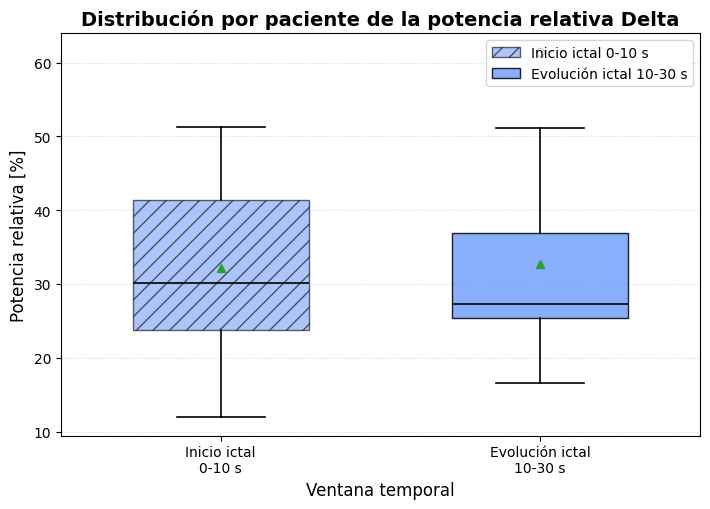

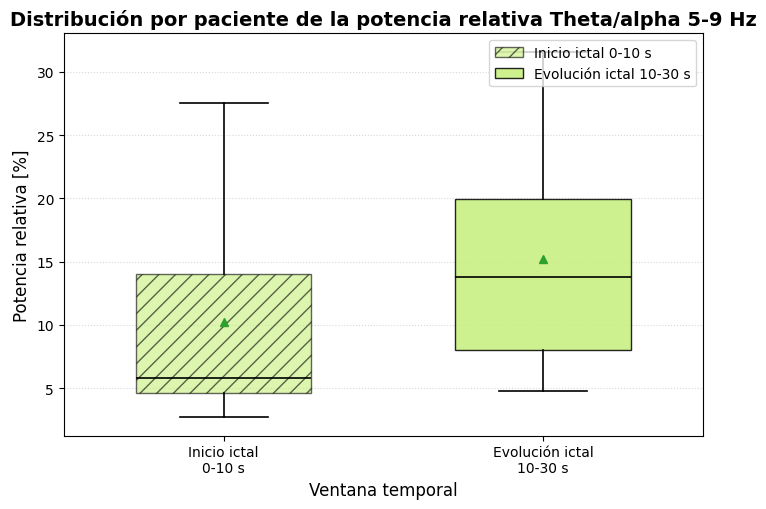

Gráfico de clasificación final guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_clasificacion_casos_potencia_relativa.png


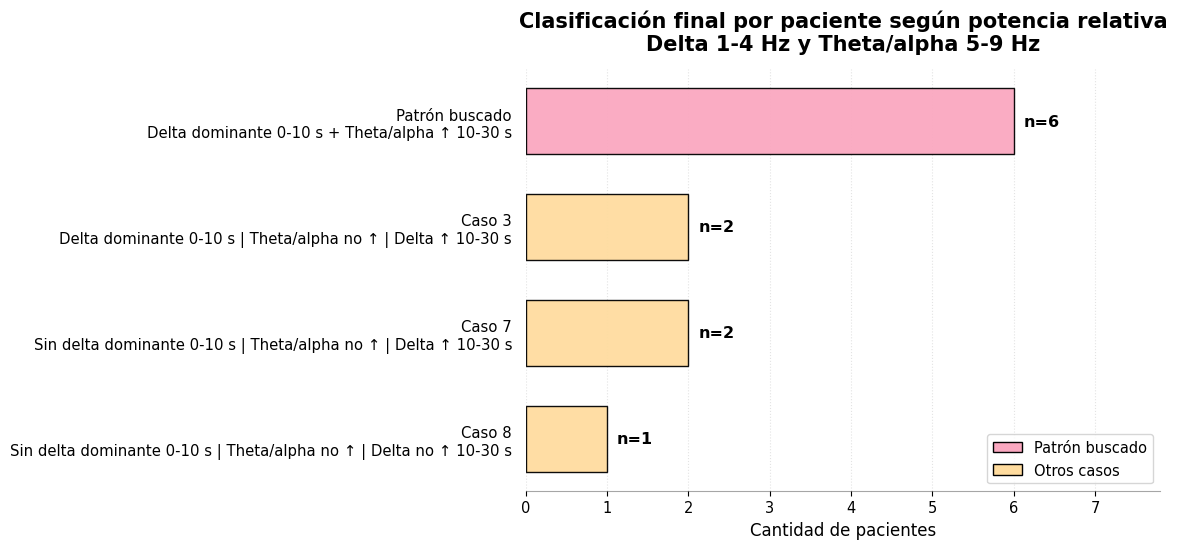

Tabla de clasificación de casos guardada como CSV en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\tabla_clasificacion_casos_potencia_relativa.csv
Clasificación individual por paciente guardada en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\clasificacion_casos_potencia_relativa_por_paciente.csv
Heatmap guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_heatmap_inicio_ictal_0_10_por_paciente.png


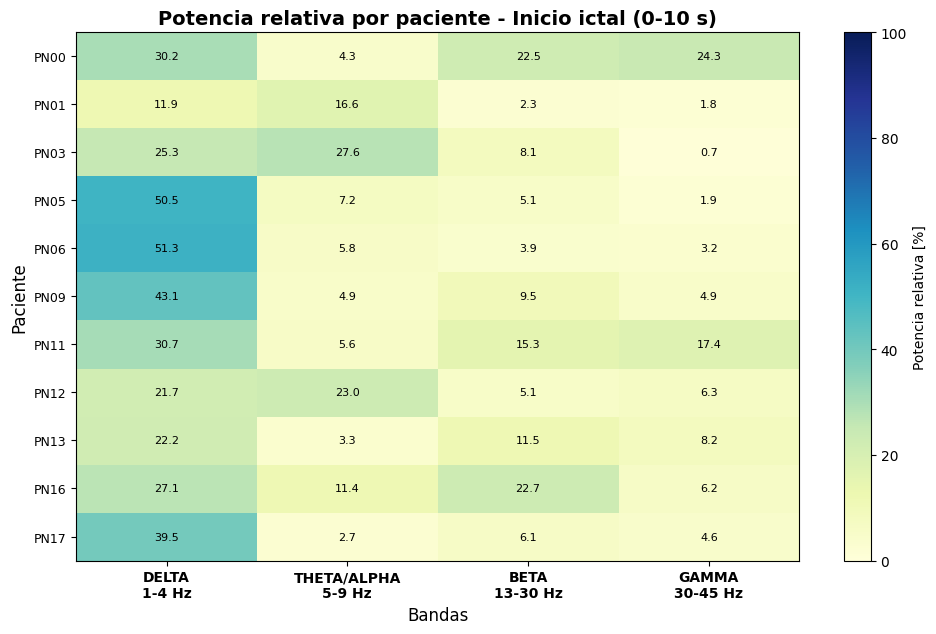

Heatmap guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_heatmap_evolucion_10_30_por_paciente.png


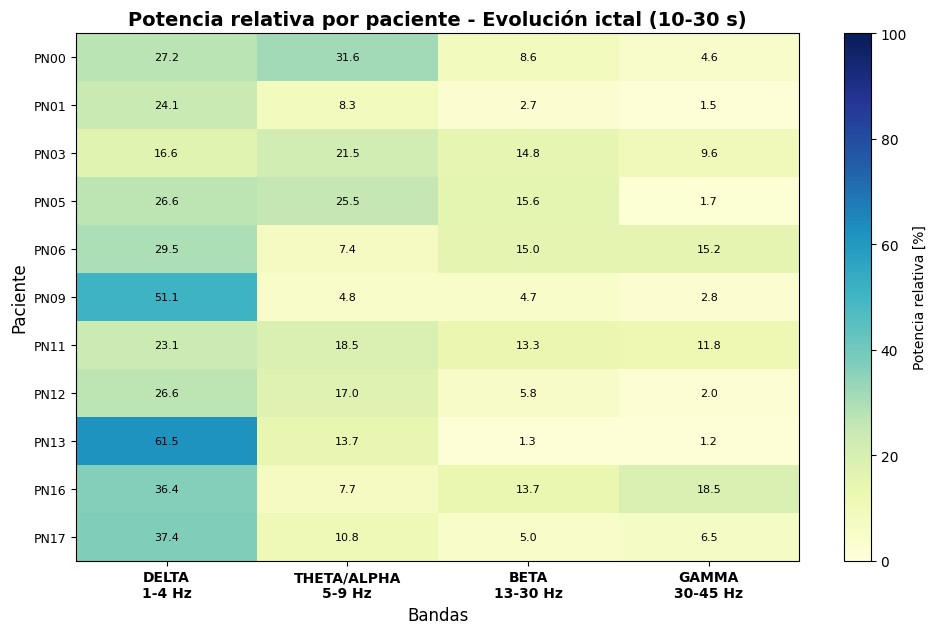

Figuras grupales generadas una sola vez y guardadas en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel


In [32]:
# ============================================================
# 11C) EJECUTAR RESUMEN GRUPAL Y GUARDAR TABLAS + FIGURAS
# ============================================================

# 1) Tabla por crisis/canal foco.
df_resumen_crisis = construir_resumen_patron_por_crisis(df_potencias)

# 2) Tabla por paciente.
# Esta es la principal para concluir sobre los 11 pacientes.
df_resumen_paciente = construir_resumen_patron_por_paciente(df_resumen_crisis)

# 3) Chequeo de coherencia interna.
validar_coherencia_resumen_patron(df_resumen_crisis)
validar_coherencia_resumen_patron(df_resumen_paciente)
print("Chequeo de coherencia de bandas dominantes: OK.")

# 4) Guardar tablas.
ruta_resumen_crisis = CARPETA_RESULTADOS_BATCH / "resumen_patron_bibliografia_por_crisis.csv"
ruta_resumen_paciente = CARPETA_RESULTADOS_BATCH / "resumen_patron_bibliografia_por_paciente.csv"

df_resumen_crisis.to_csv(ruta_resumen_crisis, index=False)
df_resumen_paciente.to_csv(ruta_resumen_paciente, index=False)

print("Resumen por crisis guardado en:", ruta_resumen_crisis)
print("Resumen por paciente guardado en:", ruta_resumen_paciente)

# 5) Mostrar tabla útil para control interno.
columnas_para_ver = [
    "patient_id",
    "lateralization",
    "canal_temporal_foco",
    "banda_dominante_0_10",
    "banda_dominante_10_30",
    "delta_0_10",
    "delta_10_30",
    "theta_alpha_5_9_0_10",
    "theta_alpha_5_9_10_30",
    "cambio_theta_alpha_5_9_10_30_menos_0_10",
    "cambio_delta_10_30_menos_0_10",
    "cumple_inicio_delta",
    "theta_alpha_dominante_0_10",
    "aumenta_theta_alpha",
    "aumenta_delta",
    "ambas_bandas_aumentan",
    "sin_aumento_delta_ni_theta_alpha",
    "cumple_patron_compatible",
]
columnas_para_ver = [c for c in columnas_para_ver if c in df_resumen_paciente.columns]

print("\nTabla resumen por paciente:")
display(df_resumen_paciente[columnas_para_ver])

# 6) Resumen numérico rápido.
n_pacientes = len(df_resumen_paciente)

print("\nResumen descriptivo por paciente:")
for col, descripcion in {
    "cumple_inicio_delta": "Delta dominante al inicio ictal (0-10 s)",
    "theta_alpha_dominante_0_10": "Theta/alpha 5-9 Hz dominante al inicio ictal (0-10 s)",
    "aumenta_theta_alpha": "Aumento de theta/alpha 5-9 Hz en evolución (10-30 s vs 0-10 s)",
    "aumenta_delta": "Aumento de delta 1-4 Hz en evolución (10-30 s vs 0-10 s)",
    "ambas_bandas_aumentan": "Aumento mixto de delta + theta/alpha",
    "sin_aumento_delta_ni_theta_alpha": "Sin aumento de delta ni theta/alpha",
}.items():
    if col not in df_resumen_paciente.columns:
        continue
    n_cumple = int(df_resumen_paciente[col].fillna(False).sum())
    porcentaje = 100 * n_cumple / n_pacientes if n_pacientes > 0 else np.nan
    print(f"- {descripcion}: {n_cumple}/{n_pacientes} pacientes ({porcentaje:.1f}%)")

# 7) Figuras grupales. Cada heatmap se llama una sola vez.
fig_boxplots_resumen = graficar_boxplot_potencia_por_banda(
    df_resumen_paciente,
    nombre_salida="resumen_boxplot_potencia_relativa_por_paciente.png",
    mostrar=True,
    cerrar=True,
)

fig_clasificacion_casos, df_tabla_transicion_apilada, df_clasificacion_transicion = graficar_barras_apiladas_transicion_perfiles(
    df_resumen_paciente,
    nombre_salida="resumen_clasificacion_casos_potencia_relativa.png",
    mostrar=True,
    cerrar=True,
)

ruta_tabla_transicion_apilada = CARPETA_RESULTADOS_BATCH / "tabla_clasificacion_casos_potencia_relativa.csv"
df_tabla_transicion_apilada.to_csv(ruta_tabla_transicion_apilada, index=False)
print("Tabla de clasificación de casos guardada como CSV en:", ruta_tabla_transicion_apilada)

ruta_clasificacion_transicion = CARPETA_RESULTADOS_BATCH / "clasificacion_casos_potencia_relativa_por_paciente.csv"
df_clasificacion_transicion.to_csv(ruta_clasificacion_transicion, index=False)
print("Clasificación individual por paciente guardada en:", ruta_clasificacion_transicion)

fig_heatmap_0_10 = graficar_heatmap_potencias(
    df_resumen_paciente,
    sufijo_ventana="0_10",
    titulo="Potencia relativa por paciente - Inicio ictal (0-10 s)",
    nombre_salida="resumen_heatmap_inicio_ictal_0_10_por_paciente.png",
    mostrar=True,
    cerrar=True,
)

fig_heatmap_10_30 = graficar_heatmap_potencias(
    df_resumen_paciente,
    sufijo_ventana="10_30",
    titulo="Potencia relativa por paciente - Evolución ictal (10-30 s)",
    nombre_salida="resumen_heatmap_evolucion_10_30_por_paciente.png",
    mostrar=True,
    cerrar=True,
)

print("Figuras grupales generadas una sola vez y guardadas en:", CARPETA_IMAGENES_PSD)



In [33]:
# ============================================================
# 11D) TABLA NUMÉRICA DE APOYO PARA LA CLASIFICACIÓN FINAL
# Correr después de generar df_resumen_paciente.
# ============================================================

if "df_resumen_paciente" not in globals() or df_resumen_paciente.empty:
    raise RuntimeError("No encontré df_resumen_paciente. Corré primero la celda 11C.")

df_tabla_transicion_apilada, df_clasificacion_transicion = construir_tabla_transicion_apilada(df_resumen_paciente)

ruta_tabla_transicion_apilada = CARPETA_RESULTADOS_BATCH / "tabla_clasificacion_casos_potencia_relativa.csv"
df_tabla_transicion_apilada.to_csv(ruta_tabla_transicion_apilada, index=False)

print("Tabla numérica usada para el gráfico final de clasificación:")
display(df_tabla_transicion_apilada)
print("CSV guardado en:", ruta_tabla_transicion_apilada)

Tabla numérica usada para el gráfico final de clasificación:


,caso_codigo,caso_descripcion,es_caso_buscado,cantidad_pacientes
0,Patrón buscado,Patrón buscado\nDelta dominante 0-10 s + Theta...,True,6
1,Caso 3,Caso 3\nDelta dominante 0-10 s | Theta/alpha n...,False,2
2,Caso 7,Caso 7\nSin delta dominante 0-10 s | Theta/alp...,False,2
3,Caso 8,Caso 8\nSin delta dominante 0-10 s | Theta/alp...,False,1


CSV guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\tabla_clasificacion_casos_potencia_relativa.csv


Promedio de potencia relativa por paciente, banda y ventana:


,banda,etiqueta_banda,promedio_0_10,promedio_10_30
0,delta,DELTA 1-4 Hz,32.13,32.73
1,theta_alpha_5_9,THETA/ALPHA 5-9 Hz,10.20,15.17
2,beta,BETA 13-30 Hz,10.19,9.13
3,gamma,GAMMA 30-45 Hz,7.23,6.86


Figura guardada en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\01_PSD_normal_log_rel\resumen_potencia_relativa_promedio_por_banda_0_10_vs_10_30.png


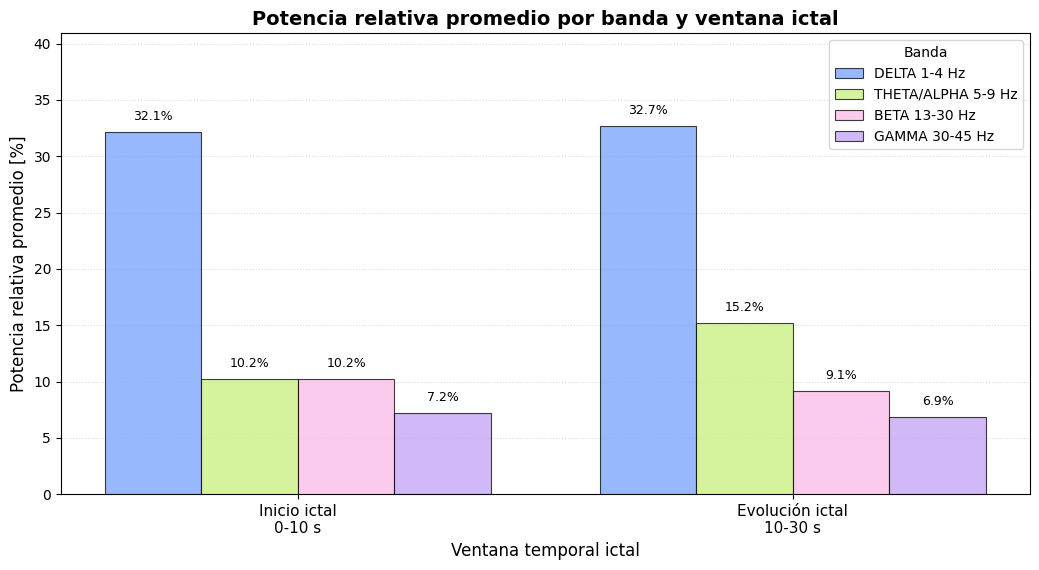

In [34]:
# ============================================================
# GRÁFICO GRUPAL — POTENCIA RELATIVA PROMEDIO POR BANDA
# ============================================================

if "df_resumen_paciente" not in globals() or df_resumen_paciente.empty:
    raise RuntimeError("No encontré df_resumen_paciente. Corré primero la celda 9B.")

bandas_plot = _bandas_heatmap_relativo()
ventanas_plot = [
    ("0_10", "Inicio ictal\n0-10 s"),
    ("10_30", "Evolución ictal\n10-30 s"),
]

columnas_necesarias = [f"{banda}_{sufijo}" for banda in bandas_plot for sufijo, _ in ventanas_plot]
faltantes = [col for col in columnas_necesarias if col not in df_resumen_paciente.columns]

if faltantes:
    raise RuntimeError(f"Faltan columnas en df_resumen_paciente: {faltantes}")

df_promedio_pot_rel_ventanas = pd.DataFrame({
    "banda": bandas_plot,
    "etiqueta_banda": [_etiqueta_banda_resumen(b).replace("\n", " ") for b in bandas_plot],
    "promedio_0_10": [
        pd.to_numeric(df_resumen_paciente[f"{b}_0_10"], errors="coerce").mean()
        for b in bandas_plot
    ],
    "promedio_10_30": [
        pd.to_numeric(df_resumen_paciente[f"{b}_10_30"], errors="coerce").mean()
        for b in bandas_plot
    ],
})

print("Promedio de potencia relativa por paciente, banda y ventana:")
display(df_promedio_pot_rel_ventanas.round(2))

x = np.arange(len(ventanas_plot))
ancho = 0.78 / len(bandas_plot)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, banda in enumerate(bandas_plot):
    valores = [
        df_promedio_pot_rel_ventanas.loc[
            df_promedio_pot_rel_ventanas["banda"].eq(banda), "promedio_0_10"
        ].iloc[0],
        df_promedio_pot_rel_ventanas.loc[
            df_promedio_pot_rel_ventanas["banda"].eq(banda), "promedio_10_30"
        ].iloc[0],
    ]

    posiciones = x - (ancho * len(bandas_plot) / 2) + (i + 0.5) * ancho

    barras = ax.bar(
        posiciones,
        valores,
        width=ancho,
        color=COLORES_POT_REL_GRAFICOS.get(banda, COLORES_RITMOS.get(banda, "gray")),
        edgecolor="black",
        linewidth=0.8,
        alpha=0.75,
        label=_etiqueta_banda_resumen(banda).replace("\n", " "),
        zorder=3,
    )

    for barra, valor in zip(barras, valores):
        if np.isfinite(valor):
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.8,
                f"{valor:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0,
            )

ax.set_xticks(x)
ax.set_xticklabels([etiqueta for _, etiqueta in ventanas_plot], fontsize=11)
ax.set_xlabel("Ventana temporal ictal", fontsize=12)
ax.set_ylabel("Potencia relativa promedio [%]", fontsize=12)
ax.set_title(
    "Potencia relativa promedio por banda y ventana ictal",
    fontsize=14,
    weight="bold",
)

ymax = np.nanmax(df_promedio_pot_rel_ventanas[["promedio_0_10", "promedio_10_30"]].to_numpy())
ax.set_ylim(0, ymax * 1.25 if np.isfinite(ymax) and ymax > 0 else 1)

ax.grid(True, axis="y", linestyle=":", alpha=0.45, zorder=0)
ax.legend(title="Banda", loc="upper right", frameon=True)

fig.tight_layout()

ruta_promedio_bandas = _guardar_figura_resumen(
    fig,
    "resumen_potencia_relativa_promedio_por_banda_0_10_vs_10_30.png",
)

print("Figura guardada en:", ruta_promedio_bandas)

plt.show()

## 12. Análisis temporal de amplitud

Calcula RMS móvil en el canal temporal de foco, compara preictal contra ictal y genera los gráficos de amplitud.


In [35]:
# ============================================================
# 12A) FUNCIONES AUXILIARES PARA AMPLITUD TEMPORAL
# ============================================================

VENTANA_AMP_MOVIL_SEC = 2.0
PASO_AMP_MOVIL_SEC = 0.5

COLOR_RMS = "#4D96FF"
COLOR_PREICTAL = "#DDF6F2"
COLOR_ICTAL = "#FFE5EC"
COLOR_POSTICTAL = "#EDE7FF"


def _rms_uv(senal_uv: np.ndarray) -> float:
    """RMS en µV. Resume la amplitud efectiva sin cancelación por signo."""
    senal_uv = np.asarray(senal_uv, dtype=float)
    senal_uv = senal_uv[np.isfinite(senal_uv)]
    if len(senal_uv) == 0:
        return np.nan
    return float(np.sqrt(np.mean(senal_uv ** 2)))


def _safe_ratio(numerador: float, denominador: float) -> float:
    """Cociente seguro; evita divisiones inválidas."""
    if pd.isna(numerador) or pd.isna(denominador) or denominador == 0:
        return np.nan
    return float(numerador / denominador)


def _safe_log2_ratio(numerador: float, denominador: float) -> float:
    """Calcula log2(numerador/denominador) de forma segura."""
    if pd.isna(numerador) or pd.isna(denominador) or numerador <= 0 or denominador <= 0:
        return np.nan
    return float(np.log2(numerador / denominador))


def _obtener_segmento_filtrado_del_cache(evento):
    """
    Recupera del cache la ventana extendida ya filtrada para una crisis.
    Evita volver a cargar o filtrar el EDF.
    """
    if "CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS" not in globals():
        raise RuntimeError("No existe CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS. Ejecutá primero la celda 8B.")
    if "_clave_cache_evento" not in globals():
        raise RuntimeError("No existe _clave_cache_evento. Ejecutá primero las funciones de PSD de la sección 6.")

    cache_key = _clave_cache_evento(evento)
    item = CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS.get(cache_key)

    if item is None:
        raise RuntimeError(
            "No se encontró esta crisis en CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS. "
            "Asegurate de haber corrido 8B con el mismo df_eventos_a_procesar."
        )

    return item["raw_ext_filtrado"], item["info_ventana"], item["inicio_local"], item["fin_local"]


def _extraer_senal_intervalo_uv(
    raw_filtrado: mne.io.BaseRaw,
    canal: str,
    tmin_local: float,
    tmax_local: float,
) -> tuple[float, np.ndarray]:
    """Extrae un intervalo de un canal en µV desde una ventana Raw ya filtrada."""
    if canal not in raw_filtrado.ch_names:
        raise ValueError(f"El canal {canal} no está disponible en esta señal.")

    tmin_local = max(0.0, float(tmin_local))
    tmax_local = min(float(raw_filtrado.times[-1]), float(tmax_local))

    fs = float(raw_filtrado.info["sfreq"])
    if tmax_local <= tmin_local:
        return fs, np.array([], dtype=float)

    segmento = recortar_intervalo(raw_filtrado, tmin_local, tmax_local)
    if segmento is None:
        return fs, np.array([], dtype=float)

    senal_uv = segmento.get_data(picks=[canal])[0] * 1e6
    return fs, senal_uv


def _fase_desde_tiempo_relativo(t_rel: float, duracion_ictal_s: float) -> str:
    """Clasifica un tiempo relativo al inicio de crisis como preictal, ictal o postictal."""
    if t_rel < 0:
        return "preictal"
    if t_rel <= duracion_ictal_s:
        return "ictal"
    return "postictal"

def rms_movil_df(senal_uv, fs, t0_rel, ventana_sec=VENTANA_AMP_MOVIL_SEC, paso_sec=PASO_AMP_MOVIL_SEC):
    """Calcula RMS móvil en ventanas deslizantes."""
    n_win = int(round(ventana_sec * fs))
    n_step = int(round(paso_sec * fs))

    if n_win <= 0 or n_step <= 0 or len(senal_uv) < n_win:
        return pd.DataFrame(columns=["tiempo_centro_rel_crisis_s", "rms_uv"])

    filas = []
    for i in range(0, len(senal_uv) - n_win + 1, n_step):
        j = i + n_win
        filas.append({
            "tiempo_centro_rel_crisis_s": t0_rel + ((i + j) / 2) / fs,
            "rms_uv": _rms_uv(senal_uv[i:j]),
        })

    return pd.DataFrame(filas)

def graficar_rms_individual(df_ev, resumen_ev, guardar_en=None, mostrar=True, cerrar=True):
    """Gráfico individual: RMS móvil con sombreado y marcas de inicio/fin de crisis."""
    if df_ev.empty:
        return None

    dur = float(resumen_ev["duracion_ictal_s"])
    xmin = float(df_ev["tiempo_centro_rel_crisis_s"].min())
    xmax = float(df_ev["tiempo_centro_rel_crisis_s"].max())

    fig, ax = plt.subplots(figsize=(14.5, 5.4))
    ax.axvspan(xmin, 0, color=COLOR_PREICTAL, alpha=0.65, label="Preictal")
    ax.axvspan(0, dur, color=COLOR_ICTAL, alpha=0.75, label="Ictal")
    ax.axvspan(dur, xmax, color=COLOR_POSTICTAL, alpha=0.65, label="Postictal")
    ax.plot(
        df_ev["tiempo_centro_rel_crisis_s"],
        df_ev["rms_uv"],
        color=COLOR_RMS,
        linewidth=2.5,
        label=f"RMS móvil ({VENTANA_AMP_MOVIL_SEC:.1f} s)",
    )

    ax.axvline(0, color="black", linestyle=":", linewidth=1.8)
    ax.axvline(dur, color="black", linestyle=":", linewidth=1.8)
    ax.annotate("Inicio crisis", xy=(0, 0.97), xycoords=("data", "axes fraction"),
                xytext=(5, 0), textcoords="offset points", rotation=90,
                ha="left", va="top", fontsize=9)
    ax.annotate("Fin crisis", xy=(dur, 0.97), xycoords=("data", "axes fraction"),
                xytext=(5, 0), textcoords="offset points", rotation=90,
                ha="left", va="top", fontsize=9)

    ymax = np.nanmax(df_ev["rms_uv"].values)
    if np.isfinite(ymax):
        ax.set_ylim(0, ymax * 1.15)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Tiempo relativo al inicio de la crisis [s]")
    ax.set_ylabel("RMS [µV]")
    ax.set_title(
        f"RMS temporal - {resumen_ev['patient_id']} | {resumen_ev['edf_filename']} | "
        f"crisis {resumen_ev['seizure_index_in_file']}\n"
        f"Canal foco {resumen_ev['canal_temporal_foco']}",
        fontsize=13,
        weight="bold",
    )
    ax.grid(True, linestyle=":", alpha=0.42)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9.5)
    fig.tight_layout(rect=[0, 0, 0.83, 1])

    if guardar_en is not None:
        guardar_figura(fig, guardar_en)
    if mostrar:
        plt.show()
    if cerrar:
        plt.close(fig)

    return fig


def graficar_rms_pareado_preictal_ictal(
    df_resumen,
    nombre_salida="rms_pareado_preictal_ictal.png",
    mostrar=True,
    cerrar=True,
):
    """
    Gráfico general simple: comparación pareada del RMS preictal vs ictal.
    Cada línea corresponde a una crisis. Si la línea sube, el RMS ictal fue mayor.
    """
    if df_resumen is None or df_resumen.empty:
        return None

    cols_necesarias = ["rms_preictal_uv", "rms_ictal_uv"]
    if not all(c in df_resumen.columns for c in cols_necesarias):
        return None

    df_plot = df_resumen.dropna(subset=cols_necesarias).copy()
    if df_plot.empty:
        return None

    columnas_orden = [
        c for c in ["patient_id", "edf_filename", "seizure_index_in_file"]
        if c in df_plot.columns
    ]
    if columnas_orden:
        df_plot = df_plot.sort_values(columnas_orden).reset_index(drop=True)

    n_total = len(df_plot)
    n_aumenta = int((df_plot["rms_ictal_uv"] > df_plot["rms_preictal_uv"]).sum())
    mediana_pre = np.nanmedian(df_plot["rms_preictal_uv"])
    mediana_ictal = np.nanmedian(df_plot["rms_ictal_uv"])

    fig, ax = plt.subplots(figsize=(8.5, 6.0))

    for _, fila in df_plot.iterrows():
        y = [fila["rms_preictal_uv"], fila["rms_ictal_uv"]]
        ax.plot([0, 1], y, color="#8EC5FC", alpha=0.75, linewidth=1.7)
        ax.scatter([0, 1], y, color="#8EC5FC", alpha=0.85, s=36)

    ax.plot(
        [0, 1],
        [mediana_pre, mediana_ictal],
        color="navy",
        linewidth=1.5,
        marker="o",
        markersize=7,
        label="Mediana grupal",
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Preictal", "Ictal"])
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylabel("RMS [µV]")
    ax.set_title(
        "Cambio de amplitud efectiva preictal → ictal\n"
        "Comparación pareada del RMS por crisis",
        fontsize=13,
        weight="bold",
    )
    ax.grid(True, axis="y", linestyle=":", alpha=0.45)

    ymax = np.nanmax(df_plot[["rms_preictal_uv", "rms_ictal_uv"]].to_numpy(float))
    if np.isfinite(ymax):
        ax.set_ylim(0, ymax * 1.18)

    ax.text(
        0.02,
        0.96,
        f"Aumenta RMS: {n_aumenta}/{n_total} crisis",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.85"),
    )
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    fig.tight_layout(rect=[0, 0, 0.82, 1])

    ruta = CARPETA_IMAGENES_AMPLITUD / nombre_salida
    guardar_figura(fig, ruta)
    print("Gráfico pareado preictal/ictal guardado en:", ruta)

    if mostrar:
        plt.show()
    if cerrar:
        plt.close(fig)

    return fig





Analizando amplitud RMS: PN00-1.edf | crisis 1

Analizando amplitud RMS: PN01-1.edf | crisis 1

Analizando amplitud RMS: PN03-2.edf | crisis 1

Analizando amplitud RMS: PN05-2.edf | crisis 1

Analizando amplitud RMS: PN06-1.edf | crisis 1

Analizando amplitud RMS: PN09-1.edf | crisis 1

Analizando amplitud RMS: PN11-1.edf | crisis 1

Analizando amplitud RMS: PN12-3.edf | crisis 1

Analizando amplitud RMS: PN13-1.edf | crisis 1

Analizando amplitud RMS: PN16-1.edf | crisis 1

Analizando amplitud RMS: PN17-2.edf | crisis 1

Análisis de amplitud RMS terminado.
Curvas RMS guardadas en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\curvas_RMS_amplitud_temporal.csv
Resumen de cambio RMS preictal→ictal guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\resumen_cambio_RMS_preictal_ictal_por_crisis.csv
Errores de amplitud guardados en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\errores_amplitud_RMS_preictal_ictal.csv

Resumen de cambio de amplitud RMS p

,patient_id,edf_filename,seizure_index_in_file,lateralization,canal_temporal_foco,duracion_ictal_s,rms_preictal_uv,rms_ictal_uv,delta_rms_ictal_preictal_uv,ratio_rms_ictal_preictal,porcentaje_cambio_rms_ictal_vs_preictal,log2_rms_ictal_preictal,aumenta_rms_ictal_vs_preictal
0,PN00,PN00-1.edf,1,R,T4,70.0,19.808712,38.662921,18.854210,1.951814,95.181402,0.964816,True
1,PN01,PN01-1.edf,1,L,T3,54.0,15.067975,45.586936,30.518961,3.025419,202.541884,1.597135,True
2,PN03,PN03-2.edf,1,R,T4,133.0,9.880085,115.880224,106.000138,11.728666,1072.866624,3.551967,True
3,PN05,PN05-2.edf,1,L,T3,35.0,14.436980,31.267027,16.830047,2.165760,116.575953,1.114873,True
4,PN06,PN06-1.edf,1,L,T3,64.0,23.571947,35.750717,12.178769,1.516664,51.666369,0.600901,True
5,PN09,PN09-1.edf,1,L,T3,80.0,20.998258,32.300721,11.302463,1.538257,53.825717,0.621297,True
6,PN11,PN11-1.edf,1,R,T4,55.0,21.258927,38.482552,17.223625,1.810183,81.018315,0.856136,True
7,PN12,PN12-3.edf,1,L,T3,96.0,18.568326,36.062603,17.494277,1.942157,94.215691,0.957660,True
8,PN13,PN13-1.edf,1,L,T3,48.0,17.280934,51.972201,34.691267,3.007488,200.748802,1.588559,True
9,PN16,PN16-1.edf,1,L,T3,123.0,6.065719,113.685699,107.619980,18.742328,1774.232827,4.228228,True



Resumen cuantitativo descriptivo:
- Aumento de RMS de preictal a ictal: 11/11 crisis (100.0%).
- Mediana grupal del cociente RMS ictal/preictal: 2.166.
- Mediana grupal del cambio log2(RMS ictal/preictal): 1.115.
- Interpretación: RMS se usa como amplitud efectiva. Este resultado describe el cambio preictal→ictal; no demuestra lateralidad ni foco.
Gráfico pareado preictal/ictal guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\02_amplitud\rms_pareado_preictal_ictal.png


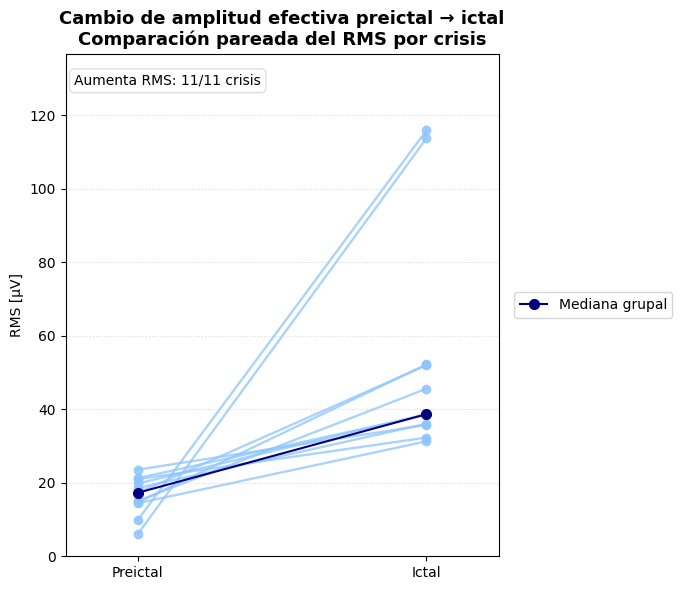

In [36]:
# ============================================================
# 12B) EJECUTAR ANÁLISIS DE AMPLITUD TEMPORAL
# ============================================================

if "df_eventos_a_procesar" not in globals():
    if "df_eventos_crisis" not in globals():
        raise RuntimeError("Primero ejecutá la celda 12A para crear df_eventos_crisis.")
    df_eventos_a_procesar = df_eventos_crisis.copy()

curvas = []
resumenes_amplitud = []
errores_amplitud = []

CARPETA_IMAGENES_AMPLITUD.mkdir(parents=True, exist_ok=True)
CARPETA_RESULTADOS_BATCH.mkdir(parents=True, exist_ok=True)

for _, evento in df_eventos_a_procesar.iterrows():
    ruta_edf = evento["edf_path"]

    try:
        print(f"\nAnalizando amplitud RMS: {Path(ruta_edf).name} | crisis {evento['seizure_index_in_file']}")

        raw_ext_filtrado, info_ventana, inicio_local, fin_local = _obtener_segmento_filtrado_del_cache(evento)
        canal_foco = evento["canal_temporal_foco"]
        duracion_ictal = float(fin_local - inicio_local)

        tmin_pre = max(0.0, inicio_local - PREICTAL_ANALISIS_SEC)
        tmax_pre = inicio_local
        tmin_ictal = inicio_local
        tmax_ictal = fin_local
        tmax_total = min(float(raw_ext_filtrado.times[-1]), fin_local + POSTICTAL_ANALISIS_SEC)

        fs_total, senal_total_uv = _extraer_senal_intervalo_uv(raw_ext_filtrado, canal_foco, tmin_pre, tmax_total)
        df_curva_evento = rms_movil_df(senal_total_uv, fs_total, t0_rel=tmin_pre - inicio_local)

        df_curva_evento["fase"] = df_curva_evento["tiempo_centro_rel_crisis_s"].apply(
            lambda t: _fase_desde_tiempo_relativo(t, duracion_ictal)
        )

        for col in ["patient_id", "edf_filename", "seizure_index_in_file", "lateralization"]:
            df_curva_evento[col] = evento.get(col)

        df_curva_evento["canal_temporal_foco"] = canal_foco
        df_curva_evento["duracion_ictal_s"] = duracion_ictal
        curvas.append(df_curva_evento)

        _, senal_pre_uv = _extraer_senal_intervalo_uv(raw_ext_filtrado, canal_foco, tmin_pre, tmax_pre)
        _, senal_ictal_uv = _extraer_senal_intervalo_uv(raw_ext_filtrado, canal_foco, tmin_ictal, tmax_ictal)

        rms_pre = _rms_uv(senal_pre_uv)
        rms_ictal = _rms_uv(senal_ictal_uv)
        ratio = _safe_ratio(rms_ictal, rms_pre)

        resumen_evento = {
            "patient_id": evento.get("patient_id"),
            "edf_filename": evento.get("edf_filename"),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "lateralization": evento.get("lateralization"),
            "canal_temporal_foco": canal_foco,
            "duracion_ictal_s": duracion_ictal,
            "rms_preictal_uv": rms_pre,
            "rms_ictal_uv": rms_ictal,
            "delta_rms_ictal_preictal_uv": rms_ictal - rms_pre,
            "ratio_rms_ictal_preictal": ratio,
            "porcentaje_cambio_rms_ictal_vs_preictal": (ratio - 1) * 100 if np.isfinite(ratio) else np.nan,
            "log2_rms_ictal_preictal": _safe_log2_ratio(rms_ictal, rms_pre),
            "aumenta_rms_ictal_vs_preictal": bool(ratio > 1) if np.isfinite(ratio) else False,
        }
        resumenes_amplitud.append(resumen_evento)

        if globals().get("GUARDAR_IMAGENES", True):
            prefijo_img = limpiar_nombre_archivo(
                f"{evento['patient_id']}_{evento['edf_filename']}_crisis{evento['seizure_index_in_file']}_RMS_{canal_foco}"
            )
            _ = graficar_rms_individual(
                df_curva_evento,
                resumen_evento,
                guardar_en=CARPETA_IMAGENES_AMPLITUD / f"{prefijo_img}_rms_temporal.png",
                mostrar=MOSTRAR_GRAFICOS if "MOSTRAR_GRAFICOS" in globals() else False,
                cerrar=CERRAR_FIGURAS if "CERRAR_FIGURAS" in globals() else True,
            )

    except Exception as exc:
        errores_amplitud.append({
            "patient_id": evento.get("patient_id"),
            "edf_path": ruta_edf,
            "edf_filename": evento.get("edf_filename", Path(ruta_edf).name),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "canal_temporal_foco": evento.get("canal_temporal_foco"),
            "fase_error": "amplitud_RMS_preictal_ictal",
            "error": repr(exc),
        })

df_curvas_amplitud = pd.concat(curvas, ignore_index=True) if curvas else pd.DataFrame()
df_resumen_amplitud = pd.DataFrame(resumenes_amplitud)
df_errores_amplitud = pd.DataFrame(errores_amplitud)
df_cambio_amplitud_pre_ictal = df_resumen_amplitud.copy()

ruta_curvas_amplitud = CARPETA_RESULTADOS_BATCH / "curvas_RMS_amplitud_temporal.csv"
ruta_resumen_amplitud = CARPETA_RESULTADOS_BATCH / "resumen_cambio_RMS_preictal_ictal_por_crisis.csv"
ruta_errores_amplitud = CARPETA_RESULTADOS_BATCH / "errores_amplitud_RMS_preictal_ictal.csv"

df_curvas_amplitud.to_csv(ruta_curvas_amplitud, index=False)
df_resumen_amplitud.to_csv(ruta_resumen_amplitud, index=False)
df_errores_amplitud.to_csv(ruta_errores_amplitud, index=False)

print("\nAnálisis de amplitud RMS terminado.")
print("Curvas RMS guardadas en:", ruta_curvas_amplitud)
print("Resumen de cambio RMS preictal→ictal guardado en:", ruta_resumen_amplitud)
print("Errores de amplitud guardados en:", ruta_errores_amplitud)

columnas_amp = [
    "patient_id",
    "edf_filename",
    "seizure_index_in_file",
    "lateralization",
    "canal_temporal_foco",
    "duracion_ictal_s",
    "rms_preictal_uv",
    "rms_ictal_uv",
    "delta_rms_ictal_preictal_uv",
    "ratio_rms_ictal_preictal",
    "porcentaje_cambio_rms_ictal_vs_preictal",
    "log2_rms_ictal_preictal",
    "aumenta_rms_ictal_vs_preictal",
]
columnas_amp = [c for c in columnas_amp if c in df_resumen_amplitud.columns]

print("\nResumen de cambio de amplitud RMS preictal → ictal:")
display(df_resumen_amplitud[columnas_amp])

if not df_errores_amplitud.empty:
    print("\nErrores en análisis de amplitud:")
    display(df_errores_amplitud)

if not df_resumen_amplitud.empty:
    n_total = len(df_resumen_amplitud)
    n_aumenta = int(df_resumen_amplitud["aumenta_rms_ictal_vs_preictal"].sum())
    mediana_ratio = np.nanmedian(df_resumen_amplitud["ratio_rms_ictal_preictal"])
    mediana_log2 = np.nanmedian(df_resumen_amplitud["log2_rms_ictal_preictal"])

    print("\nResumen cuantitativo descriptivo:")
    print(f"- Aumento de RMS de preictal a ictal: {n_aumenta}/{n_total} crisis ({100*n_aumenta/n_total:.1f}%).")
    print(f"- Mediana grupal del cociente RMS ictal/preictal: {mediana_ratio:.3f}.")
    print(f"- Mediana grupal del cambio log2(RMS ictal/preictal): {mediana_log2:.3f}.")
    print(
        "- Interpretación: RMS se usa como amplitud efectiva. "
        "Este resultado describe el cambio preictal→ictal; no demuestra lateralidad ni foco."
    )

_ = graficar_rms_pareado_preictal_ictal(df_resumen_amplitud)

## 13. Lateralidad espectral con potencia relativa

Compara lateralidad monopolar T3/T4 y bipolar temporal usando potencia relativa en las ventanas ictales definidas.


In [37]:
# ============================================================
# 13A) CÁLCULO DE LATERALIDAD ESPECTRAL CON POTENCIA RELATIVA
# ============================================================

if "df_eventos_a_procesar" not in globals():
    if "df_eventos_crisis" not in globals():
        raise RuntimeError("Primero ejecutá 12A/12B para tener df_eventos_a_procesar o df_eventos_crisis.")
    df_eventos_a_procesar = df_eventos_crisis.copy()

if "CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS" not in globals():
    raise RuntimeError("No existe CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS. Ejecutá primero 12B.")

UMBRAL_LAT_REL = 0.10

PATRONES_LATERALIDAD_REL = {
    "delta_1_4Hz_0_10s": {
        "ventana": VENTANA_INICIO_ICTAL,
        "banda": BANDA_DELTA_RITMICA,
        "descripcion": "Delta 1-4 Hz | 0-10 s",
        "patron_corto": "Delta 1-4 Hz\n0-10 s",
    },
    "delta_1_4Hz_10_30s": {
        "ventana": VENTANA_EVOLUCION_ICTAL,
        "banda": BANDA_DELTA_RITMICA,
        "descripcion": "Delta 1-4 Hz | 10-30 s",
        "patron_corto": "Delta 1-4 Hz\n10-30 s",
    },
    "theta_alpha_5_9Hz_0_10s": {
        "ventana": VENTANA_INICIO_ICTAL,
        "banda": BANDA_THETA_ALPHA_RITMICA,
        "descripcion": "Theta/alpha 5-9 Hz | 0-10 s",
        "patron_corto": "Theta/alpha 5-9 Hz\n0-10 s",
    },
    "theta_alpha_5_9Hz_10_30s": {
        "ventana": VENTANA_EVOLUCION_ICTAL,
        "banda": BANDA_THETA_ALPHA_RITMICA,
        "descripcion": "Theta/alpha 5-9 Hz | 10-30 s",
        "patron_corto": "Theta/alpha 5-9 Hz\n10-30 s",
    },
}

DERIVACIONES_BIPOLARES_TEMPORALES = {
    "L": {"F7-T3": ("F7", "T3"), "T3-T5": ("T3", "T5")},
    "R": {"F8-T4": ("F8", "T4"), "T4-T6": ("T4", "T6")},
}


def _clasificar_lateralidad(indice, umbral=UMBRAL_LAT_REL):
    """Convierte el índice R-L en una predicción exploratoria de lateralidad."""
    if pd.isna(indice):
        return "indeterminado"
    if indice < -umbral:
        return "L"
    if indice > umbral:
        return "R"
    return "indeterminado"


def _resultado_lateralidad(prediccion, lateralidad_clinica):
    """Etiqueta la concordancia con la lateralidad clínica."""
    prediccion = str(prediccion).strip().upper()
    lateralidad_clinica = str(lateralidad_clinica).strip().upper()

    if prediccion == "INDETERMINADO":
        return "Sin predominio claro"
    if prediccion in ["L", "R"] and lateralidad_clinica in ["L", "R"] and prediccion == lateralidad_clinica:
        return "Bien / compatible"
    return "Mal / no compatible"


def _senal_monopolar_uv(raw_filtrado, canal, tmin, tmax):
    """Extrae una señal monopolar filtrada en µV para la ventana pedida."""
    if canal not in raw_filtrado.ch_names:
        raise ValueError(f"Falta el canal {canal}.")

    seg = recortar_intervalo(raw_filtrado, tmin, tmax)
    if seg is None:
        raise ValueError(f"No se pudo recortar {tmin:.2f}-{tmax:.2f} s.")

    fs = float(seg.info["sfreq"])
    senal_uv = seg.get_data(picks=[canal])[0] * 1e6
    return fs, senal_uv


def _senal_bipolar_uv(raw_filtrado, ch_a, ch_b, tmin, tmax):
    """Construye una derivación bipolar ch_a - ch_b en µV para la ventana pedida."""
    for ch in (ch_a, ch_b):
        if ch not in raw_filtrado.ch_names:
            raise ValueError(f"Falta el canal {ch}.")

    seg = recortar_intervalo(raw_filtrado, tmin, tmax)
    if seg is None:
        raise ValueError(f"No se pudo recortar {tmin:.2f}-{tmax:.2f} s.")

    fs = float(seg.info["sfreq"])
    data_uv = seg.get_data(picks=[ch_a, ch_b]) * 1e6
    senal_bipolar_uv = data_uv[0] - data_uv[1]
    return fs, senal_bipolar_uv


def _potencia_relativa_banda(senal_uv, fs, banda, rango_total=RANGO_TOTAL_POT_REL):
    """
    Calcula potencia relativa de una banda:
        100 * potencia_banda / potencia_total_0.5_45
    También devuelve la frecuencia de pico dentro de la banda para control descriptivo.
    """
    f, Pxx = calcular_psd_welch_desde_senal(senal_uv, fs)

    fmin, fmax = banda
    idx_banda = (f >= fmin) & (f < fmax)
    idx_total = (f >= rango_total[0]) & (f <= rango_total[1])

    if idx_banda.sum() < 2 or idx_total.sum() < 2:
        return np.nan, np.nan

    pot_banda = float(np.trapz(Pxx[idx_banda], f[idx_banda]))
    pot_total = float(np.trapz(Pxx[idx_total], f[idx_total]))

    pot_rel = float(100 * pot_banda / pot_total) if np.isfinite(pot_total) and pot_total > 0 else np.nan

    f_banda = f[idx_banda]
    P_banda = Pxx[idx_banda]
    f_pico = float(f_banda[np.argmax(P_banda)]) if len(P_banda) else np.nan

    return pot_rel, f_pico


def calcular_lateralidad_monopolar_relativa(evento, raw_ext_filtrado, inicio_local, fin_local):
    """Calcula lateralidad espectral relativa comparando T3 vs T4."""
    filas = []
    lat_clinica = str(evento.get("lateralization")).strip().upper()
    duracion_ictal = float(fin_local - inicio_local)

    for patron, cfg in PATRONES_LATERALIDAD_REL.items():
        v0, v1 = cfg["ventana"]
        banda = cfg["banda"]
        tmin = inicio_local + float(v0)
        tmax = inicio_local + float(v1)

        if tmax > fin_local:
            raise ValueError(f"Crisis de {duracion_ictal:.2f} s: no alcanza para ventana {v0}-{v1} s.")

        fs_T3, sig_T3 = _senal_monopolar_uv(raw_ext_filtrado, "T3", tmin, tmax)
        fs_T4, sig_T4 = _senal_monopolar_uv(raw_ext_filtrado, "T4", tmin, tmax)

        pot_rel_T3, f_pico_T3 = _potencia_relativa_banda(sig_T3, fs_T3, banda)
        pot_rel_T4, f_pico_T4 = _potencia_relativa_banda(sig_T4, fs_T4, banda)

        indice_rel = _safe_ratio(pot_rel_T4 - pot_rel_T3, pot_rel_T4 + pot_rel_T3)
        pred = _clasificar_lateralidad(indice_rel)

        filas.append({
            "metodo": "Monopolar T3/T4",
            "patient_id": evento.get("patient_id"),
            "edf_filename": evento.get("edf_filename"),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "lateralization": lat_clinica,
            "patron": patron,
            "descripcion_patron": cfg["descripcion"],
            "patron_corto": cfg["patron_corto"],
            "ventana_s": f"{v0}-{v1}",
            "banda_hz": f"{banda[0]}-{banda[1]}",
            "pot_rel_L_pct": pot_rel_T3,
            "pot_rel_R_pct": pot_rel_T4,
            "indice_pot_rel_R_menos_L": indice_rel,
            "f_pico_L_hz": f_pico_T3,
            "f_pico_R_hz": f_pico_T4,
            "prediccion_lateralidad_REL": pred,
            "resultado_REL": _resultado_lateralidad(pred, lat_clinica),
        })

    return filas


def calcular_lateralidad_bipolar_relativa(evento, raw_ext_filtrado, inicio_local, fin_local):
    """Calcula lateralidad espectral relativa con derivaciones bipolares temporales."""
    filas = []
    lat_clinica = str(evento.get("lateralization")).strip().upper()
    duracion_ictal = float(fin_local - inicio_local)

    for patron, cfg in PATRONES_LATERALIDAD_REL.items():
        v0, v1 = cfg["ventana"]
        banda = cfg["banda"]
        tmin = inicio_local + float(v0)
        tmax = inicio_local + float(v1)

        if tmax > fin_local:
            raise ValueError(f"Crisis de {duracion_ictal:.2f} s: no alcanza para ventana {v0}-{v1} s.")

        resultados = {"L": {}, "R": {}}

        for lado, derivaciones in DERIVACIONES_BIPOLARES_TEMPORALES.items():
            for nombre_deriv, (ch_a, ch_b) in derivaciones.items():
                fs, sig_uv = _senal_bipolar_uv(raw_ext_filtrado, ch_a, ch_b, tmin, tmax)
                pot_rel, f_pico = _potencia_relativa_banda(sig_uv, fs, banda)
                resultados[lado][nombre_deriv] = {"pot_rel": pot_rel, "f_pico": f_pico}

        pot_rel_L = float(np.nanmedian([r["pot_rel"] for r in resultados["L"].values()]))
        pot_rel_R = float(np.nanmedian([r["pot_rel"] for r in resultados["R"].values()]))
        f_pico_L = float(np.nanmedian([r["f_pico"] for r in resultados["L"].values()]))
        f_pico_R = float(np.nanmedian([r["f_pico"] for r in resultados["R"].values()]))

        indice_rel = _safe_ratio(pot_rel_R - pot_rel_L, pot_rel_R + pot_rel_L)
        pred = _clasificar_lateralidad(indice_rel)

        filas.append({
            "metodo": "Bipolar temporal",
            "patient_id": evento.get("patient_id"),
            "edf_filename": evento.get("edf_filename"),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "lateralization": lat_clinica,
            "patron": patron,
            "descripcion_patron": cfg["descripcion"],
            "patron_corto": cfg["patron_corto"],
            "ventana_s": f"{v0}-{v1}",
            "banda_hz": f"{banda[0]}-{banda[1]}",
            "pot_rel_L_pct": pot_rel_L,
            "pot_rel_R_pct": pot_rel_R,
            "indice_pot_rel_R_menos_L": indice_rel,
            "f_pico_L_hz": f_pico_L,
            "f_pico_R_hz": f_pico_R,
            "prediccion_lateralidad_REL": pred,
            "resultado_REL": _resultado_lateralidad(pred, lat_clinica),
        })

    return filas


filas_lateralidad = []
errores_lateralidad = []

for _, evento in df_eventos_a_procesar.iterrows():
    try:
        raw_ext_filtrado, info_ventana, inicio_local, fin_local = _obtener_segmento_filtrado_del_cache(evento)

        filas_lateralidad.extend(
            calcular_lateralidad_monopolar_relativa(
                evento=evento,
                raw_ext_filtrado=raw_ext_filtrado,
                inicio_local=inicio_local,
                fin_local=fin_local,
            )
        )

        filas_lateralidad.extend(
            calcular_lateralidad_bipolar_relativa(
                evento=evento,
                raw_ext_filtrado=raw_ext_filtrado,
                inicio_local=inicio_local,
                fin_local=fin_local,
            )
        )

    except Exception as exc:
        errores_lateralidad.append({
            "patient_id": evento.get("patient_id"),
            "edf_filename": evento.get("edf_filename"),
            "seizure_index_in_file": evento.get("seizure_index_in_file"),
            "lateralization": evento.get("lateralization"),
            "fase_error": "lateralidad_espectral_relativa",
            "error": repr(exc),
        })

df_lateralidad_espectral_REL = pd.DataFrame(filas_lateralidad)
df_errores_lateralidad_espectral_REL = pd.DataFrame(errores_lateralidad)

# Nombres de compatibilidad por si alguna celda vieja los usaba.
df_lateralidad_espectral_monopolar_REL = df_lateralidad_espectral_REL[
    df_lateralidad_espectral_REL["metodo"] == "Monopolar T3/T4"
].copy() if not df_lateralidad_espectral_REL.empty else pd.DataFrame()

df_lateralidad_espectral_bipolar_REL = df_lateralidad_espectral_REL[
    df_lateralidad_espectral_REL["metodo"] == "Bipolar temporal"
].copy() if not df_lateralidad_espectral_REL.empty else pd.DataFrame()

ruta_lateralidad_REL = CARPETA_RESULTADOS_BATCH / "lateralidad_espectral_potencia_relativa_por_crisis.csv"
ruta_errores_lateralidad_REL = CARPETA_RESULTADOS_BATCH / "errores_lateralidad_espectral_potencia_relativa.csv"

df_lateralidad_espectral_REL.to_csv(ruta_lateralidad_REL, index=False)
df_errores_lateralidad_espectral_REL.to_csv(ruta_errores_lateralidad_REL, index=False)

print("Lateralidad espectral relativa calculada.")
print("CSV de lateralidad por crisis guardado en:", ruta_lateralidad_REL)
print(f"- Filas totales: {len(df_lateralidad_espectral_REL)}")
print(f"- Monopolar T3/T4: {len(df_lateralidad_espectral_monopolar_REL)} filas")
print(f"- Bipolar temporal: {len(df_lateralidad_espectral_bipolar_REL)} filas")

if not df_errores_lateralidad_espectral_REL.empty:
    print("\nEventos con error en lateralidad espectral relativa:")
    display(df_errores_lateralidad_espectral_REL)


C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2512984298.py:116: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_banda = float(np.trapz(Pxx[idx_banda], f[idx_banda]))
C:\Users\yoopy\AppData\Local\Temp\ipykernel_10112\2512984298.py:117: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pot_total = float(np.trapz(Pxx[idx_total], f[idx_total]))


Lateralidad espectral relativa calculada.
CSV de lateralidad por crisis guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\lateralidad_espectral_potencia_relativa_por_crisis.csv
- Filas totales: 88
- Monopolar T3/T4: 44 filas
- Bipolar temporal: 44 filas


DataFrame final de lateralidad espectral relativa:


,metodo,patron,patron_corto,total,clasificables,bien_compatible,mal_no_compatible,sin_predominio_claro,pct_bien_sobre_total,pct_bien_sobre_clasificables,pct_sin_predominio_claro
0,Monopolar T3/T4,Delta 1-4 Hz | 0-10 s,Delta 1-4 Hz\n0-10 s,11,6,3,3,5,27.272727,50.000000,45.454545
1,Monopolar T3/T4,Delta 1-4 Hz | 10-30 s,Delta 1-4 Hz\n10-30 s,11,7,4,3,4,36.363636,57.142857,36.363636
2,Monopolar T3/T4,Theta/alpha 5-9 Hz | 0-10 s,Theta/alpha 5-9 Hz\n0-10 s,11,7,4,3,4,36.363636,57.142857,36.363636
3,Monopolar T3/T4,Theta/alpha 5-9 Hz | 10-30 s,Theta/alpha 5-9 Hz\n10-30 s,11,7,4,3,4,36.363636,57.142857,36.363636
4,Bipolar temporal,Delta 1-4 Hz | 0-10 s,Delta 1-4 Hz\n0-10 s,11,6,5,1,5,45.454545,83.333333,45.454545
5,Bipolar temporal,Delta 1-4 Hz | 10-30 s,Delta 1-4 Hz\n10-30 s,11,8,5,3,3,45.454545,62.500000,27.272727
6,Bipolar temporal,Theta/alpha 5-9 Hz | 0-10 s,Theta/alpha 5-9 Hz\n0-10 s,11,10,8,2,1,72.727273,80.000000,9.090909
7,Bipolar temporal,Theta/alpha 5-9 Hz | 10-30 s,Theta/alpha 5-9 Hz\n10-30 s,11,9,8,1,2,72.727273,88.888889,18.181818


Gráfico de lateralidad Monopolar T3/T4 guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\03_lateralidad\resumen_lateralidad_espectral_monopolar_4patrones.png


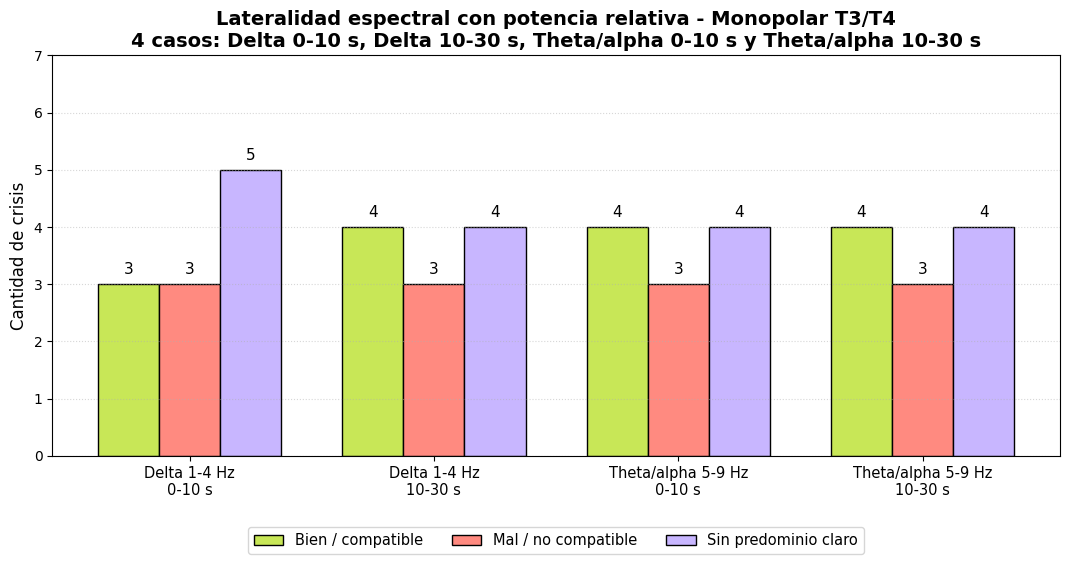

Gráfico de lateralidad Bipolar temporal guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\imagenes\03_lateralidad\resumen_lateralidad_espectral_bipolar_4patrones.png


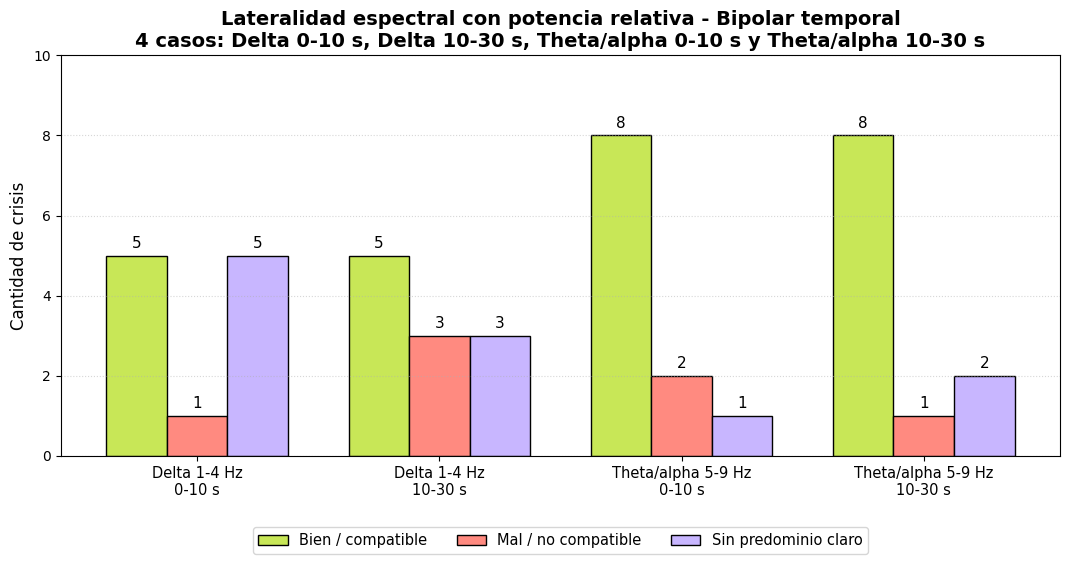

CSV resumen guardado en: C:\Users\yoopy\OneDrive\Escritorio\TPS\resultados_batch\resumen_lateralidad_espectral_potencia_relativa.csv


In [38]:
# ============================================================
# 13B) DATAFRAME FINAL Y GRÁFICOS SEPARADOS DE LATERALIDAD
# ============================================================

if "df_lateralidad_espectral_REL" not in globals() or df_lateralidad_espectral_REL.empty:
    raise RuntimeError("No encontré df_lateralidad_espectral_REL. Corré primero la celda 13A.")

filas_resumen_REL = []

for (metodo, patron), dfp in df_lateralidad_espectral_REL.groupby(["metodo", "descripcion_patron"], sort=False):
    total = len(dfp)
    bien = int((dfp["resultado_REL"] == "Bien / compatible").sum())
    mal = int((dfp["resultado_REL"] == "Mal / no compatible").sum())
    sin_claro = int((dfp["resultado_REL"] == "Sin predominio claro").sum())
    clasificables = bien + mal

    filas_resumen_REL.append({
        "metodo": metodo,
        "patron": patron,
        "patron_corto": dfp["patron_corto"].iloc[0] if "patron_corto" in dfp.columns else patron,
        "total": total,
        "clasificables": clasificables,
        "bien_compatible": bien,
        "mal_no_compatible": mal,
        "sin_predominio_claro": sin_claro,
        "pct_bien_sobre_total": 100 * bien / total if total > 0 else np.nan,
        "pct_bien_sobre_clasificables": 100 * bien / clasificables if clasificables > 0 else np.nan,
        "pct_sin_predominio_claro": 100 * sin_claro / total if total > 0 else np.nan,
    })

df_resumen_lateralidad_espectral_REL = pd.DataFrame(filas_resumen_REL)

orden_patrones = [cfg["descripcion"] for cfg in PATRONES_LATERALIDAD_REL.values()]
orden_metodos = ["Monopolar T3/T4", "Bipolar temporal"]
orden_combinado = [(metodo, patron) for metodo in orden_metodos for patron in orden_patrones]

df_resumen_lateralidad_espectral_REL["orden"] = df_resumen_lateralidad_espectral_REL.apply(
    lambda row: orden_combinado.index((row["metodo"], row["patron"]))
    if (row["metodo"], row["patron"]) in orden_combinado else 999,
    axis=1,
)
df_resumen_lateralidad_espectral_REL = (
    df_resumen_lateralidad_espectral_REL
    .sort_values("orden")
    .drop(columns="orden")
    .reset_index(drop=True)
)

ruta_resumen_REL = CARPETA_RESULTADOS_BATCH / "resumen_lateralidad_espectral_potencia_relativa.csv"
df_resumen_lateralidad_espectral_REL.to_csv(ruta_resumen_REL, index=False)

print("DataFrame final de lateralidad espectral relativa:")
display(df_resumen_lateralidad_espectral_REL)



fig_lateralidad_monopolar_REL = graficar_lateralidad_separada_por_metodo(
    df_resumen_lateralidad_espectral_REL,
    metodo="Monopolar T3/T4",
    nombre_salida="resumen_lateralidad_espectral_monopolar_4patrones.png",
    mostrar=True,
    cerrar=True,
)

fig_lateralidad_bipolar_REL = graficar_lateralidad_separada_por_metodo(
    df_resumen_lateralidad_espectral_REL,
    metodo="Bipolar temporal",
    nombre_salida="resumen_lateralidad_espectral_bipolar_4patrones.png",
    mostrar=True,
    cerrar=True,
)

print("CSV resumen guardado en:", ruta_resumen_REL)


## 14. Análisis de Ritmicidad

No pudo desarrollarse un algoritmo que permita identificar adecuadamente la presencia de ritmicidad delta o theta/alpha en los registros analizados. Por ende, se decidió realizar una inspección manual únicamente de aquellos pacientes que cumplieron con el patrón esperado en la PSD relativa. 

In [39]:
# ============================================================
# REVISIÓN VISUAL EN MNE — CASOS QUE CUMPLEN EL PATRÓN BUSCADO
# Abre ventanas interactivas de MNE: señal filtrada + suavizada.
# ============================================================

# --- Backend interactivo de MNE ---
import sys
import subprocess
import importlib.util

paquetes_faltantes = []

if importlib.util.find_spec("mne_qt_browser") is None:
    paquetes_faltantes.append("mne-qt-browser")

if all(importlib.util.find_spec(pkg) is None for pkg in ["PyQt6", "PyQt5", "PySide6", "PySide2"]):
    paquetes_faltantes.append("PyQt6")

if paquetes_faltantes:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", *paquetes_faltantes],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        importlib.invalidate_caches()
    except Exception as e:
        raise RuntimeError(
            "No pude instalar el backend interactivo de MNE. "
            "Corré una vez en una celda aparte: %pip install mne-qt-browser PyQt6 "
            "y después reiniciá el kernel."
        ) from e

try:
    get_ipython().run_line_magic("gui", "qt")
except Exception:
    pass

try:
    mne.viz.set_browser_backend("qt", verbose=False)
except TypeError:
    mne.viz.set_browser_backend("qt")

MAX_CASOS_MNE = 10
VENTANA_SUAVIZADO_S = 0.09
ESCALA_MNE_UV = 300
DURACION_INICIAL_MNE_S = 5
BLOQUEAR_MNE = False  # False = abre la ventana MNE y no queda trabado en la terminal/notebook.

VENTANA_MNE_0_10 = VENTANA_INICIO_ICTAL if "VENTANA_INICIO_ICTAL" in globals() else (0.0, 10.0)
VENTANA_MNE_10_30 = VENTANA_EVOLUCION_ICTAL if "VENTANA_EVOLUCION_ICTAL" in globals() else (10.0, 30.0)

raws_mne_ritmicidad = []
browsers_mne_ritmicidad = []

# ------------------------------------------------------------
# 1) Tomar dataframe de clasificación ya generado
# ------------------------------------------------------------

if "df_clasificacion_transicion" in globals() and isinstance(df_clasificacion_transicion, pd.DataFrame):
    df_clasif_mne = df_clasificacion_transicion.copy()

elif "clasificacion_casos_potencia_relativa_por_paciente" in globals():
    obj = clasificacion_casos_potencia_relativa_por_paciente

    if isinstance(obj, pd.DataFrame):
        df_clasif_mne = obj.copy()
    else:
        df_clasif_mne = pd.read_csv(obj)

elif "ruta_clasificacion_transicion" in globals() and Path(ruta_clasificacion_transicion).exists():
    df_clasif_mne = pd.read_csv(ruta_clasificacion_transicion)

else:
    ruta_csv_clasificacion = CARPETA_RESULTADOS_BATCH / "clasificacion_casos_potencia_relativa_por_paciente.csv"

    if ruta_csv_clasificacion.exists():
        df_clasif_mne = pd.read_csv(ruta_csv_clasificacion)
    else:
        raise RuntimeError(
            "No encontré la clasificación por paciente. "
            "Corré primero la celda donde se genera df_clasificacion_transicion."
        )

# ------------------------------------------------------------
# 2) Filtrar pacientes que cumplieron el patrón buscado
# ------------------------------------------------------------

mask_patron = pd.Series(False, index=df_clasif_mne.index)

if "es_caso_buscado" in df_clasif_mne.columns:
    s = df_clasif_mne["es_caso_buscado"]

    if pd.api.types.is_bool_dtype(s):
        mask_patron |= s.fillna(False)
    elif pd.api.types.is_numeric_dtype(s):
        mask_patron |= pd.to_numeric(s, errors="coerce").fillna(0).astype(float) != 0
    else:
        mask_patron |= (
            s.astype(str).str.strip().str.lower()
            .isin(["true", "1", "si", "sí", "yes", "verdadero"])
        )

elif "caso_codigo" in df_clasif_mne.columns:
    mask_patron |= (
        df_clasif_mne["caso_codigo"]
        .astype(str).str.strip().str.lower()
        .isin(["patrón buscado", "patron buscado"])
    )

elif "cumple_patron_compatible" in df_clasif_mne.columns:
    s = df_clasif_mne["cumple_patron_compatible"]

    if pd.api.types.is_bool_dtype(s):
        mask_patron |= s.fillna(False)
    elif pd.api.types.is_numeric_dtype(s):
        mask_patron |= pd.to_numeric(s, errors="coerce").fillna(0).astype(float) != 0
    else:
        mask_patron |= (
            s.astype(str).str.strip().str.lower()
            .isin(["true", "1", "si", "sí", "yes", "verdadero"])
        )

else:
    raise RuntimeError(
        "No encontré columna para filtrar el patrón buscado. "
        "Esperaba `es_caso_buscado`, `caso_codigo` o `cumple_patron_compatible`."
    )

df_pacientes_patron_mne = df_clasif_mne.loc[mask_patron].copy()

if df_pacientes_patron_mne.empty:
    raise RuntimeError("No hay pacientes que cumplan el patrón buscado.")

columnas_ver_pacientes = [
    "patient_id",
    "lateralization",
    "canal_temporal_foco",
    "caso_codigo",
    "banda_dominante_0_10",
    "banda_dominante_10_30",
    "delta_0_10",
    "theta_alpha_5_9_0_10",
    "delta_10_30",
    "theta_alpha_5_9_10_30",
    "cambio_theta_alpha_5_9_10_30_menos_0_10",
    "cumple_inicio_delta",
    "aumenta_theta_alpha",
    "aumenta_delta",
    "es_caso_buscado",
    "cumple_patron_compatible",
]
columnas_ver_pacientes = [c for c in columnas_ver_pacientes if c in df_pacientes_patron_mne.columns]

display(df_pacientes_patron_mne[columnas_ver_pacientes])

# ------------------------------------------------------------
# 3) Buscar las crisis correspondientes en eventos/cache
# ------------------------------------------------------------

if "df_eventos_a_procesar" in globals():
    df_eventos_base_mne = df_eventos_a_procesar.copy()
elif "df_eventos_crisis" in globals():
    df_eventos_base_mne = df_eventos_crisis.copy()
else:
    raise RuntimeError("No encontré `df_eventos_a_procesar` ni `df_eventos_crisis`.")

if "CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS" not in globals() or len(CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS) == 0:
    raise RuntimeError(
        "No existe `CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS` o está vacío. "
        "Corré primero la celda que genera el cache filtrado."
    )

if "_clave_cache_evento" not in globals():
    raise RuntimeError("No existe `_clave_cache_evento`. Corré primero las funciones del batch/cache.")

pacientes_patron = set(df_pacientes_patron_mne["patient_id"].astype(str))

df_eventos_mne = df_eventos_base_mne[
    df_eventos_base_mne["patient_id"].astype(str).isin(pacientes_patron)
].copy()

# Si existe resumen por crisis, restringe a las crisis que cumplieron el patrón.
if (
    "df_resumen_crisis" in globals()
    and isinstance(df_resumen_crisis, pd.DataFrame)
    and not df_resumen_crisis.empty
    and "cumple_patron_compatible" in df_resumen_crisis.columns
):
    s = df_resumen_crisis["cumple_patron_compatible"]

    if pd.api.types.is_bool_dtype(s):
        mask_crisis_patron = s.fillna(False)
    elif pd.api.types.is_numeric_dtype(s):
        mask_crisis_patron = pd.to_numeric(s, errors="coerce").fillna(0).astype(float) != 0
    else:
        mask_crisis_patron = (
            s.astype(str).str.strip().str.lower()
            .isin(["true", "1", "si", "sí", "yes", "verdadero"])
        )

    cols_clave = ["patient_id", "edf_filename", "seizure_index_in_file"]

    if all(c in df_resumen_crisis.columns for c in cols_clave) and all(c in df_eventos_mne.columns for c in cols_clave):
        df_crisis_patron = df_resumen_crisis[
            df_resumen_crisis["patient_id"].astype(str).isin(pacientes_patron)
            & mask_crisis_patron
        ].copy()

        if not df_crisis_patron.empty:
            claves_crisis_patron = set(
                zip(
                    df_crisis_patron["patient_id"].astype(str),
                    df_crisis_patron["edf_filename"].astype(str),
                    df_crisis_patron["seizure_index_in_file"].astype(str),
                )
            )

            df_eventos_mne = df_eventos_mne[
                [
                    clave in claves_crisis_patron
                    for clave in zip(
                        df_eventos_mne["patient_id"].astype(str),
                        df_eventos_mne["edf_filename"].astype(str),
                        df_eventos_mne["seizure_index_in_file"].astype(str),
                    )
                ]
            ].copy()

if df_eventos_mne.empty:
    raise RuntimeError("No encontré crisis/eventos para abrir en MNE.")

cols_orden = [c for c in ["patient_id", "edf_filename", "seizure_index_in_file"] if c in df_eventos_mne.columns]

if cols_orden:
    df_eventos_mne = df_eventos_mne.sort_values(cols_orden).reset_index(drop=True)

df_eventos_mne = df_eventos_mne.head(MAX_CASOS_MNE).copy()

# ------------------------------------------------------------
# 4) Abrir MNE: original filtrada + suavizada, solo durante crisis
# ------------------------------------------------------------

filas_abiertas_mne = []

for _, evento in df_eventos_mne.iterrows():

    clave_cache = _clave_cache_evento(evento)
    item_cache = CACHE_SEGMENTOS_FILTRADOS_EXTENDIDOS.get(clave_cache)

    if item_cache is None:
        continue

    raw_ext_filtrado = item_cache["raw_ext_filtrado"]
    inicio_local = float(item_cache["inicio_local"])
    fin_local = float(item_cache["fin_local"])

    fs = float(raw_ext_filtrado.info["sfreq"])

    canal_foco = str(evento.get("canal_temporal_foco", "")).strip()

    if canal_foco == "" or canal_foco.lower() == "nan":
        lateralidad = str(evento.get("lateralization", "")).strip().upper()

        if lateralidad == "L":
            canal_foco = "T3"
        elif lateralidad == "R":
            canal_foco = "T4"

    if canal_foco not in raw_ext_filtrado.ch_names:
        canal_norm = canal_foco.upper().replace("EEG ", "").strip()
        canal_encontrado = None

        for ch in raw_ext_filtrado.ch_names:
            ch_norm = str(ch).upper().replace("EEG ", "").strip()

            if ch_norm == canal_norm:
                canal_encontrado = ch
                break

        if canal_encontrado is not None:
            canal_foco = canal_encontrado

    if canal_foco not in raw_ext_filtrado.ch_names:
        lateralidad = str(evento.get("lateralization", "")).strip().upper()
        canal_lateral = "T3" if lateralidad == "L" else "T4" if lateralidad == "R" else None

        if canal_lateral is not None and canal_lateral in raw_ext_filtrado.ch_names:
            canal_foco = canal_lateral

    if canal_foco not in raw_ext_filtrado.ch_names:
        continue

    start = int(round(inicio_local * fs))
    stop = int(round(fin_local * fs))

    start = max(0, min(start, raw_ext_filtrado.n_times - 1))
    stop = max(start + 1, min(stop, raw_ext_filtrado.n_times))

    x_original_v = raw_ext_filtrado.get_data(
        picks=[canal_foco],
        start=start,
        stop=stop,
    )[0]

    duracion_ictal = len(x_original_v) / fs

    # Suavizado leve solo para visualización.
    n_suav = int(round(VENTANA_SUAVIZADO_S * fs))
    n_suav = max(5, n_suav)

    if n_suav % 2 == 0:
        n_suav += 1

    if n_suav >= len(x_original_v):
        n_suav = len(x_original_v) - 1 if len(x_original_v) % 2 == 0 else len(x_original_v)

    if n_suav >= 5:
        if n_suav % 2 == 0:
            n_suav -= 1

        x_suavizada_v = scipy.signal.savgol_filter(
            x_original_v,
            window_length=n_suav,
            polyorder=min(3, n_suav - 2),
            mode="interp",
        )
    else:
        x_suavizada_v = x_original_v.copy()

    raw_mne_ictal = mne.io.RawArray(
        np.vstack([x_original_v, x_suavizada_v]),
        mne.create_info(
            ch_names=[canal_foco, f"{canal_foco}_suavizada"],
            sfreq=fs,
            ch_types=["eeg", "eeg"],
        ),
        verbose=False,
    )

    onsets = []
    durations = []
    descriptions = []

    v0, v1 = float(VENTANA_MNE_0_10[0]), float(VENTANA_MNE_0_10[1])
    if duracion_ictal > v0:
        onsets.append(v0)
        durations.append(max(0.0, min(v1, duracion_ictal) - v0))
        descriptions.append("0-10 s | delta inicial")

    v0, v1 = float(VENTANA_MNE_10_30[0]), float(VENTANA_MNE_10_30[1])
    if duracion_ictal > v0:
        onsets.append(v0)
        durations.append(max(0.0, min(v1, duracion_ictal) - v0))
        descriptions.append("10-30 s | theta/alpha")

    if len(onsets) > 0:
        raw_mne_ictal.set_annotations(
            mne.Annotations(
                onset=onsets,
                duration=durations,
                description=descriptions,
            )
        )

    titulo_mne = (
        f"{evento.get('patient_id')} | {evento.get('edf_filename')} | "
        f"crisis {evento.get('seizure_index_in_file')} | canal {canal_foco}"
    )

    raws_mne_ritmicidad.append(raw_mne_ictal)

    browser = raw_mne_ictal.plot(
        start=0,
        duration=min(float(DURACION_INICIAL_MNE_S), max(1.0, duracion_ictal)),
        n_channels=2,
        scalings={"eeg": float(ESCALA_MNE_UV) * 1e-6},
        title=titulo_mne,
        block=BLOQUEAR_MNE,
        show=True,
    )

    browsers_mne_ritmicidad.append(browser)

    filas_abiertas_mne.append({
        "patient_id": evento.get("patient_id"),
        "edf_filename": evento.get("edf_filename"),
        "seizure_index_in_file": evento.get("seizure_index_in_file"),
        "canal_mostrado": canal_foco,
        "duracion_ictal_s": round(float(duracion_ictal), 2),
        "ventanas_marcadas": "0-10 s y 10-30 s",
    })

if len(filas_abiertas_mne) == 0:
    raise RuntimeError("No se pudo abrir ningún caso en MNE. Revisá que los eventos estén en el cache y que exista T3/T4.")

df_eventos_abiertos_mne = pd.DataFrame(filas_abiertas_mne)
display(df_eventos_abiertos_mne)


,patient_id,lateralization,canal_temporal_foco,caso_codigo,banda_dominante_0_10,banda_dominante_10_30,delta_0_10,theta_alpha_5_9_0_10,delta_10_30,theta_alpha_5_9_10_30,cambio_theta_alpha_5_9_10_30_menos_0_10,cumple_inicio_delta,cumple_inicio_delta,aumenta_theta_alpha,aumenta_theta_alpha,aumenta_delta,aumenta_delta,es_caso_buscado,cumple_patron_compatible
0,PN00,R,T4,Patrón buscado,delta,theta_alpha_5_9,30.188945,4.309399,27.237430,31.599018,27.289619,True,True,True,True,False,False,True,True
3,PN05,L,T3,Patrón buscado,delta,delta,50.503008,7.201172,26.613108,25.503062,18.301890,True,True,True,True,False,False,True,True
4,PN06,L,T3,Patrón buscado,delta,delta,51.250667,5.780686,29.455877,7.442370,1.661683,True,True,True,True,False,False,True,True
6,PN11,R,T4,Patrón buscado,delta,delta,30.660688,5.586285,23.141030,18.513073,12.926789,True,True,True,True,False,False,True,True
8,PN13,L,T3,Patrón buscado,delta,delta,22.218880,3.272386,61.487246,13.749451,10.477065,True,True,True,True,True,True,True,True
10,PN17,R,T4,Patrón buscado,delta,delta,39.481229,2.702399,37.374812,10.813846,8.111446,True,True,True,True,False,False,True,True


,patient_id,edf_filename,seizure_index_in_file,canal_mostrado,duracion_ictal_s,ventanas_marcadas
0,PN00,PN00-1.edf,1,T4,70.0,0-10 s y 10-30 s
1,PN05,PN05-2.edf,1,T3,35.0,0-10 s y 10-30 s
2,PN06,PN06-1.edf,1,T3,64.0,0-10 s y 10-30 s
3,PN11,PN11-1.edf,1,T4,55.0,0-10 s y 10-30 s
4,PN13,PN13-1.edf,1,T3,48.0,0-10 s y 10-30 s
5,PN17,PN17-2.edf,1,T4,83.0,0-10 s y 10-30 s
